# $B^\pm\to\pi^\pm\pi^\pm\pi^\mp$: N toys CP com QMI1D + $\chi_{c0}$

Versão de `23_b2pipipi_cpvfit_toy_pull_study_SqDP.ipynb`; o original permanece intacto.
Os toys Laura++ e seus coeficientes/dinâmica geradores são os mesmos. No **modelo de fit**,
`S_QMI` substitui `sigma0 + f0_980 + f0_1370`; `chi_c0` e as ondas de spin maior permanecem explícitos.
Cada carga tem seus próprios nodes Re/Im, interpolados pela API `QMI` em **$s=m^2$**, com knots especificados em GeV.

A convenção é
\[
 S_{\rm truth}^q(m)=\sum_{r\in S} c_r^q n_r F_r(m),\qquad
 S_{\rm fit}^q(m)=Q^q(m)+c_{\chi}^q n_{\chi}F_{\chi}(m),
\]
onde $n_r=[\langle w|F_r^{\rm sym}|^2\rangle]^{-1/2}$ é a escala fixa do componente
isobárico **simetrizado**, calculada sem eficiência/veto, como no fitter original.
As curvas são amplitudes de **um par** $\pi^+\pi^-$, não projeções da amplitude simetrizada 2D.
No likelihood, a biblioteca faz a simetrização e inclui eficiência, veto e todas as interferências.

- A QMI usa `normalize_component=False` e coeficiente **fixo** $1+0i$; os nodes carregam a escala física da convenção geradora.
- A normalização **total** do likelihood continua dinâmica e conjunta em carga via `CPFitSession`.
- Mantemos `rho0_770.x=1`, `y=dy=0` fixos e `dx` livre. Isso fixa a escala comum e as duas referências de fase; a razão de escalas entre cargas continua ajustável. Não fixamos nodes nem realinhamos amplitudes após os fits.
- Os pulls de nodes comparam **QMI sem χc0** com `sigma0 + f0_980 + f0_1370` truth. As curvas completas comparam **QMI+χc0** com toda a S-wave truth.
- Fases são relativas à referência do ρ e diferenças são tomadas módulo $2\pi$. Não se mede uma fase global absoluta entre amostras de cargas distintas.

O laço preserva N=500 e a retomada por `iExpt`, com arquivos próprios QMI1D. Para um ensaio curto,
altere `TOY_INDICES`; `RUN_TOY_FITS=False` apenas recarrega resultados existentes. A malha de nodes é configurável:
closure perfeito não é garantido por uma interpolação finita. Examine primeiro o diagnóstico de representação.


### Opção de suavização dos nodes (desligada por padrão)

Esta variante usa `qmi.smoothness_constraint(strength=QMI_SMOOTHNESS_STRENGTH)`
para cada carga, com a mesma força. Funciona para `linear`, `cubic`, `hermite` e `natural`;
no fit deste notebook os nodes continuam cartesianos. A curva interpolada e sua normalização
não mudam: a penalização é somada uma vez ao likelihood conjunto para cada QMI.
Somente a QMI charmless é penalizada; χc0 permanece explícito.

`QMI_SMOOTHNESS_STRENGTH = 0.0` preserva o fit sem suavização. Um valor positivo precisa
ser escolhido e validado em toys: não há λ calibrado automaticamente. O termo é
\[
\lambda\sum_i w_i\frac{2|d_i-d_{i-1}|^2}{h_i+h_{i-1}},\qquad
h_i=m_{i+1}^2-m_i^2,\quad d_i=(Q_{i+1}-Q_i)/h_i.
\]
`QMI_SMOOTHNESS_WEIGHTS=None` usa todos os pesos iguais a 1. Para pesos locais, forneça
uma sequência com `len(QMI_KNOTS)-2` entradas finitas não negativas; um zero desliga o
estêncil de três nodes correspondente. Proteger uma região estreita exige desligar todos
os estênceis que a atravessam. A região do f0(980) também pode sofrer viés por suavização.

As saídas usam um diretório novo, identificado por λ/pesos, preservando os resultados
anteriores. `nll` inclui a penalização; `nll_data` e `smoothness_penalty` são salvos
separadamente. Erros HESSE vêm do objetivo penalizado e devem ter sua cobertura verificada.


In [24]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cuda")  # use "cpu" antes dos imports, se necessário
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")


'false'

In [25]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import time
import json
import hashlib
from IPython.display import display

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.optimize import curve_fit

from dalitzplotfitter import (
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    QMI,
    RealImag,
    DecayChannel,
    DecayModel,
    GounarisSakurai,
    MassWindowVeto,
    Parameter,
    PhaseSpaceSample,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    RelativisticBreitWigner,
    Resonance,
    SigmaPole,
    ZemachP,
    enable_x64,
    read_root_histogram2d,
    read_root_tree,
)



enable_x64()


## Configuração dos toys, normalização e saídas


In [26]:
INPUTS = Path("/home/juan-leite/Work/data/fit415489_pipipinotav3_21-5--11h32m13s415489/inputs")

ACC_FILE = INPUTS / "ACC_pipipi_15161718_NoSpike_prodAsy.root"
ACC_HIST_PLUS = "Hacc_pipipi_15161718_Plus"
ACC_HIST_MINUS = "Hacc_pipipi_15161718_Minus"

QQBAR_BKG_FILE = INPUTS / "Lau_3pi_BKG_pm_322_V2h_splot_normcut.root"
QQBAR_HIST_PLUS = "hbkgbp"
QQBAR_HIST_MINUS = "hbkgbm"

KPIPI_BKG_FILE = INPUTS / "bkg_kpipi_histo.root"
KPIPI_HIST = "hbkg"  # same histogram used for both B+ and B- in the .cc

D0_VETO_MIN_GEV = 1.74
D0_VETO_MAX_GEV = 1.894

N_TOTAL_EVENTS = 95110.0
SIGNAL_FRACTION = 0.8845
QQBAR_FRACTION = 0.1155
N_SIGNAL = N_TOTAL_EVENTS * SIGNAL_FRACTION
N_QQBAR = N_TOTAL_EVENTS * QQBAR_FRACTION
QQBAR_YIELD_ASYMMETRY = -0.0078  # qqbarEventsAsym, fixed

N_KPIPIBKG = 0.  # nBgkpipiEvents = 95120*.0, fixed -- inert, kept only for structural fidelity
KPIPIBKG_YIELD_ASYMMETRY = 0.03  # kpipibkgEventsAsym, fixed -- inert since the yield above is 0

NORMALIZATION_CONFIG = {
    "normalization_method": "square-dalitz",
    "normalization_pair": (0,1),
    "normalization_chunk_size": 250_000,
    "normalization_resolution": 500,
    "normalization_binning_factor": 100,
    # The 250k grid fits one macroblock; 25k divides it without padding.
    # Measured 35% faster per warm value/gradient than 200k/100k on RTX 3050 Ti.
    "dynamics_microbatch_size": 25_000,
    "dynamics_microbatch_parallelism": 4,  # 1 for sequential Hessian-vector, 2 for parallel
}

# Toy-MC sample: 500 independent experiments, selected by the `iExpt` branch (0..499).
TOY_FILE = Path(
    "/home/juan-leite/Work/Laura-3.8.0/Laura++/bto3pi_toys_jussara/"
    "gen_pipipinotav3_16-9--16h2m23s/Gen3pi_test.root"
)
TOY_TREE = "fitTree"
N_EXPERIMENTS = 10
TOY_INDICES = range(N_EXPERIMENTS)  # narrow this (e.g. range(5)) for a quick smoke test

RUN_TOY_FITS = True
QMI_SMOOTHNESS_STRENGTH = 0.2  # lambda fixo; zero desliga a penalização
QMI_SMOOTHNESS_WEIGHTS = None  # ou len(QMI_KNOTS)-2 pesos, um por node interior
_smoothness_tag = hashlib.sha256(json.dumps(
    dict(strength=QMI_SMOOTHNESS_STRENGTH, weights=QMI_SMOOTHNESS_WEIGHTS), sort_keys=True
).encode()).hexdigest()[:10]
OUTPUT_DIR = Path("23_b2pipipi_cpvfit_toy_pull_study_SqDP_QMI1D_Smoothness_results") / (
    f"lambda_{QMI_SMOOTHNESS_STRENGTH:g}_{_smoothness_tag}"
)
TOY_RESULTS_CSV = OUTPUT_DIR / "fit_results.csv"
NODE_RESULTS_CSV = OUTPUT_DIR / "node_results.csv"
QMI_INTERPOLATION = "linear"  # Re/Im lineares em s, como a API QMI do projeto
FIT_OPTIONS = dict(strategy=1, verbose=0, hesse=True, hessian="jax", hessian_batch_size=1)
PHASE_MAG_FLOOR = 1e-10  # fase indefinida no zero da amplitude
SHOW_INDIVIDUAL_CURVES = True
SAVE_FIGURES = True


print(f"N_signal = {N_SIGNAL:.3f}   N_qqbar = {N_QQBAR:.3f}   sum = {N_SIGNAL + N_QQBAR:.3f}")


N_signal = 84124.795   N_qqbar = 10985.205   sum = 95110.000


## Canais e veto

Idêntico ao notebook 22.

In [27]:
PLUS_CHANNEL = DecayChannel("B+", ("pi+", "pi+", "pi-"))
MINUS_CHANNEL = DecayChannel("B-", ("pi-", "pi-", "pi+"))

MOTHER_MASS = PLUS_CHANNEL.parent_mass
DAUGHTER_MASSES = PLUS_CHANNEL.daughter_masses
SQDP_PAIR = (0, 1)  # the two identical pi+/pi-, per the sibling Laura-toy benchmark notebook
RESONANCE_PAIR = (2, 0)  # resPairAmpInt=2 for every resonance in the .cc

print("mother mass [GeV] =", MOTHER_MASS)
print("daughter masses [GeV] =", DAUGHTER_MASSES)

D0_VETO = CompositeVeto(
    MassWindowVeto((0, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
    MassWindowVeto((1, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
)


mother mass [GeV] = 5.2794099999999995
daughter masses [GeV] = (0.13957039000000002, 0.13957039000000002, 0.13957039000000002)


## Leitura dos toys
Mesmos branches e cortes do notebook original. Verificamos a ordenação de `iExpt` antes de usar `searchsorted`;
um toy ausente é erro explícito. Apenas um experimento fica carregado por vez.


In [28]:
_RAW_IEXPT = np.asarray(
    read_root_tree(TOY_FILE, TOY_TREE, {"iExpt": "iExpt"}, library="np")["iExpt"]
)
if _RAW_IEXPT.size == 0 or np.any(_RAW_IEXPT[1:] < _RAW_IEXPT[:-1]):
    raise ValueError("iExpt deve ser não vazio e estar ordenado para leitura por blocos")
print(f"toy file entries: {len(_RAW_IEXPT):,}   experiments: {_RAW_IEXPT.min()}..{_RAW_IEXPT.max()}")

# `iExpt` is written contiguously and non-decreasing (each of the 500 experiments is one
# contiguous run of rows), so `np.searchsorted` gives each toy's exact entry range from this
# single int32 branch alone. `load_toy_samples` then re-reads only that one toy's ~95k-row block
# per call (split into B+/B- in memory), instead of keeping the full 47.5-million-row tree
# resident in host memory for the whole 8-hour loop below.
_TOY_ENTRY_START = np.searchsorted(_RAW_IEXPT, np.arange(N_EXPERIMENTS), side="left")
_TOY_ENTRY_STOP = np.searchsorted(_RAW_IEXPT, np.arange(N_EXPERIMENTS), side="right")
del _RAW_IEXPT


def load_toy_samples(iexpt):
    """Read one toy's block from disk and split it into B+/B- ``PhaseSpaceSample``s."""
    if not 0 <= iexpt < N_EXPERIMENTS:
        raise ValueError(f"iExpt fora do intervalo: {iexpt}")
    if _TOY_ENTRY_STOP[iexpt] <= _TOY_ENTRY_START[iexpt]:
        raise ValueError(f"Toy ausente: iExpt={iexpt}")
    block = read_root_tree(
        TOY_FILE, TOY_TREE,
        {"s12": "m12Sq", "s13": "m13Sq", "s23": "m23Sq", "charge": "charge"},
        entry_start=int(_TOY_ENTRY_START[iexpt]),
        entry_stop=int(_TOY_ENTRY_STOP[iexpt]),
        library="np",
    )
    charge = block["charge"]
    samples = {}
    for charge_value in (+1, -1):
        mask = charge == charge_value
        n = int(mask.sum())
        sample = PhaseSpaceSample(
            s12=jnp.asarray(block["s12"][mask]),
            s13=jnp.asarray(block["s13"][mask]),
            s23=jnp.asarray(block["s23"][mask]),
            weights=jnp.ones(n, dtype=jnp.float64),
        )
        samples[charge_value] = D0_VETO.apply(sample)
    return samples


def drop_zero_efficiency_events(sample, efficiency):
    values = np.asarray(efficiency(sample.as_dict()))
    keep = values > 0.0
    n_dropped = int((~keep).sum())
    if n_dropped == 0:
        return sample, 0
    filtered = PhaseSpaceSample(
        s12=sample.s12[keep], s13=sample.s13[keep], s23=sample.s23[keep],
        weights=sample.weights[keep],
    )
    return filtered, n_dropped


# sanity check on experiment 0, same as the fit loop will do for every iExpt
_probe = load_toy_samples(0)
print(f"iExpt=0: B+ events (post D0 veto) = {_probe[+1].size:,}   "
      f"B- events (post D0 veto) = {_probe[-1].size:,}")
del _probe


toy file entries: 47,560,440   experiments: 0..499
iExpt=0: B+ events (post D0 veto) = 43,697   B- events (post D0 veto) = 51,382


## Eficiência (ACC)

Idêntico ao notebook 22 -- mesmo arquivo/histogramas, construído uma única vez e reaproveitado nos
500 toys.

In [29]:
def _load_square_dalitz_histogram2d(file_path, histogram):
    values, mp_edges, tp_edges = read_root_histogram2d(file_path, histogram)
    return jnp.asarray(values), jnp.asarray(mp_edges), jnp.asarray(tp_edges)


def _laura_efficiency(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline", clip=True,
    )


plus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_PLUS)
minus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_MINUS)
print("ACC B+ grid:", plus_efficiency.values.shape, "  ACC B- grid:", minus_efficiency.values.shape)


ACC B+ grid: (30, 30)   ACC B- grid: (30, 30)


## Background `qqbar` e `kpipibkg`

Idêntico ao notebook 22 -- mesmos histogramas, mesma interpolação/jacobiano. A assimetria de yield
fixa é aplicada mais abaixo, depois que `plus_model`/`minus_model` existem, exatamente como no
notebook 22.

In [30]:
def _laura_background(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramBackground(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline", divide_jacobian=True,
    )


_qqbar_plus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_PLUS)
_qqbar_minus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_MINUS)
_kpipibkg_pdf = _laura_background(KPIPI_BKG_FILE, KPIPI_HIST)

print("qqbar B+ grid:", _qqbar_plus_pdf.values.shape, "  qqbar B- grid:", _qqbar_minus_pdf.values.shape)
print("kpipibkg grid:", _kpipibkg_pdf.values.shape)


qqbar B+ grid: (60, 30)   qqbar B- grid: (60, 30)
kpipibkg grid: (15, 15)


## Truth gerador e referência CP
Coeficientes, massas, larguras e referência do notebook original; somente a composição do modelo de fit muda.


In [31]:
# name: (x, y, dx, dy, fix_x, fix_y, fix_dx, fix_dy)
COEFFICIENT_SPECS = {
    "rho0_770":    (1.00000e+00,  0.00000e+00,  1.02312e-03,  0.00000e+00, True,  True,  False, True),
    "omega_782":   (-3.03268e-02, 9.48849e-02,  7.29877e-03,  1.38260e-02, False, False, False, False),
    "rho0_1450":   (-2.70865e-01, 1.13529e-01, -9.16491e-02, -7.71941e-03, False, False, False, False),
    "f2_1270":     (3.51291e-01,  1.71931e-01, -5.45892e-02, -1.17944e-01, False, False, False, False),
    "rho0_3_1690": (9.64994e-02,  1.91968e-02,  4.92371e-02,  5.41424e-02, False, False, False, False),
    "sigma0":      (-4.02003e-01, 3.57099e-01,  2.86690e-01,  2.01322e-01, False, False, False, False),
    "f0_980":      (1.41060e-01, -1.40500e-02, -4.50930e-02, -7.70899e-02, False, False, False, False),
    "chi_c0":      (2.71432e-02,  1.41733e-02, -4.02037e-02, -4.02666e-02, False, False, False, False),
    "f0_1370":     (1.00608e-01, -2.34739e-02,  5.11699e-02, -5.63136e-02, False, False, False, False),
}

# name: (mass, width, fixed, mass_bounds, width_bounds)
# DYNAMICS_SPECS = {
#     "rho0_770":    (0.77526, 0.14780, False, (0.60, 0.95), (0.05, 0.30)),
#     "omega_782":   (0.78265, 0.00849, True,  None, None),
#     "rho0_1450":   (1.46500, 0.40000, True,  None, None),
#     "f2_1270":     (1.27550, 0.18670, False, (1.10, 1.40), (0.05, 0.35)),
#     "rho0_3_1690": (1.68600, 0.18600, True,  None, None),
#     "sigma0":      (0.47500, 0.55000, False, (0.30, 0.70), (0.20, 0.90)),
#     "f0_980":      (0.99000, 0.07000, False, (0.85, 1.10), (0.01, 0.20)),
#     "chi_c0":      (3.41471, 0.01310, True,  None, None),
#     "f0_1370":     (1.37000, 0.35000, False, (1.10, 1.80), (0.05, 0.60)),
# }

# rho0_770/f2_1270/sigma0/f0_980/f0_1370 mass/width below are the Laura++ *converged* fit
# values (GenFit3piCP_fit_415489.log, same as LAURA_FINAL in notebook 22's cell 26) -- these
# toys were generated from that converged model, not from LauResonanceMaker's starting/default
# table. Using the starting-table values here (0.77526/0.1478 for rho0_770, 0.475/0.55 for
# sigma0, 1.37/0.35 for f0_1370, etc.) was the root cause of the large, systematic coefficient
# bias seen in the first 500-toy run: with dynamics fixed (fixed=True below), the coefficients
# had no way to absorb the mass/width mismatch between the (wrong) fixed value and the actual
# generation value, so the mismatch leaked entirely into the CP-coefficient pulls -- worst for
# sigma0/f0_1370/f0_980, whose starting-vs-converged width differs by 20-100%, and negligible
# for rho0_3_1690/chi_c0/omega_782, whose dynamics were never floated in the original fit either
# (so their starting and converged values already coincide).
DYNAMICS_SPECS = {
    "rho0_770":    (0.770229, 0.148864, True, (0.60, 0.95), (0.05, 0.30)),
    "omega_782":   (0.78265, 0.00849, True,  None, None),
    "rho0_1450":   (1.46500, 0.40000, True,  None, None),
    "f2_1270":     (1.25071, 0.170502, True, (1.10, 1.40), (0.05, 0.35)),
    "rho0_3_1690": (1.68600, 0.18600, True,  None, None),
    "sigma0":      (0.509084, 0.425813, True, (0.30, 0.70), (0.20, 0.90)),
    "f0_980":      (0.976535, 0.047831, True, (0.85, 1.10), (0.01, 0.20)),
    "chi_c0":      (3.41471, 0.01310, True,  None, None),
    "f0_1370":     (1.50218, 0.173547, True, (1.10, 1.80), (0.05, 0.60)),
}

SPINS = {
    "rho0_770": 1, "omega_782": 1, "rho0_1450": 1, "f2_1270": 2, "rho0_3_1690": 3,
    "sigma0": 0, "f0_980": 0, "chi_c0": 0, "f0_1370": 0,
}

LINESHAPES = {
    "rho0_770": GounarisSakurai, "omega_782": RelativisticBreitWigner,
    "rho0_1450": GounarisSakurai, "f2_1270": RelativisticBreitWigner,
    "rho0_3_1690": RelativisticBreitWigner, "sigma0": SigmaPole,
    "f0_980": RelativisticBreitWigner, "chi_c0": RelativisticBreitWigner,
    "f0_1370": RelativisticBreitWigner,
}


def make_shared_coefficients():
    coefficients = {}
    for name, (x0, y0, dx0, dy0, fx, fy, fdx, fdy) in COEFFICIENT_SPECS.items():
        x = Parameter.coefficient(f"{name}.x", x0, owner=name, fixed=fx)
        y = Parameter.coefficient(f"{name}.y", y0, owner=name, fixed=fy)
        dx = Parameter.coefficient(f"{name}.dx", dx0, owner=name, fixed=fdx)
        dy = Parameter.coefficient(f"{name}.dy", dy0, owner=name, fixed=fdy)
        coefficients[name] = CPRealImag(x, y, dx, dy)
    return coefficients


def make_dynamics_parameters():
    dynamics = {}
    for name, (mass0, width0, fixed, mass_bounds, width_bounds) in DYNAMICS_SPECS.items():
        dynamics[f"{name}.mass"] = Parameter.dynamics(
            f"{name}.mass", mass0, owner=name, fixed=fixed,
            bounds=None if fixed else mass_bounds,
        )
        dynamics[f"{name}.width"] = Parameter.dynamics(
            f"{name}.width", width0, owner=name, fixed=fixed,
            bounds=None if fixed else width_bounds,
        )
    return dynamics


shared_coefficients = make_shared_coefficients()
dynamics_parameters = make_dynamics_parameters()

TRUE_VALUES = {}
for _name, (_x0, _y0, _dx0, _dy0, *_rest) in COEFFICIENT_SPECS.items():
    TRUE_VALUES[f"{_name}.x"], TRUE_VALUES[f"{_name}.y"] = _x0, _y0
    TRUE_VALUES[f"{_name}.dx"], TRUE_VALUES[f"{_name}.dy"] = _dx0, _dy0
for _name, (_mass0, _width0, *_rest) in DYNAMICS_SPECS.items():
    TRUE_VALUES[f"{_name}.mass"], TRUE_VALUES[f"{_name}.width"] = _mass0, _width0


## Modelo truth, escalas fixas e nodes cartesianos
A malha cobre todo o intervalo físico e é mais densa perto de $f_0(980)$ e $f_0(1370)$.
Não há node estritamente dentro do veto D0: em interpolação linear, nodes com suporte totalmente vetado
seriam parâmetros sem informação. O trecho entre as bordas do veto é uma interpolação sem observações diretas.
Os valores iniciais vêm do truth nos nodes, reiniciados **para cada toy**, sem usar o fit anterior.
As massas/larguras isobáricas ficam fixas, como no original. Os parâmetros livres da QMI usam `Parameter.dynamics(owner="S_QMI")`.


In [32]:
def build_components(charge, shared, dynamics):
    coefficient = {name: cp.for_charge(charge) for name, cp in shared.items()}
    return [
        Resonance(
            name, RESONANCE_PAIR, coefficient[name],
            lineshape=LINESHAPES[name](), angular=ZemachP(),
            mass=dynamics[f"{name}.mass"], width=dynamics[f"{name}.width"], spin=SPINS[name],
            resonance_radius=4.0, parent_radius=4.0,
        )
        for name in COEFFICIENT_SPECS
    ]



truth_models = {
    charge: DecayModel(channel, build_components(charge, shared_coefficients, dynamics_parameters),
                       normalize_components=True, **NORMALIZATION_CONFIG)
    for charge, channel in ((+1, PLUS_CHANNEL), (-1, MINUS_CHANNEL))
}
REPLACED_S_NAMES = ("sigma0", "f0_980", "f0_1370")
ALL_S_NAMES = (*REPLACED_S_NAMES, "chi_c0")
KEPT_NAMES = tuple(name for name in COEFFICIENT_SPECS if name not in REPLACED_S_NAMES)
if not all(spec[2] for spec in DYNAMICS_SPECS.values()):
    raise ValueError("Esta versão congela as escalas truth: mantenha massas/larguras fixas")


def component_by_name(model, name):
    return next(component for component in model.amplitude_model.components if component.name == name)


def fixed_component_scale(model, name):
    # Mesma convenção de DecayModel: integral = mean(weights * |F_sym|²).
    # Eficiência/veto pertencem à normalização do likelihood, não a esta escala.
    component = component_by_name(model, name)
    sample = model.normalization_sample
    raw = jnp.asarray(component.function(sample.as_dict(), TRUE_VALUES))
    integral = float(jnp.mean(sample.weights * jnp.abs(raw)**2))
    if not np.isfinite(integral) or integral <= 0:
        raise ValueError(f"Norma inválida para {name}: {integral}")
    return integral**-0.5


ISOBAR_SCALES = {
    charge: {name: fixed_component_scale(model, name) for name in COEFFICIENT_SPECS}
    for charge, model in truth_models.items()
}


def isobar_single_pair(charge, masses, names=ALL_S_NAMES, values=None):
    values = TRUE_VALUES if values is None else values
    total = np.zeros_like(np.asarray(masses), dtype=complex)
    for name in names:
        component = component_by_name(truth_models[charge], name)
        context = component.function.context.resolve(values)
        shape = np.asarray(component.function.lineshape(jnp.asarray(masses), context))
        coefficient = complex(np.asarray(component.coefficient.value(values)))
        total += coefficient * ISOBAR_SCALES[charge][name] * shape
    return total


PAIR_MIN = DAUGHTER_MASSES[2] + DAUGHTER_MASSES[0]
PAIR_MAX = MOTHER_MASS - DAUGHTER_MASSES[1]
QMI_KNOTS = tuple(float(m) for m in (
    PAIR_MIN, .34, .40, .46, .52, .60, .70, .80, .88, .92,
    .94, .95, .96, .97, .98, .99, 1.00, 1.02, 1.05, 1.10,
    1.18, 1.27, 1.35, 1.40, 1.44, 1.48, 1.50, 1.52, 1.55,
    1.60, 1.68, D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, 2.10, 2.40,
    2.80, 3.20, 3.60, 4.00, 4.50, PAIR_MAX,
))
assert np.all(np.diff(QMI_KNOTS) > 0)
TRUTH_QMI_NODES = {
    charge: isobar_single_pair(charge, QMI_KNOTS, REPLACED_S_NAMES)
    for charge in (+1, -1)
}
QMI_NODE_PARAMETERS, QMI_SHAPES = {}, {}
for charge, tag in ((+1, "plus"), (-1, "minus")):
    truth = TRUTH_QMI_NODES[charge]
    parts = {}
    for field, initial in (("real", truth.real), ("imag", truth.imag)):
        parts[field] = tuple(
            Parameter.dynamics(
                f"S_QMI.{tag}.{field}[{i}]", float(value), owner="S_QMI",
                step=max(0.02 * abs(truth[i]), 1e-4),
            ) for i, value in enumerate(initial)
        )
        TRUE_VALUES.update({p.name: float(p.value) for p in parts[field]})
    QMI_NODE_PARAMETERS[charge] = parts
    QMI_SHAPES[charge] = QMI(
        knots=QMI_KNOTS, real_parts=parts["real"], imaginary_parts=parts["imag"],
        interpolation=QMI_INTERPOLATION,
    )


def build_qmi_components(charge):
    kept = [c for c in build_components(charge, shared_coefficients, dynamics_parameters)
            if c.name in KEPT_NAMES]
    return kept + [Resonance(
        "S_QMI", RESONANCE_PAIR, RealImag(1.0, 0.0),
        lineshape=QMI_SHAPES[charge], angular=ZemachP(),
        mass=1.0, width=0.1, spin=0, resonance_radius=4.0, parent_radius=4.0,
        normalize_component=False,
    )]


fit_models = {
    charge: DecayModel(channel, build_qmi_components(charge),
                       normalize_components=True, **NORMALIZATION_CONFIG)
    for charge, channel in ((+1, PLUS_CHANNEL), (-1, MINUS_CHANNEL))
}
plus_model, minus_model = fit_models[+1], fit_models[-1]
# A mesma malha garante exatamente as mesmas escalas dos componentes mantidos.
for charge, model in fit_models.items():
    for key in ("s12", "s13", "s23", "weights"):
        np.testing.assert_allclose(getattr(model.normalization_sample, key),
                                   getattr(truth_models[charge].normalization_sample, key),
                                   rtol=1e-12, atol=1e-12)
    assert component_by_name(model, "S_QMI").normalize_component is False
    assert {c.name for c in model.amplitude_model.components} == {*KEPT_NAMES, "S_QMI"}
print(f"{len(QMI_KNOTS)} nodes por carga; {4 * len(QMI_KNOTS)} parâmetros Re/Im QMI livres")
print("Componentes do fit:", [c.name for c in plus_model.amplitude_model.components])

QMI_SMOOTHNESS_CONSTRAINTS = tuple(
    QMI_SHAPES[charge].smoothness_constraint(
        strength=QMI_SMOOTHNESS_STRENGTH, weights=QMI_SMOOTHNESS_WEIGHTS
    ) for charge in (+1, -1)
)
print("QMI smoothness lambda:", QMI_SMOOTHNESS_STRENGTH)


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 500 x 500 grid.
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 500 x 500 grid.
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 500 x 500 grid.
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 500 x 500 grid.
41 nodes por carga; 164 parâmetros Re/Im QMI livres
Componentes do fit: ['rho0_770', 'omega_782', 'rho0_1450', 'f2_1270', 'rho0_3_1690', 'chi_c0', 'S_QMI']
QMI smoothness lambda: 0.2


## Representação antes do fit: truth amostrado nos nodes
A concordância nos nodes deve ser numérica; entre nodes existe erro de interpolação. A tabela abaixo
mostra o RMS complexo relativo em massa (diagnóstico de forma, **não** ponderado pela população do Dalitz),
fora do veto D0. Refinar nodes e repetir o estudo permite testar o viés de representação.
A comparação completa inclui o pico estreito de χc0, avaliado analiticamente fora da QMI.


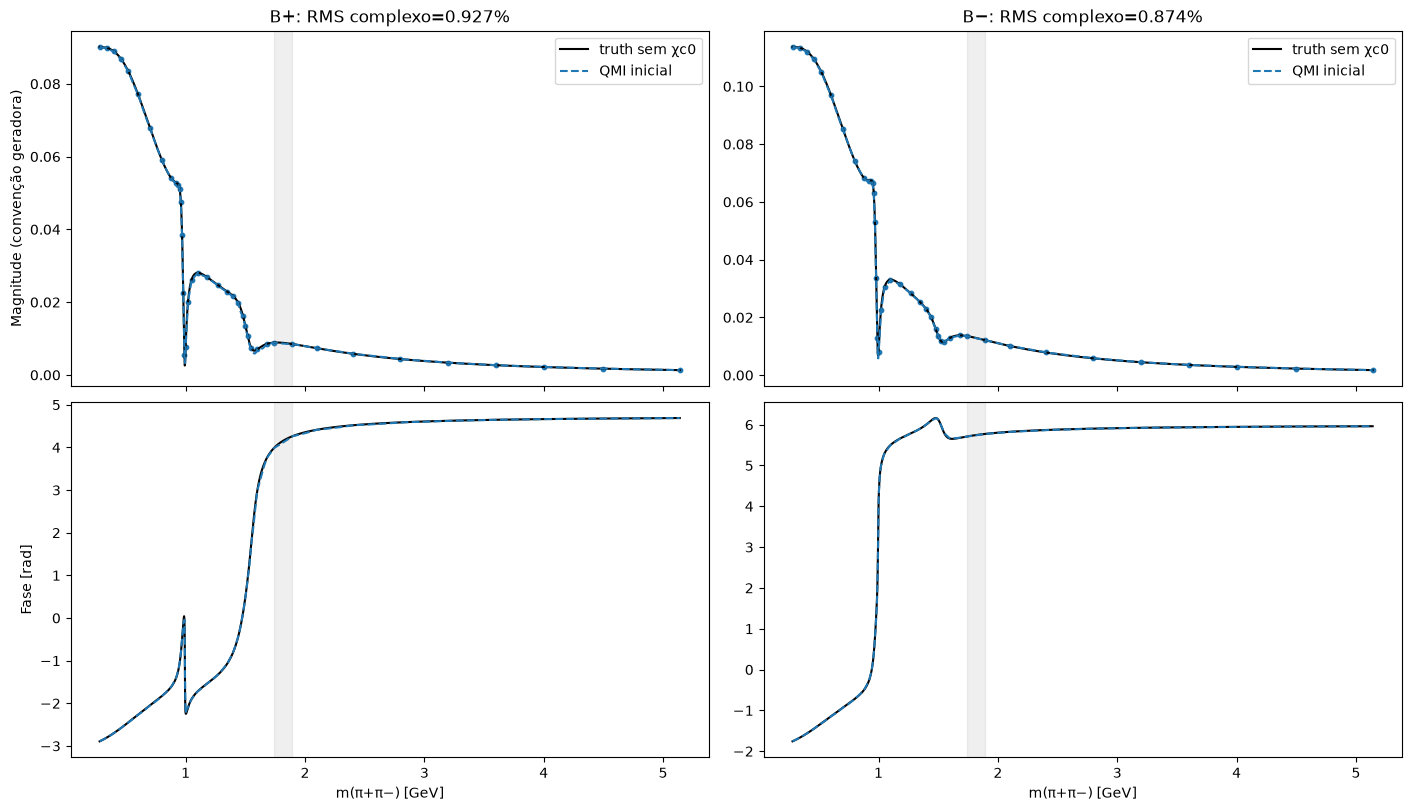

,charge,relative_complex_rms
0,1,0.009274
1,-1,0.008736


In [33]:
def resolved_qmi(charge, values):
    parts = QMI_NODE_PARAMETERS[charge]
    return QMI(
        knots=QMI_KNOTS,
        real_parts=tuple(float(p.resolve(values)) for p in parts["real"]),
        imaginary_parts=tuple(float(p.resolve(values)) for p in parts["imag"]),
        interpolation=QMI_INTERPOLATION,
    )


def qmi_single_pair(charge, masses, values):
    context = component_by_name(fit_models[charge], "S_QMI").function.context.resolve(values)
    return np.asarray(resolved_qmi(charge, values)(jnp.asarray(masses), context))


def fitted_swave(charge, masses, values):
    return qmi_single_pair(charge, masses, values) + isobar_single_pair(
        charge, masses, ("chi_c0",), values
    )


def wrapped_difference(phase, reference):
    return np.angle(np.exp(1j * (np.asarray(phase) - np.asarray(reference))))


def phase_on_truth(amplitude, truth):
    # Mesmo representante angular local do truth; não é rotação de gauge.
    phase = np.unwrap(np.angle(truth)) + np.angle(amplitude * np.conj(truth))
    return np.where((np.abs(amplitude) > PHASE_MAG_FLOOR) &
                    (np.abs(truth) > PHASE_MAG_FLOOR), phase, np.nan)


MASS_SCAN = np.unique(np.r_[np.linspace(PAIR_MIN, PAIR_MAX, 1800),
                             np.linspace(3.34, 3.49, 240), QMI_KNOTS])
SCAN_OBSERVED = (MASS_SCAN < D0_VETO_MIN_GEV) | (MASS_SCAN > D0_VETO_MAX_GEV)
representation_rows = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for column, charge in enumerate((+1, -1)):
    truth = isobar_single_pair(charge, MASS_SCAN, REPLACED_S_NAMES)
    seed = qmi_single_pair(charge, MASS_SCAN, TRUE_VALUES)
    np.testing.assert_allclose(qmi_single_pair(charge, QMI_KNOTS, TRUE_VALUES),
                               TRUTH_QMI_NODES[charge], rtol=1e-11, atol=1e-12)
    mask = SCAN_OBSERVED
    rms = np.sqrt(np.mean(abs(seed[mask] - truth[mask])**2) / np.mean(abs(truth[mask])**2))
    representation_rows.append(dict(charge=charge, relative_complex_rms=rms))
    axes[0, column].plot(MASS_SCAN, abs(truth), color="black", label="truth sem χc0")
    axes[0, column].plot(MASS_SCAN, abs(seed), "--", label="QMI inicial")
    axes[0, column].scatter(QMI_KNOTS, abs(TRUTH_QMI_NODES[charge]), s=10)
    axes[1, column].plot(MASS_SCAN, np.unwrap(np.angle(truth)), color="black")
    axes[1, column].plot(MASS_SCAN, phase_on_truth(seed, truth), "--")
    axes[0, column].set_title(f"B{'+' if charge == 1 else '−'}: RMS complexo={rms:.3%}")
    axes[0, column].legend()
    axes[1, column].set_xlabel("m(π+π−) [GeV]")
    for ax in axes[:, column]:
        ax.axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, color="grey", alpha=.12)
axes[0, 0].set_ylabel("Magnitude (convenção geradora)")
axes[1, 0].set_ylabel("Fase [rad]")
plt.show()
display(pd.DataFrame(representation_rows))


## Assimetria de yield dos backgrounds

Idêntico ao notebook 22: `with_charge_asymmetry` normaliza cada forma pela sua própria integral
pós-veto na amostra de normalização de `plus_model`/`minus_model` (fixa, não depende do toy) e
escala por `(1 ∓ asym)`.

In [34]:
qqbar_plus_shape = _qqbar_plus_pdf.with_charge_asymmetry(
    plus_model.normalization_sample, veto=D0_VETO,
    asymmetry=QQBAR_YIELD_ASYMMETRY, charge=+1)
qqbar_minus_shape = _qqbar_minus_pdf.with_charge_asymmetry(
    minus_model.normalization_sample, veto=D0_VETO,
    asymmetry=QQBAR_YIELD_ASYMMETRY, charge=-1)
kpipibkg_plus_shape = _kpipibkg_pdf.with_charge_asymmetry(
    plus_model.normalization_sample, veto=D0_VETO,
    asymmetry=KPIPIBKG_YIELD_ASYMMETRY, charge=+1)
kpipibkg_minus_shape = _kpipibkg_pdf.with_charge_asymmetry(
    minus_model.normalization_sample, veto=D0_VETO,
    asymmetry=KPIPIBKG_YIELD_ASYMMETRY, charge=-1)


## Sessão CP e persistência por toy
Os arquivos são exclusivos deste estudo. Um manifesto verifica nodes, truth, opções, entradas e versão
do código local antes da retomada, impedindo misturar estudos incompatíveis. Cada toy salva valores e
**covariância completa HESSE** em NPZ antes de entrar no CSV. Fits inválidos são registrados, mas ficam
fora das bandas; pulls exigem também covariância precisa, positiva e não forçada. Exceções não interrompem os demais toys.


In [35]:
def build_toy_fit_session(iexpt):
    samples = load_toy_samples(iexpt)
    plus_data, n_dropped_plus = drop_zero_efficiency_events(samples[+1], plus_efficiency)
    minus_data, n_dropped_minus = drop_zero_efficiency_events(samples[-1], minus_efficiency)

    session = CPFitSession(
        plus_model, minus_model,
        plus_data, minus_data,
        extended=True,
        signal_yield=Parameter("n_signal", N_SIGNAL, fixed=True),
    )
    session = session.with_efficiency(plus_efficiency, minus_efficiency)
    session = session.with_veto(D0_VETO)
    session = session.with_background(
        "qqbar", qqbar_plus_shape, minus_shape=qqbar_minus_shape,
        yield_=Parameter("n_qqbar", N_QQBAR, fixed=True),
    )
    session = session.with_background(
        "kpipibkg", kpipibkg_plus_shape, minus_shape=kpipibkg_minus_shape,
        yield_=Parameter("n_kpipibkg", N_KPIPIBKG, fixed=True),
    )
    for penalty in QMI_SMOOTHNESS_CONSTRAINTS:
        session = session.with_constraint(penalty)
    return session, n_dropped_plus, n_dropped_minus



# Os parâmetros são obtidos dos modelos, sem manter uma sessão extra/cache em memória.
PARAMETERS_BY_NAME = {p.name: p for model in fit_models.values() for p in model.parameters}
FREE_PARAMETER_NAMES = [name for name, p in PARAMETERS_BY_NAME.items() if not p.fixed]
ISOBAR_FREE_NAMES = [name for name in FREE_PARAMETER_NAMES if not name.startswith("S_QMI.")]
START_VALUES = {name: float(PARAMETERS_BY_NAME[name].value) for name in FREE_PARAMETER_NAMES}
assert set(FREE_PARAMETER_NAMES) <= set(TRUE_VALUES)
assert PARAMETERS_BY_NAME["rho0_770.x"].fixed
assert PARAMETERS_BY_NAME["rho0_770.y"].fixed and PARAMETERS_BY_NAME["rho0_770.dy"].fixed
assert not PARAMETERS_BY_NAME["rho0_770.dx"].fixed
print(f"Parâmetros livres: {len(FREE_PARAMETER_NAMES)}")


def input_identity(path):
    path = path.resolve()
    stat = path.stat()
    return dict(path=str(path), size=stat.st_size, mtime_ns=stat.st_mtime_ns)


source_root = Path(__import__("dalitzplotfitter").__file__).parent
source_hash = hashlib.sha256()
for path in sorted(source_root.rglob("*.py")):
    source_hash.update(str(path.relative_to(source_root)).encode())
    source_hash.update(path.read_bytes())
STUDY_CONFIG = dict(
    qmi_smoothness=dict(strength=QMI_SMOOTHNESS_STRENGTH, weights=QMI_SMOOTHNESS_WEIGHTS),
    schema=1, convention="raw_QMI_fixed_unit_coefficient_rho_reference_single_pair",
    package_source_sha256=source_hash.hexdigest(),
    knots=QMI_KNOTS, interpolation=QMI_INTERPOLATION, coefficients=COEFFICIENT_SPECS,
    dynamics=DYNAMICS_SPECS, normalization=NORMALIZATION_CONFIG, fit=FIT_OPTIONS,
    inputs=[input_identity(p) for p in (TOY_FILE, ACC_FILE, QQBAR_BKG_FILE, KPIPI_BKG_FILE)],
    tree=TOY_TREE, histograms=[ACC_HIST_PLUS, ACC_HIST_MINUS, QQBAR_HIST_PLUS, QQBAR_HIST_MINUS, KPIPI_HIST],
    yields=[N_SIGNAL, N_QQBAR, N_KPIPIBKG],
    background_asymmetries=[QQBAR_YIELD_ASYMMETRY, KPIPIBKG_YIELD_ASYMMETRY],
    veto=[D0_VETO_MIN_GEV, D0_VETO_MAX_GEV], reference="rho0_770.x=1,y=dy=0,dx free",
    scales=ISOBAR_SCALES, free_parameters=FREE_PARAMETER_NAMES,
)
MANIFEST_TEXT = json.dumps(STUDY_CONFIG, sort_keys=True, indent=2)
STUDY_ID = hashlib.sha256(MANIFEST_TEXT.encode()).hexdigest()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = OUTPUT_DIR / "study_config.json"
if manifest_path.exists():
    if manifest_path.read_text() != MANIFEST_TEXT:
        raise ValueError("Configuração mudou: escolha outro OUTPUT_DIR para não misturar estudos")
elif TOY_RESULTS_CSV.exists() or list(OUTPUT_DIR.glob("toy_*.npz")):
    raise ValueError("Saídas sem manifesto: escolha outro OUTPUT_DIR")
else:
    manifest_path.write_text(MANIFEST_TEXT)


_RESULT_COLUMNS = ["iExpt", "valid", "covariance_ok", "edm", "nll", "nll_data", "smoothness_penalty", "n_plus", "n_minus",
                   "n_dropped_zero_eff_plus", "n_dropped_zero_eff_minus", "fit_time_s"] + [
    item for name in FREE_PARAMETER_NAMES for item in (name, f"{name}_error")
]


def covariance_file(iexpt):
    return OUTPUT_DIR / f"toy_{int(iexpt):04d}.npz"


def read_toy_results():
    if not TOY_RESULTS_CSV.exists():
        return pd.DataFrame(columns=_RESULT_COLUMNS)
    frame = pd.read_csv(TOY_RESULTS_CSV)
    if list(frame.columns) != _RESULT_COLUMNS or frame["iExpt"].duplicated().any():
        raise ValueError("CSV incompatível ou com iExpt duplicado")
    for column in ("valid", "covariance_ok"):
        flags = frame[column].astype(str).str.lower().map({"true": True, "false": False})
        if flags.isna().any():
            raise ValueError(f"Flags inválidos na coluna {column}")
        frame[column] = flags.astype(bool)
    missing = [int(i) for i in frame.iExpt if not covariance_file(i).exists()]
    if missing:
        raise ValueError(f"Covariâncias ausentes para toys {missing[:10]}")
    return frame


def run_toy(iexpt):
    session, dropped_plus, dropped_minus = build_toy_fit_session(iexpt)
    actual_names = {p.name for p in session.parameters if not p.fixed}
    assert actual_names == set(FREE_PARAMETER_NAMES), (actual_names ^ set(FREE_PARAMETER_NAMES))
    fit_t0 = time.time()
    result = session.fit(start_values=dict(START_VALUES), **FIT_OPTIONS)
    fit_time = time.time() - fit_t0
    values = session.result_values(result)
    covariance = np.full((len(FREE_PARAMETER_NAMES), len(FREE_PARAMETER_NAMES)), np.nan)
    if result.covariance is not None:
        covariance = np.array([[float(result.covariance[a, b]) for b in FREE_PARAMETER_NAMES]
                               for a in FREE_PARAMETER_NAMES])
    covariance_ok = bool(result.fmin.has_accurate_covar and result.fmin.has_posdef_covar
                         and not result.fmin.has_made_posdef_covar
                         and np.isfinite(covariance).all())
    row = dict(iExpt=int(iexpt), valid=bool(result.valid), covariance_ok=covariance_ok,
               edm=float(result.fmin.edm), nll=float(result.fval),
               nll_data=float(session.base_objective(values)),
               smoothness_penalty=float(sum(p(values) for p in QMI_SMOOTHNESS_CONSTRAINTS)),
               n_plus=session.plus_data.size, n_minus=session.minus_data.size,
               n_dropped_zero_eff_plus=dropped_plus, n_dropped_zero_eff_minus=dropped_minus,
               fit_time_s=fit_time)
    for name in FREE_PARAMETER_NAMES:
        row[name] = float(values[name])
        row[f"{name}_error"] = float(result.errors[name])
    # Substituição atômica: o CSV só registra o toy depois da covariância estar no disco.
    target = covariance_file(iexpt)
    temporary = target.with_suffix(".tmp")
    with temporary.open("wb") as handle:
        np.savez_compressed(handle, names=np.asarray(FREE_PARAMETER_NAMES), covariance=covariance,
                            values=np.array([values[n] for n in FREE_PARAMETER_NAMES]), study_id=STUDY_ID)
    temporary.replace(target)
    return row


Parâmetros livres: 185


In [36]:
existing_results = read_toy_results()
_completed = set(existing_results["iExpt"].astype(int))
_pending = [i for i in TOY_INDICES if i not in _completed]
print(f"{len(_completed)} toys salvos; {len(_pending)} pendentes na seleção")
if RUN_TOY_FITS:
    for iexpt in _pending:
        try:
            row = run_toy(iexpt)
            updated = pd.concat([existing_results, pd.DataFrame([row])], ignore_index=True)
            temporary = TOY_RESULTS_CSV.with_suffix(".tmp")
            updated.to_csv(temporary, index=False, columns=_RESULT_COLUMNS)
            temporary.replace(TOY_RESULTS_CSV)
            existing_results = updated
            print(f"iExpt={iexpt}: valid={row['valid']}, cov={row['covariance_ok']}, "
                  f"NLL={row['nll']:.3f}, tempo={row['fit_time_s']:.1f}s")
        except Exception as exc:
            with (OUTPUT_DIR / "failures.jsonl").open("a") as handle:
                handle.write(json.dumps(dict(iExpt=int(iexpt), error=repr(exc))) + "\n")
            print(f"iExpt={iexpt}: FAILED ({exc})")
else:
    print("RUN_TOY_FITS=False: apenas diagnóstico dos resultados salvos")


2 toys salvos; 8 pendentes na seleção
iExpt=2: valid=True, cov=True, NLL=-495807.934, tempo=75.0s
iExpt=3: valid=True, cov=True, NLL=-492103.662, tempo=79.4s
iExpt=4: valid=True, cov=True, NLL=-492450.393, tempo=91.3s
iExpt=5: valid=True, cov=True, NLL=-488663.045, tempo=70.2s
iExpt=6: valid=True, cov=True, NLL=-496488.527, tempo=81.5s
iExpt=7: valid=True, cov=True, NLL=-495268.340, tempo=76.5s
iExpt=8: valid=True, cov=True, NLL=-493646.079, tempo=84.0s
iExpt=9: valid=True, cov=True, NLL=-494961.755, tempo=91.0s


## Seleção, propagação da covariância e pulls dos nodes
Todas as estatísticas abaixo se restringem a `TOY_INDICES`. As bandas usam fits válidos; os pulls também
exigem `covariance_ok`. Registramos explicitamente os números selecionados/excluídos.
Para $z=x+iy$, propagamos a submatriz correlacionada de Re/Im com
\[
 J=\begin{pmatrix}x/|z|&y/|z|\\-y/|z|^2&x/|z|^2\end{pmatrix},\qquad
 V_{|z|,\phi}=J V_{x,y}J^T.
\]
Essa submatriz vem da inversa Hessiana do **fit inteiro**, portanto já inclui a marginalização dos outros parâmetros.
Os pulls são $(|z|-|z_t|)/\sigma_{|z|}$ e $\mathrm{Arg}(z z_t^*)/\sigma_\phi$.
Fase no zero e erros não positivos geram NaN, nunca erro zero artificial. Próximo de magnitude zero,
a aproximação gaussiana/delta para a fase pode deixar de descrever bem a distribuição.


In [37]:
toy_results = read_toy_results()
toy_results = toy_results[toy_results["iExpt"].isin(list(TOY_INDICES))].copy()
toy_results_valid = toy_results.loc[toy_results["valid"].eq(True)].copy()
toy_results_pulls = toy_results_valid.loc[toy_results_valid["covariance_ok"].eq(True)].copy()
print(f"Seleção: {len(toy_results)}/{len(TOY_INDICES)} salvos, {len(toy_results_valid)} válidos, "
      f"{len(toy_results_pulls)} com covariância utilizável para pulls")


def polar_errors(z, covariance):
    if abs(z) <= PHASE_MAG_FLOOR or not np.isfinite(covariance).all():
        return np.nan, np.nan
    x, y, radius = z.real, z.imag, abs(z)
    jacobian = np.array([[x / radius, y / radius], [-y / radius**2, x / radius**2]])
    variances = np.diag(jacobian @ covariance @ jacobian.T)
    return tuple(np.sqrt(v) if np.isfinite(v) and v > 0 else np.nan for v in variances)


def safe_pull(delta, error):
    return float(delta / error) if np.isfinite(error) and error > 0 else np.nan


node_rows = []
for _, fit_row in toy_results_valid.iterrows():
    with np.load(covariance_file(fit_row.iExpt), allow_pickle=False) as saved:
        if str(saved["study_id"].item()) != STUDY_ID:
            raise ValueError("Covariância pertence a outro estudo")
        names = saved["names"].tolist()
        if names != FREE_PARAMETER_NAMES:
            raise ValueError("Ordem dos parâmetros não corresponde à covariância")
        np.testing.assert_allclose(saved["values"], fit_row[FREE_PARAMETER_NAMES].to_numpy(dtype=float))
        covariance = saved["covariance"]
    for charge in (+1, -1):
        parts = QMI_NODE_PARAMETERS[charge]
        truths = TRUTH_QMI_NODES[charge]
        truth_phases = np.unwrap(np.angle(truths))
        for i, mass in enumerate(QMI_KNOTS):
            real_name, imag_name = parts["real"][i].name, parts["imag"][i].name
            z = complex(fit_row[real_name], fit_row[imag_name])
            indices = [names.index(real_name), names.index(imag_name)]
            mag_error, phase_error = polar_errors(z, covariance[np.ix_(indices, indices)])
            if not fit_row.covariance_ok:
                mag_error = phase_error = np.nan
            defined = abs(z) > PHASE_MAG_FLOOR and abs(truths[i]) > PHASE_MAG_FLOOR
            phase_delta = wrapped_difference(np.angle(z), np.angle(truths[i])) if defined else np.nan
            node_rows.append(dict(
                iExpt=int(fit_row.iExpt), charge=charge, node=i, mass=mass,
                magnitude=abs(z), magnitude_truth=abs(truths[i]), magnitude_error=mag_error,
                magnitude_pull=safe_pull(abs(z) - abs(truths[i]), mag_error),
                phase=float(truth_phases[i] + phase_delta), phase_truth=truth_phases[i],
                phase_error=phase_error, phase_pull=safe_pull(phase_delta, phase_error),
            ))
NODE_COLUMNS = ["iExpt", "charge", "node", "mass", "magnitude", "magnitude_truth", "magnitude_error",
                "magnitude_pull", "phase", "phase_truth", "phase_error", "phase_pull"]
node_results = pd.DataFrame(node_rows, columns=NODE_COLUMNS)
node_results.to_csv(NODE_RESULTS_CSV, index=False)
display(node_results.head())


def finish_figure(fig, name):
    if SAVE_FIGURES:
        directory = OUTPUT_DIR / "figures"
        directory.mkdir(exist_ok=True)
        fig.savefig(directory / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


Seleção: 10/10 salvos, 10 válidos, 10 com covariância utilizável para pulls


,iExpt,charge,node,mass,magnitude,magnitude_truth,magnitude_error,magnitude_pull,phase,phase_truth,phase_error,phase_pull
0,0,1,0,0.279141,0.096642,0.090165,0.006771,0.956633,-3.215370,-2.891647,0.456157,-0.709673
1,0,1,1,0.340000,0.088605,0.089874,0.003018,-0.420448,-3.024181,-2.802086,0.318829,-0.696595
2,0,1,2,0.400000,0.085654,0.088888,0.002770,-1.167368,-2.740168,-2.695612,0.166771,-0.267169
3,0,1,3,0.460000,0.086650,0.086788,0.002758,-0.049956,-2.441660,-2.575534,0.095768,1.397889
4,0,1,4,0.520000,0.086444,0.083429,0.002598,1.160609,-2.288990,-2.446400,0.070089,2.245870


## Histogramas originais: coeficientes isobáricos mantidos
Preservamos valor, erro e pull para cada parâmetro CP livre dos componentes mantidos, incluindo χc0.
O ajuste gaussiano é auxiliar e só é tentado com pelo menos 10 entradas e dispersão não nula;
amostras pequenas ou ajustes malsucedidos continuam tendo seus histogramas e momentos amostrais.
Os histogramas mostram todos os valores finitos (inclusive tails), sem cortar pulls em ±5.


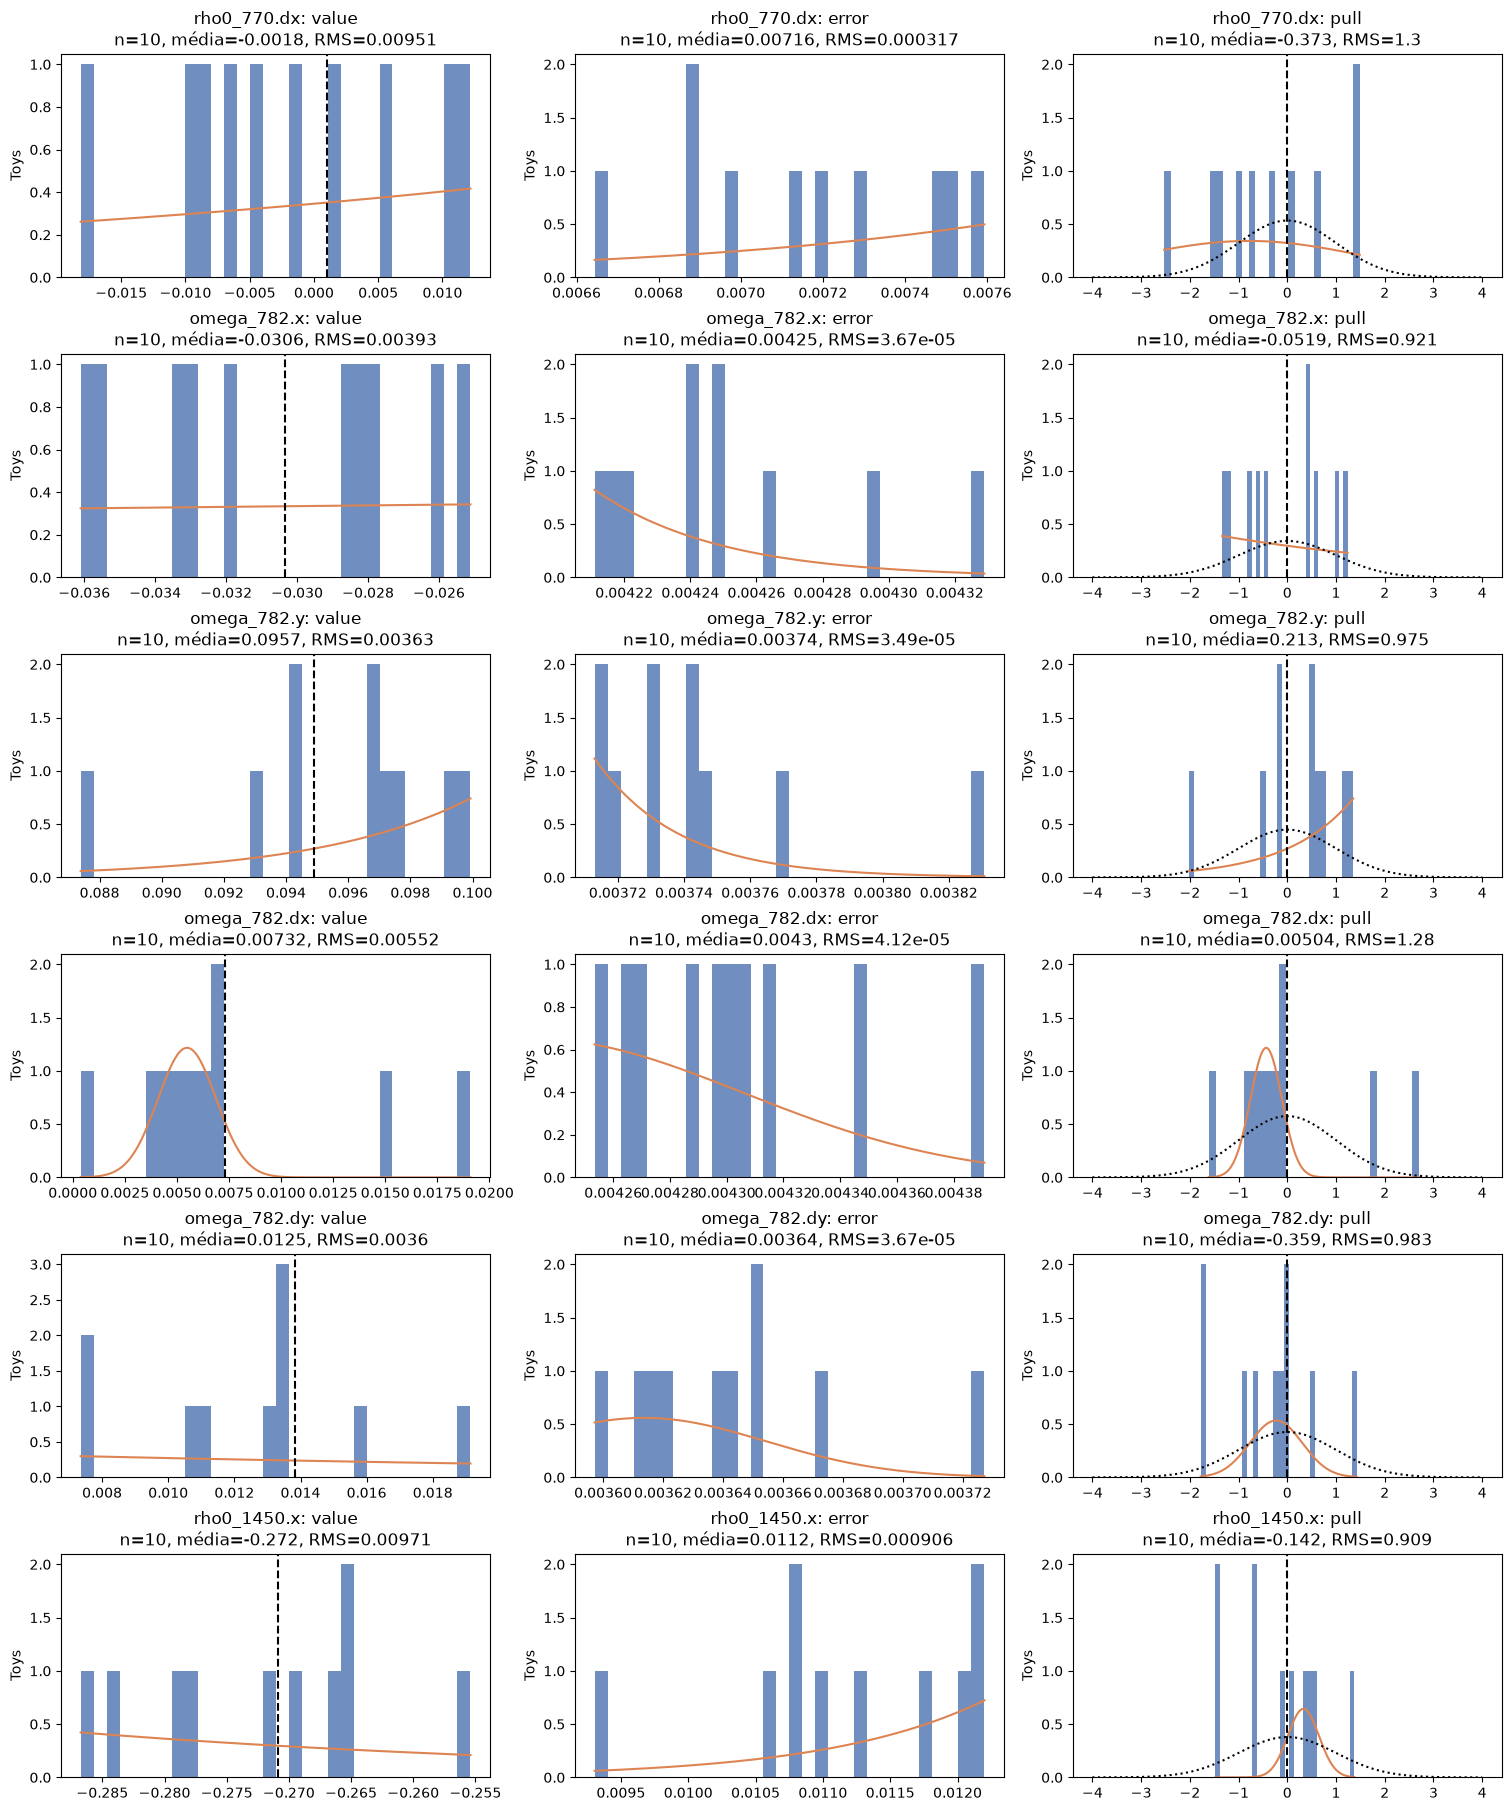

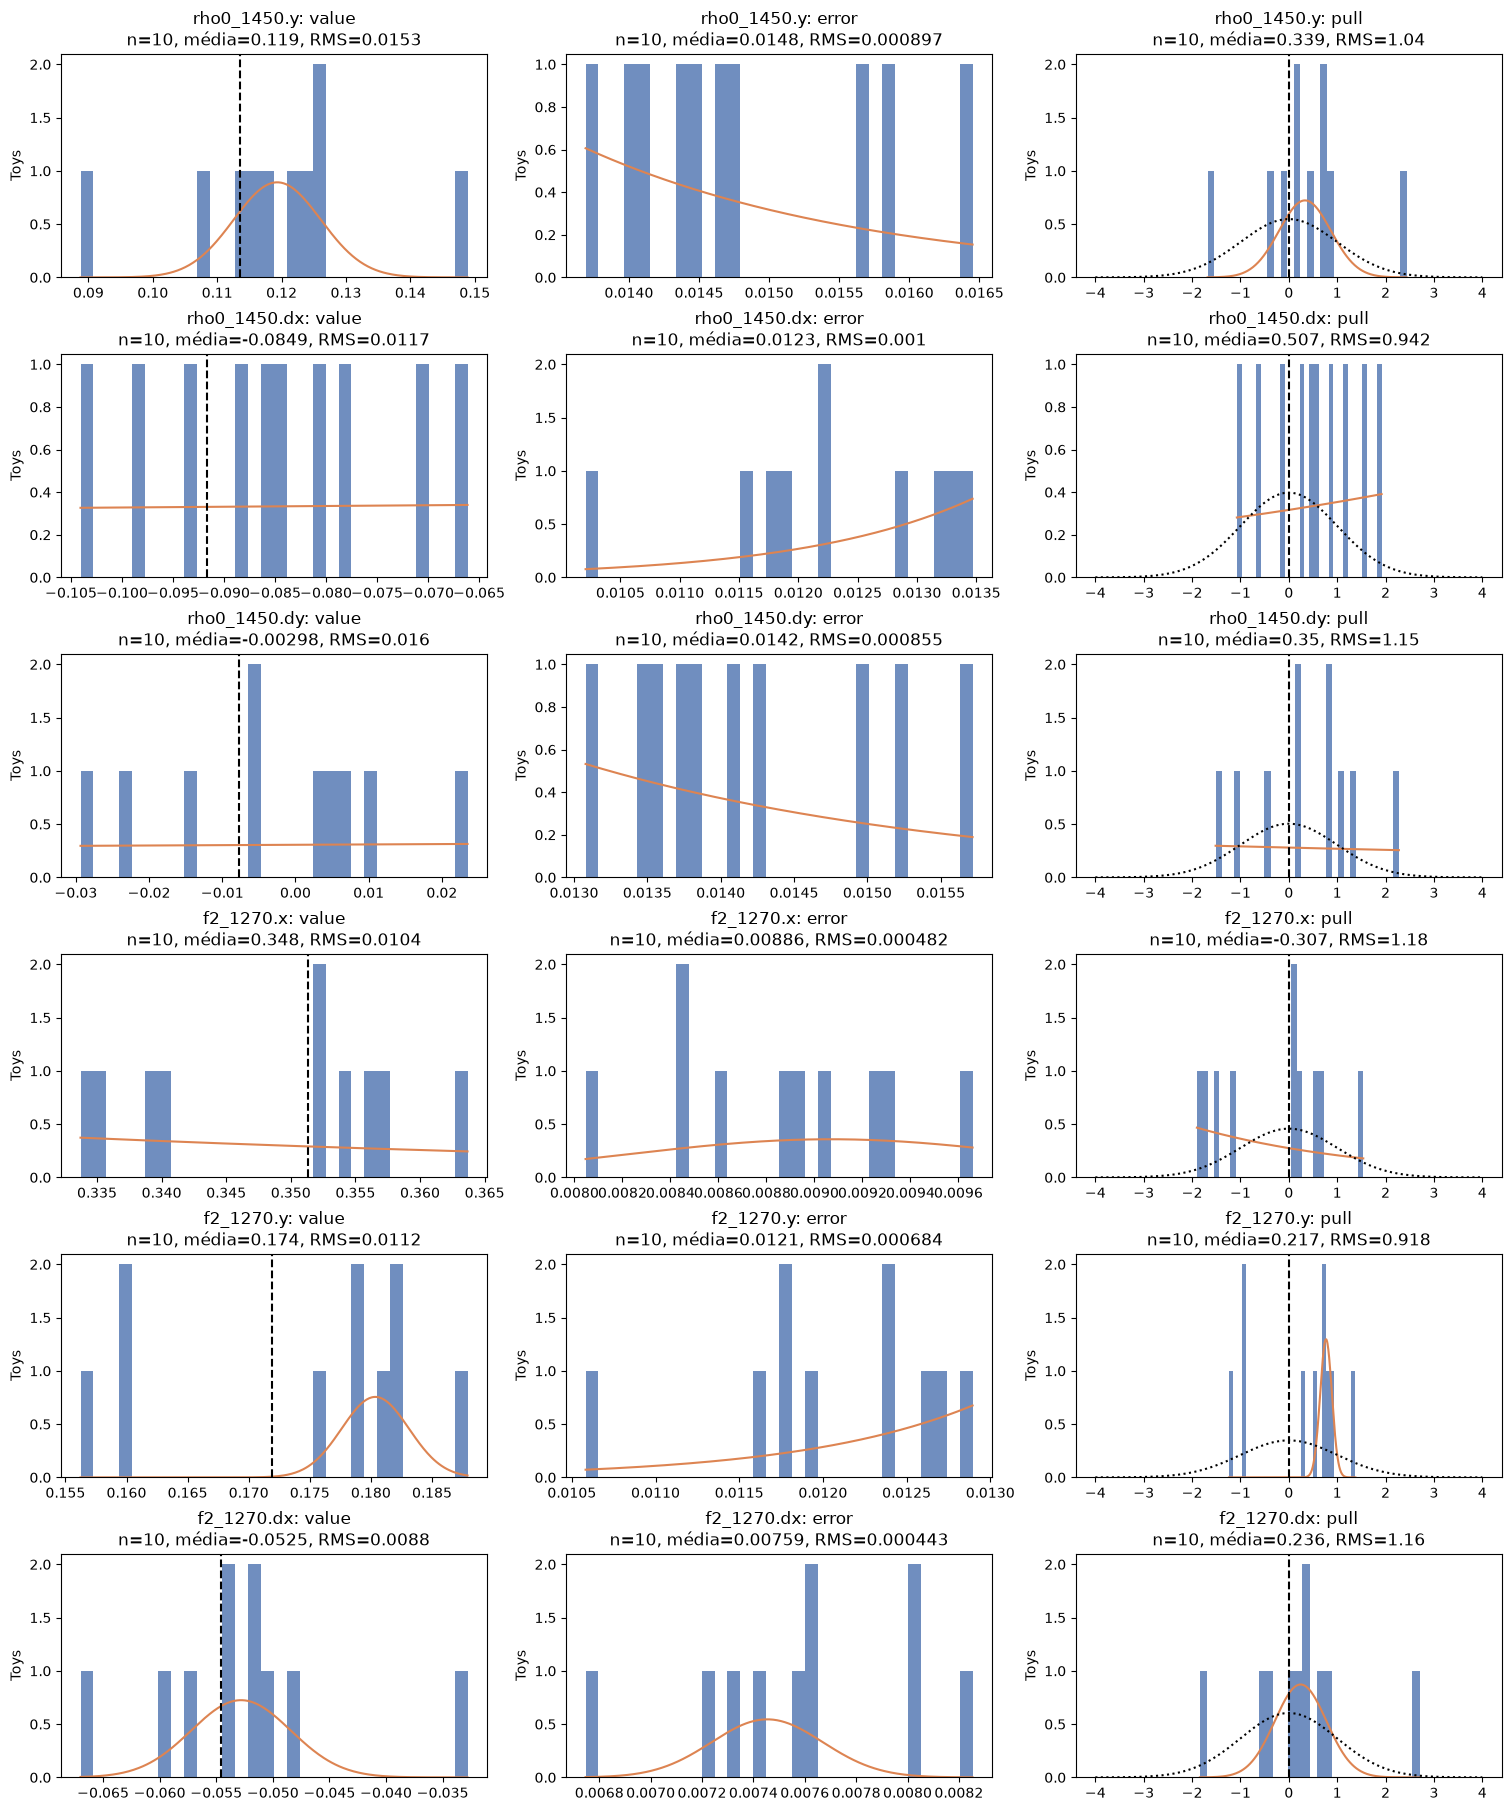

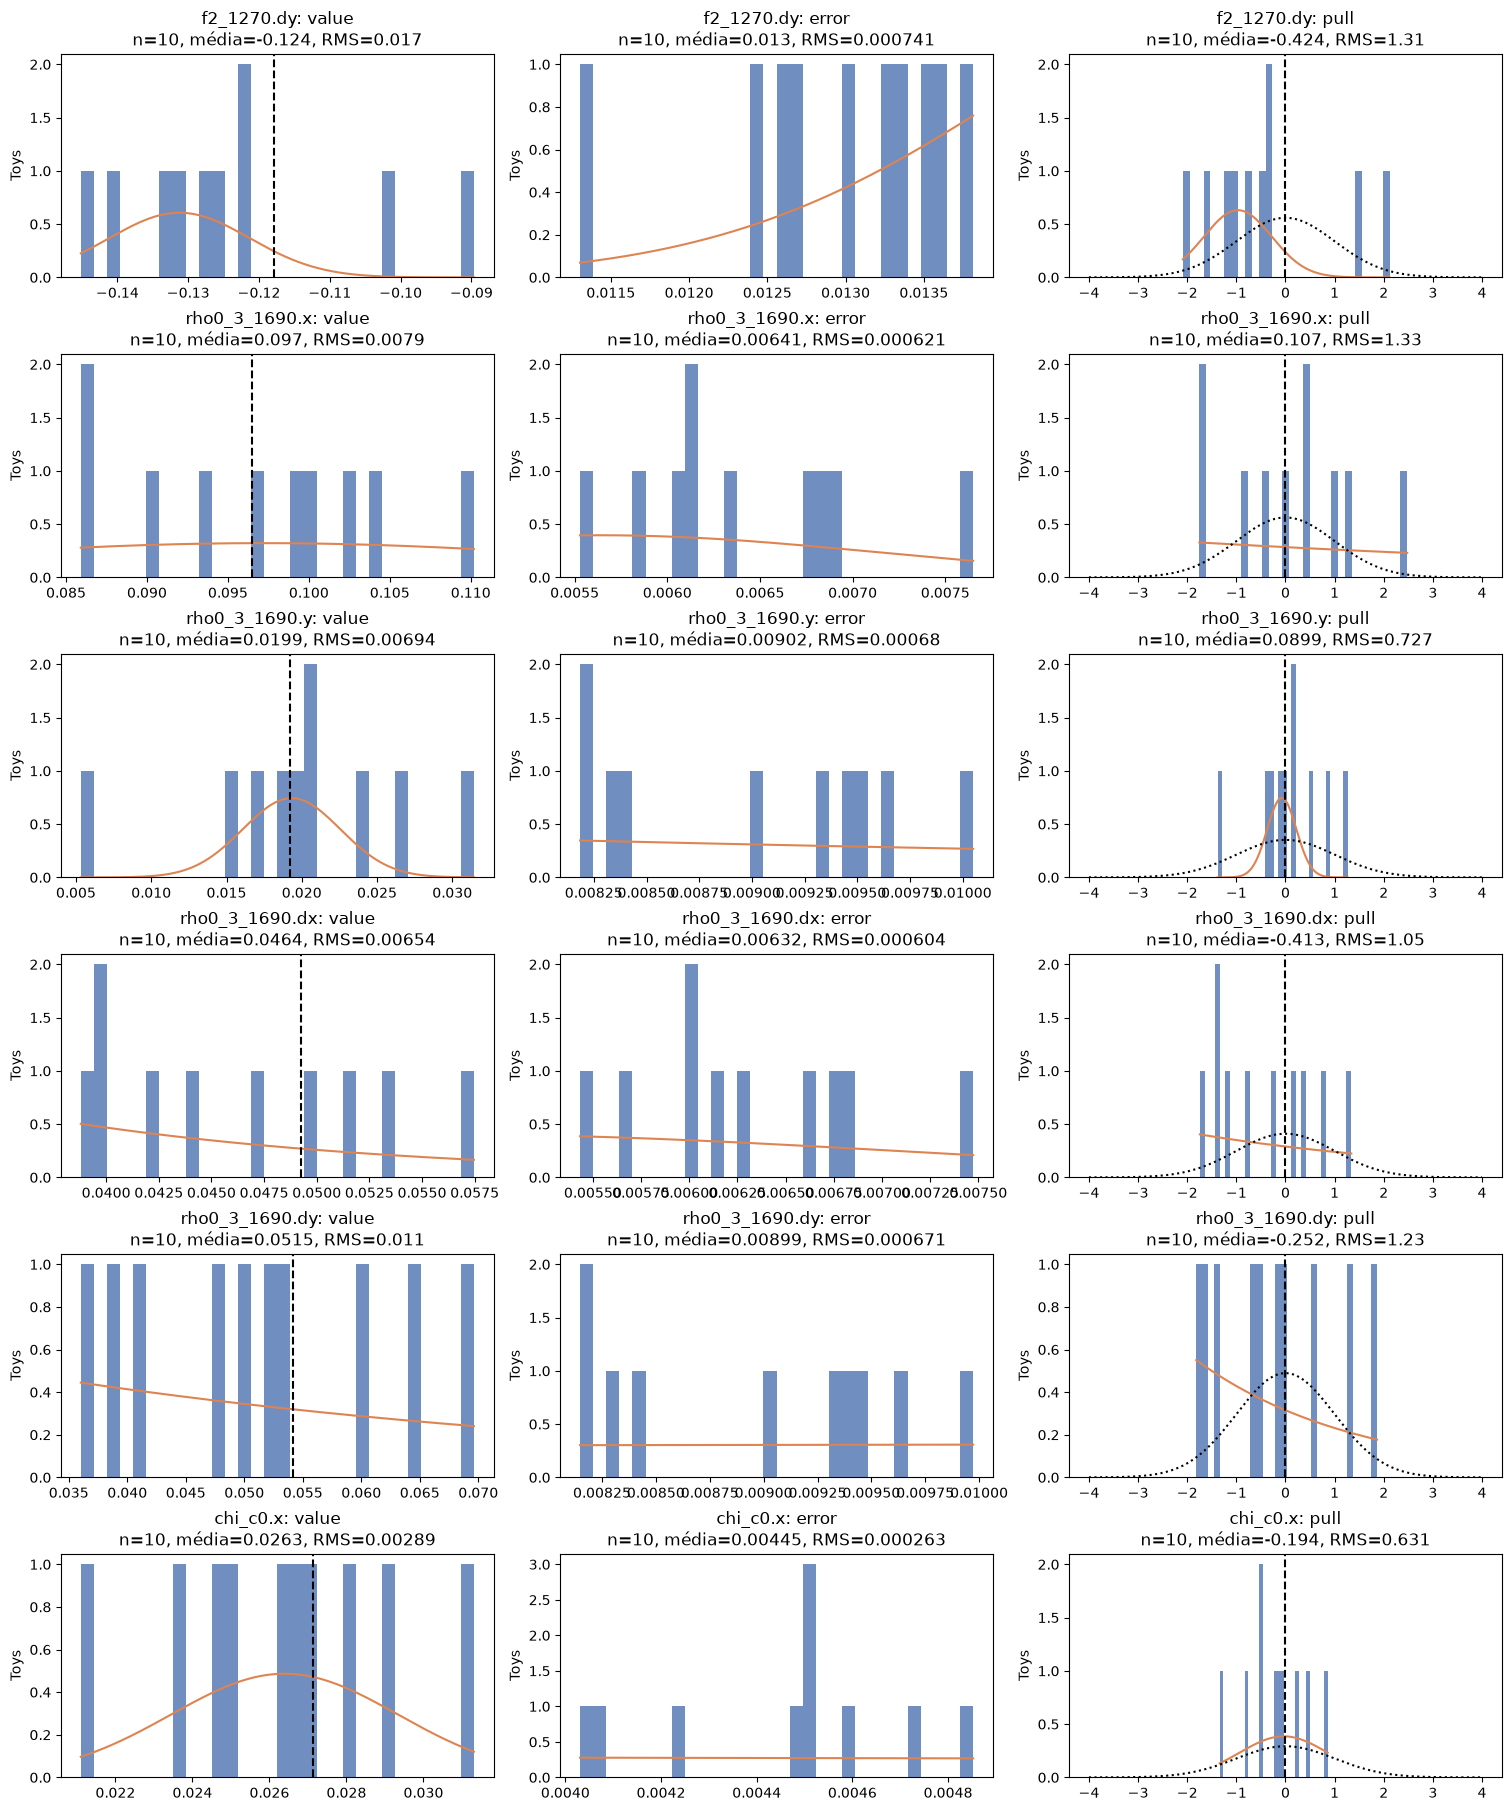

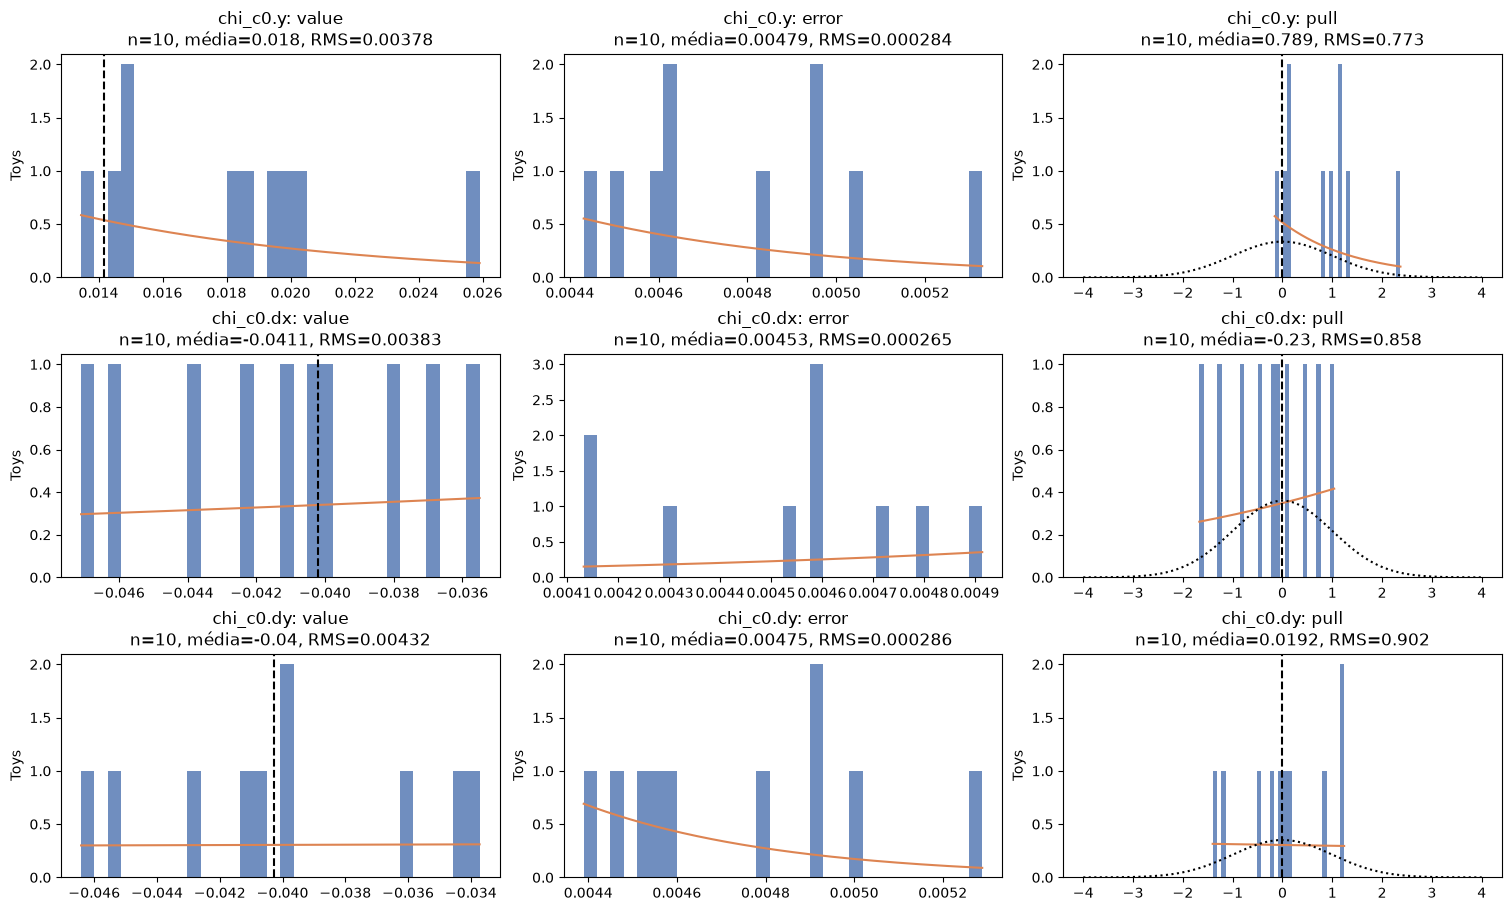

,parameter,kind,truth,n,mean,std,gaussian_mu,gaussian_sigma,gaussian_mu_error,gaussian_sigma_error
0,rho0_770.dx,value,0.001023,10,-0.001805,0.009511,1.873581,0.349397,3.706894e+03,3.452632e+02
1,rho0_770.dx,error,0.001023,10,0.007159,0.000317,0.097574,0.008796,1.851965e-01,1.803963e-02
2,rho0_770.dx,pull,0.001023,10,-0.373471,1.296712,-0.788438,2.326854,3.366064e+00,7.097419e+00
3,omega_782.x,value,-0.030327,10,-0.030561,0.003926,1.635293,0.568320,6.563513e+04,1.119595e+04
4,omega_782.x,error,-0.030327,10,0.004251,0.000037,-0.004647,0.000581,1.032216e-02,6.737546e-04
...,...,...,...,...,...,...,...,...,...,...
58,chi_c0.dx,error,-0.040204,10,0.004528,0.000265,0.062165,0.007284,1.894466e-01,2.398471e-02
59,chi_c0.dx,pull,-0.040204,10,-0.229672,0.858457,141.942030,28.762101,2.389758e+05,2.417261e+04
60,chi_c0.dy,value,-0.040267,10,-0.040011,0.004317,1.667476,0.805427,1.117484e+05,2.635555e+04
61,chi_c0.dy,error,-0.040267,10,0.004746,0.000286,-0.064735,0.005532,8.946510e-02,7.136626e-03


In [38]:
def _gaussian(x, amplitude, mu, sigma):
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma)**2)


def plot_histogram(ax, data, title, reference=None, pull=False):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    summary = dict(n=len(data), mean=float(data.mean()) if len(data) else np.nan,
                   std=float(data.std(ddof=1)) if len(data) > 1 else np.nan,
                   gaussian_mu=np.nan, gaussian_sigma=np.nan,
                   gaussian_mu_error=np.nan, gaussian_sigma_error=np.nan)
    if len(data):
        counts, edges, _ = ax.hist(data, bins=30, color="#4C72B0", alpha=.8)
        centers = (edges[:-1] + edges[1:]) / 2
        if len(data) >= 10 and data.std() > 1e-12:
            try:
                params, covariance = curve_fit(
                    _gaussian, centers, counts,
                    p0=(max(counts.max(), 1), data.mean(), data.std()),
                    sigma=np.sqrt(np.maximum(counts, 1)), absolute_sigma=True,
                    bounds=([0, -np.inf, 1e-12], [np.inf, np.inf, np.inf]), maxfev=10000,
                )
                if np.isfinite(covariance).all():
                    xx = np.linspace(edges[0], edges[-1], 300)
                    ax.plot(xx, _gaussian(xx, *params), color="#DD8452", label="Gauss ajustada")
                    summary.update(gaussian_mu=params[1], gaussian_sigma=params[2],
                                   gaussian_mu_error=np.sqrt(covariance[1, 1]),
                                   gaussian_sigma_error=np.sqrt(covariance[2, 2]))
            except (RuntimeError, ValueError, FloatingPointError):
                pass
        if pull:
            xx = np.linspace(min(edges[0], -4), max(edges[-1], 4), 400)
            ax.plot(xx, len(data) * np.diff(edges)[0] / np.sqrt(2*np.pi) * np.exp(-xx**2/2),
                    "k:", label="N(0,1)")
        ax.set_title(f"{title}\nn={len(data)}, média={summary['mean']:.3g}, RMS={summary['std']:.3g}")
    else:
        ax.set_title(title + "\nsem entradas elegíveis")
    if reference is not None:
        ax.axvline(reference, color="black", linestyle="--")
    ax.set_ylabel("Toys")
    return summary


isobar_summary = []
for start in range(0, len(ISOBAR_FREE_NAMES), 6):
    page_names = ISOBAR_FREE_NAMES[start:start+6]
    fig, axes = plt.subplots(len(page_names), 3, figsize=(15, 3*len(page_names)),
                              squeeze=False, constrained_layout=True)
    for row_index, name in enumerate(page_names):
        selected = toy_results_pulls
        values = selected[name].to_numpy(dtype=float)
        errors = selected[f"{name}_error"].to_numpy(dtype=float)
        pulls = np.divide(values - TRUE_VALUES[name], errors,
                          out=np.full_like(values, np.nan), where=np.isfinite(errors) & (errors > 0))
        for column, (kind, data, reference) in enumerate((
            ("value", values, TRUE_VALUES[name]), ("error", errors, None), ("pull", pulls, 0),
        )):
            stats = plot_histogram(axes[row_index, column], data, f"{name}: {kind}", reference, kind == "pull")
            isobar_summary.append(dict(parameter=name, kind=kind, truth=TRUE_VALUES[name], **stats))
    finish_figure(fig, f"isobar_histograms_{start//6:02d}")
isobar_summary = pd.DataFrame(isobar_summary)
isobar_summary.to_csv(OUTPUT_DIR / "isobar_summary.csv", index=False)
display(isobar_summary)


## S-wave completa: magnitude, fase e bandas dos N fits
Preto: truth `sigma0 + f0_980 + f0_1370 + chi_c0`. Curvas azuis: cada fit válido `QMI + chi_c0`,
com os coeficientes χc0 desse fit. A linha central é a mediana pontual; bandas mostram **mínimo–máximo**
e **percentis 16–84% entre toys**, não intervalos de confiança de um único fit. São calculadas separadamente
para magnitude e fase, portanto a mediana não precisa corresponder a uma única amplitude complexa.
As fases são mostradas na vizinhança angular do truth em cada massa, sem ajustar escala ou offset.
Se as fases abrangerem quase $2\pi$, consulte também o Argand: quantis lineares ficam dependentes do corte angular.
A região cinza é o intervalo de massa vetado; os valores ali são apenas interpolação.


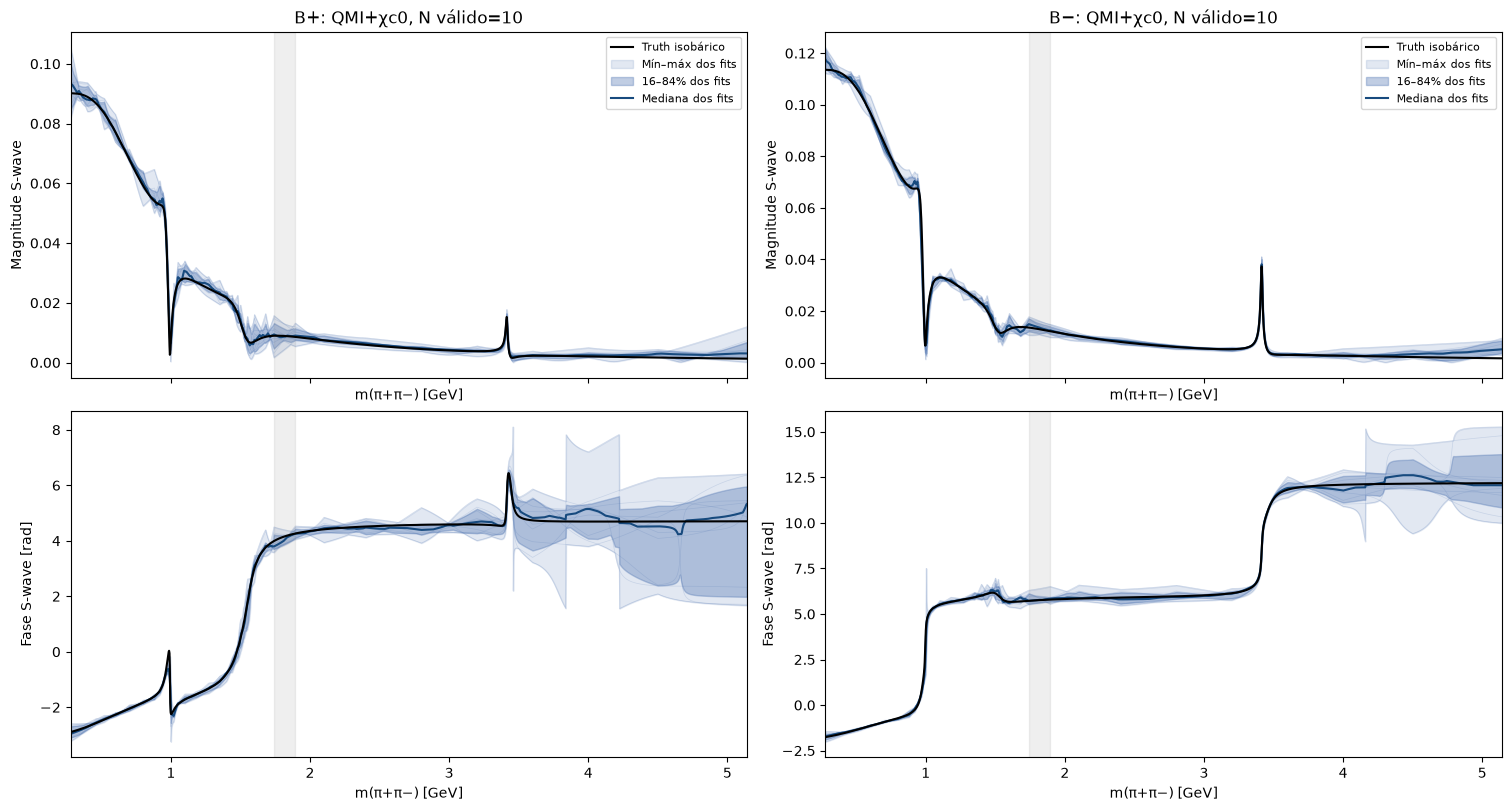

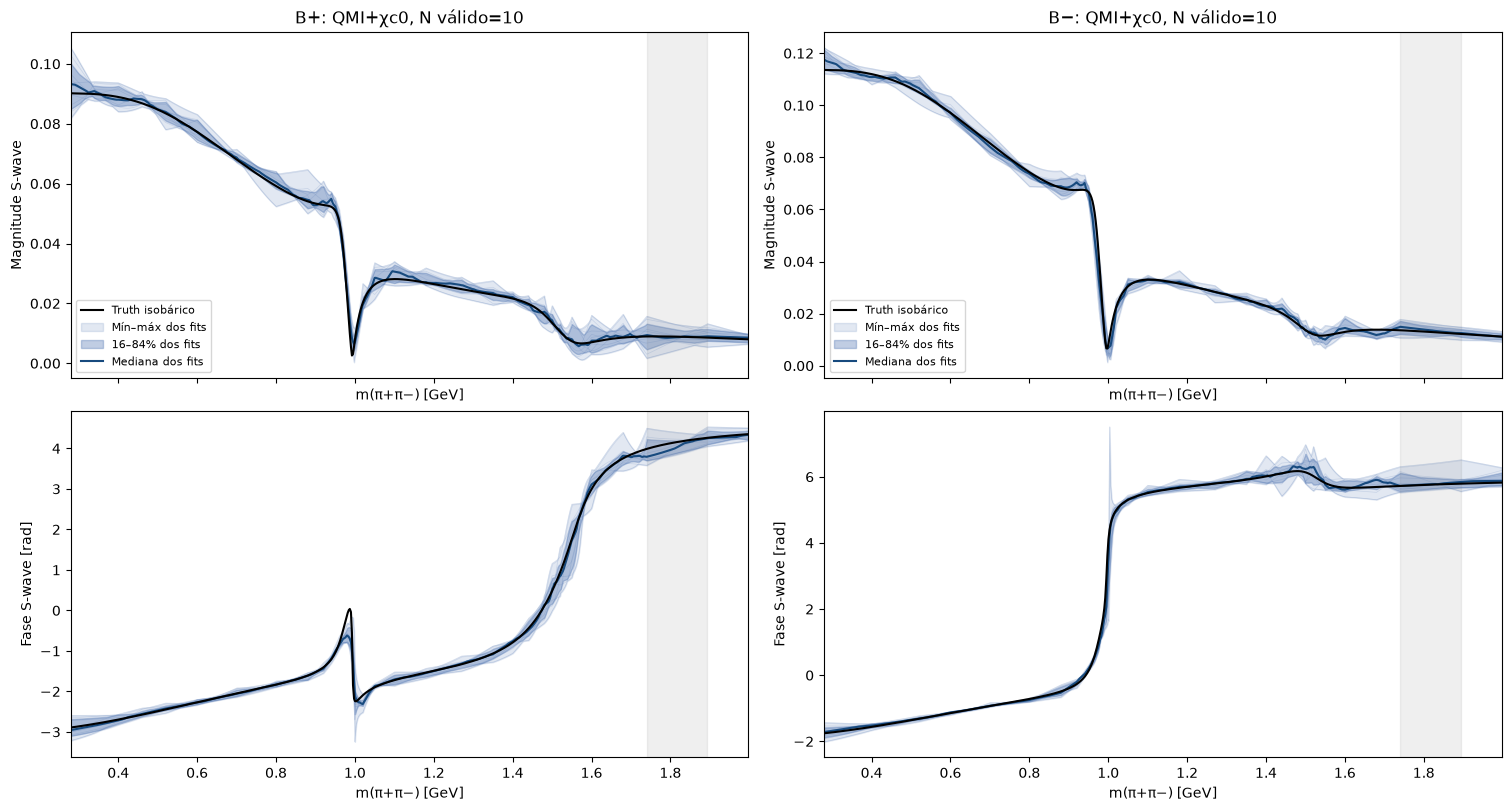

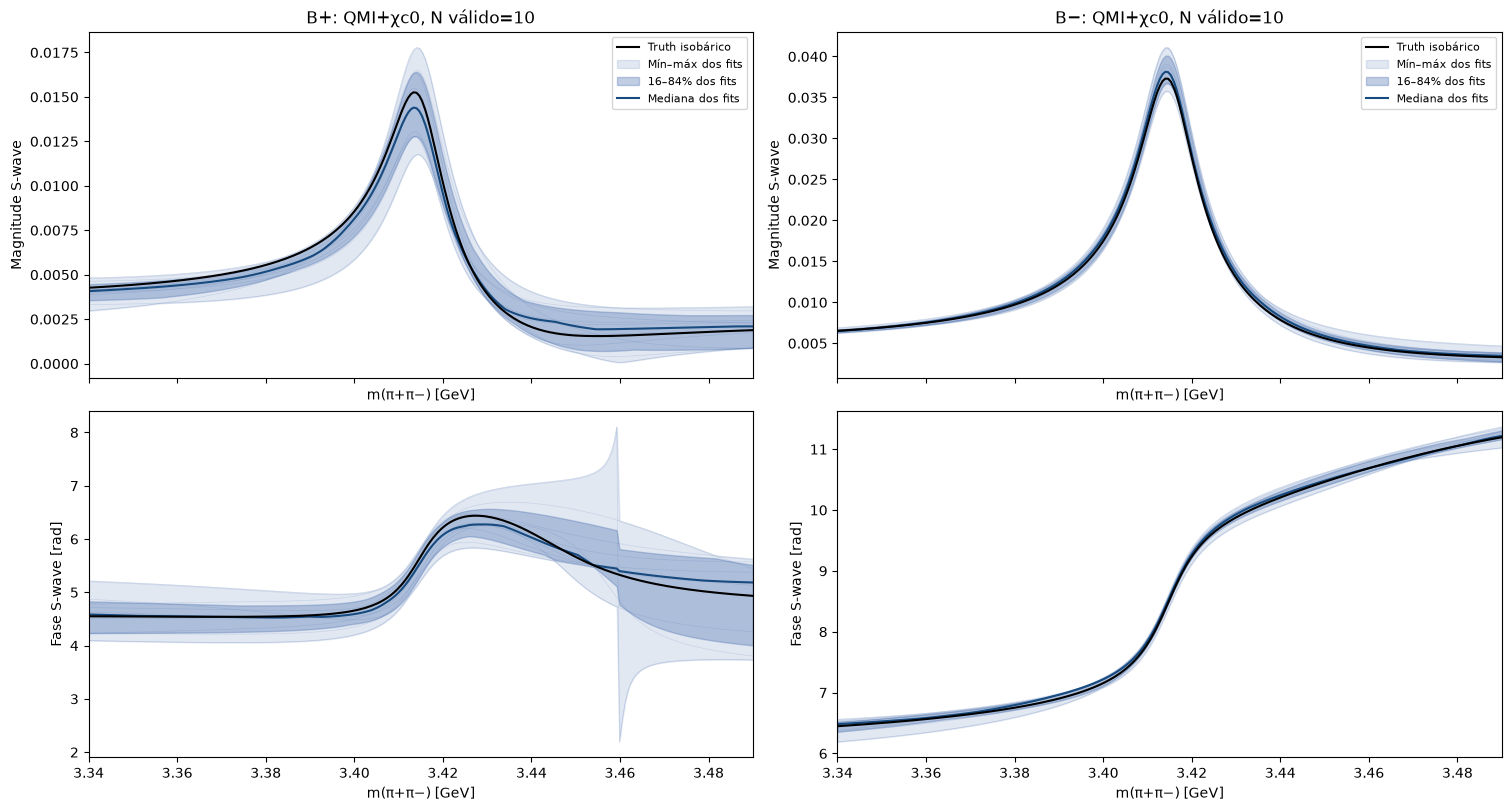

In [39]:
SWAVE_ENSEMBLES = {}
for charge in (+1, -1):
    curves = [fitted_swave(charge, MASS_SCAN, row.to_dict()) for _, row in toy_results_valid.iterrows()]
    SWAVE_ENSEMBLES[charge] = np.asarray(curves, dtype=complex).reshape((-1, len(MASS_SCAN)))


def plot_ensemble(ax, masses, ensemble, truth, ylabel):
    ax.plot(masses, truth, color="black", lw=1.5, label="Truth isobárico", zorder=5)
    if len(ensemble):
        # Colunas sem fase definida são mantidas como NaN, sem avisos de all-NaN.
        quantiles = np.full((5, ensemble.shape[1]), np.nan)
        finite_columns = np.isfinite(ensemble).any(axis=0)
        quantiles[:, finite_columns] = np.nanpercentile(ensemble[:, finite_columns], [0, 16, 50, 84, 100], axis=0)
        low, p16, median, p84, high = quantiles
        if SHOW_INDIVIDUAL_CURVES:
            ax.plot(masses, ensemble.T, color="#4C72B0", alpha=min(.18, 3/max(len(ensemble), 1)), lw=.5)
        ax.fill_between(masses, low, high, color="#4C72B0", alpha=.16, label="Mín–máx dos fits")
        ax.fill_between(masses, p16, p84, color="#4C72B0", alpha=.35, label="16–84% dos fits")
        ax.plot(masses, median, color="#174A7E", label="Mediana dos fits")
    else:
        ax.text(.5, .8, "Nenhum fit válido salvo", transform=ax.transAxes, ha="center")
    ax.axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, color="grey", alpha=.12)
    ax.set_xlim(float(masses[0]), float(masses[-1]))
    ax.set_ylabel(ylabel)
    ax.set_xlabel("m(π+π−) [GeV]")


for label, upper in (("full", PAIR_MAX), ("low_mass", 2.0), ("chi_c0", 3.49)):
    mask = MASS_SCAN <= upper
    if label == "chi_c0":
        mask &= MASS_SCAN >= 3.34
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, constrained_layout=True)
    for column, charge in enumerate((+1, -1)):
        truth = isobar_single_pair(charge, MASS_SCAN)
        curves = SWAVE_ENSEMBLES[charge]
        phases = phase_on_truth(curves, truth)
        truth_phase = np.where(abs(truth) > PHASE_MAG_FLOOR, np.unwrap(np.angle(truth)), np.nan)
        plot_ensemble(axes[0, column], MASS_SCAN[mask], abs(curves[:, mask]), abs(truth[mask]), "Magnitude S-wave")
        plot_ensemble(axes[1, column], MASS_SCAN[mask], phases[:, mask], truth_phase[mask], "Fase S-wave [rad]")
        axes[0, column].set_title(f"B{'+' if charge == 1 else '−'}: QMI+χc0, N válido={len(curves)}")
        axes[0, column].legend(fontsize=8)
    finish_figure(fig, f"swave_{label}")


## Faixas percorridas pelos nodes: magnitude e fase da QMI sem χc0
Estes gráficos são separados das curvas da S-wave completa: cada ponto/faixa descreve um **node**.
Mostramos todos os valores dos fits válidos, mínimo–máximo, 16–84% e truth. São faixas observadas
entre os N ajustes, não limites impostos no minimizador: Re/Im estão livres, sem bounds artificiais;
magnitude/fase são observáveis derivados. A fase de cada node usa o mesmo ramo local do seu truth.


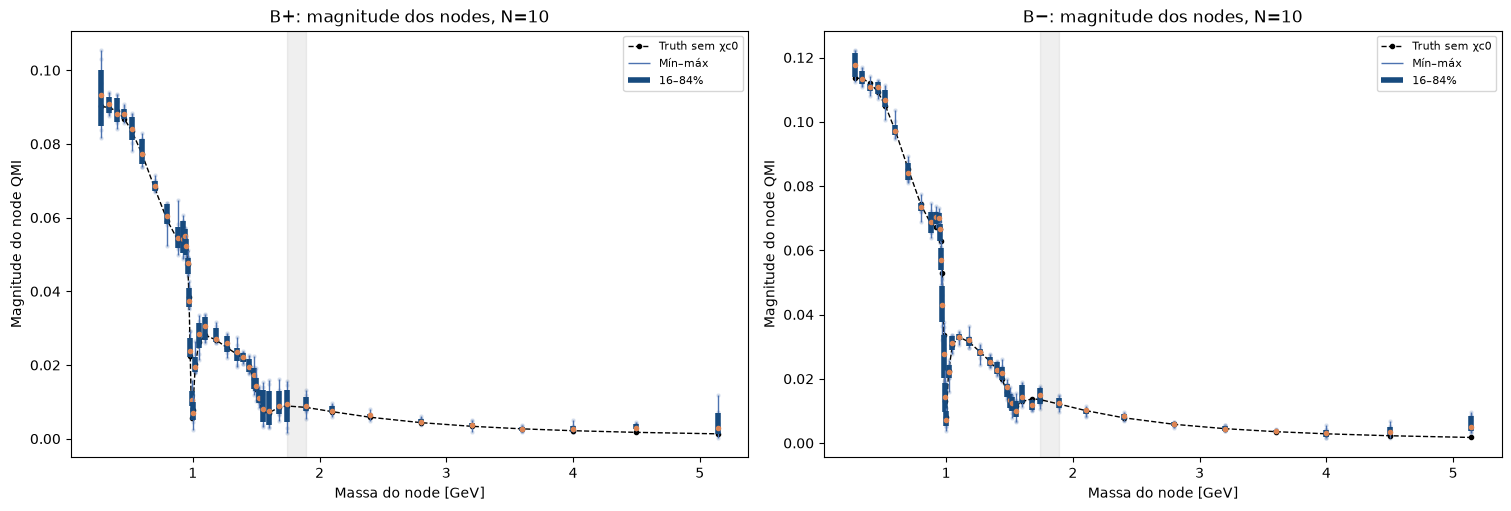

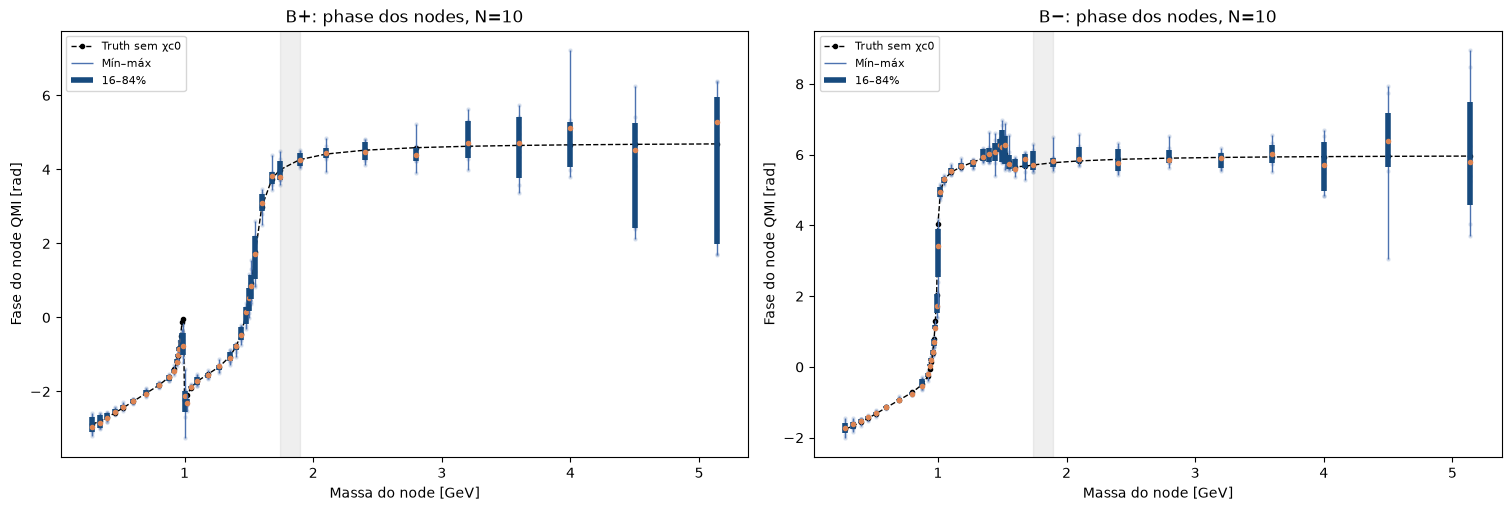

In [40]:
node_range_rows = []
for field, ylabel in (("magnitude", "Magnitude do node QMI"), ("phase", "Fase do node QMI [rad]")):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    for ax, charge in zip(axes, (+1, -1)):
        truths = TRUTH_QMI_NODES[charge]
        truth_values = abs(truths) if field == "magnitude" else np.unwrap(np.angle(truths))
        ax.plot(QMI_KNOTS, truth_values, "ko--", ms=3, lw=1, label="Truth sem χc0")
        for i, mass in enumerate(QMI_KNOTS):
            values = node_results.loc[(node_results.charge == charge) & (node_results.node == i), field].to_numpy(float)
            values = values[np.isfinite(values)]
            if not len(values):
                continue
            lo, p16, median, p84, hi = np.percentile(values, [0, 16, 50, 84, 100])
            ax.scatter(np.full(len(values), mass), values, s=5, color="#4C72B0", alpha=.15)
            ax.vlines(mass, lo, hi, color="#4C72B0", lw=1, label="Mín–máx" if i == 0 else None)
            ax.vlines(mass, p16, p84, color="#174A7E", lw=4, label="16–84%" if i == 0 else None)
            ax.plot(mass, median, "o", color="#DD8452", ms=3)
            node_range_rows.append(dict(charge=charge, node=i, mass=mass, observable=field,
                                        n=len(values), minimum=lo, p16=p16, median=median, p84=p84, maximum=hi))
        ax.set_title(f"B{'+' if charge == 1 else '−'}: {field} dos nodes, N={len(toy_results_valid)}")
        ax.set_xlabel("Massa do node [GeV]")
        ax.set_ylabel(ylabel)
        ax.axvspan(D0_VETO_MIN_GEV, D0_VETO_MAX_GEV, color="grey", alpha=.12)
        ax.legend(fontsize=8)
    finish_figure(fig, f"node_ranges_{field}")
pd.DataFrame(node_range_rows).to_csv(OUTPUT_DIR / "node_ranges.csv", index=False)


## Pulls de magnitude e fase: um histograma por node e carga
Páginas com seis nodes, preservando todos os nodes e ambas as cargas. A referência tracejada é zero;
a curva pontilhada é N(0,1). O resumo salva n, média, desvio amostral e ajuste gaussiano, quando possível.
Os toys sem covariância utilizável ou fase definida não entram no histograma, e n aparece em cada painel.
Pulls enviesados podem refletir erro de interpolação, convenções geradoras ou problemas do ajuste;
compare com o diagnóstico de representação antes de atribuir a causa ao minimizador.


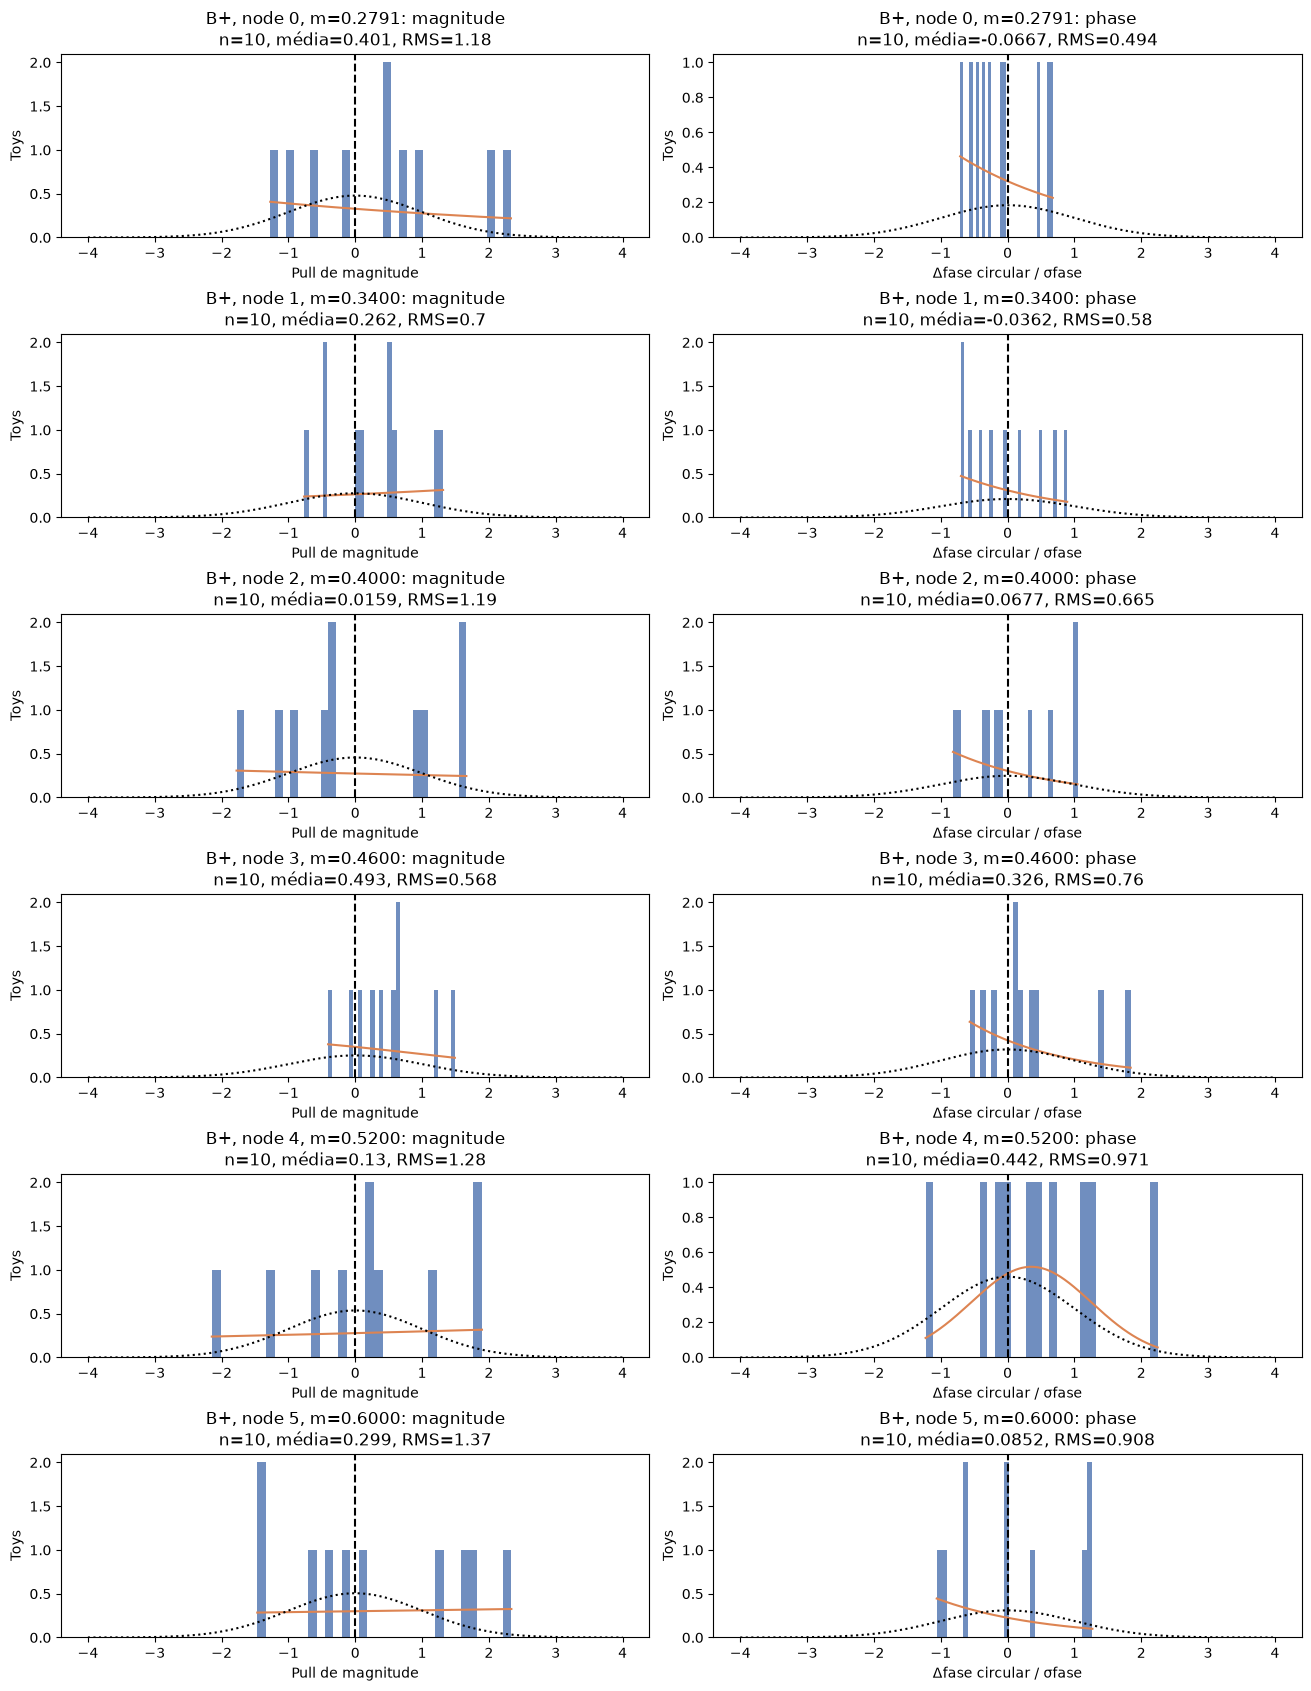

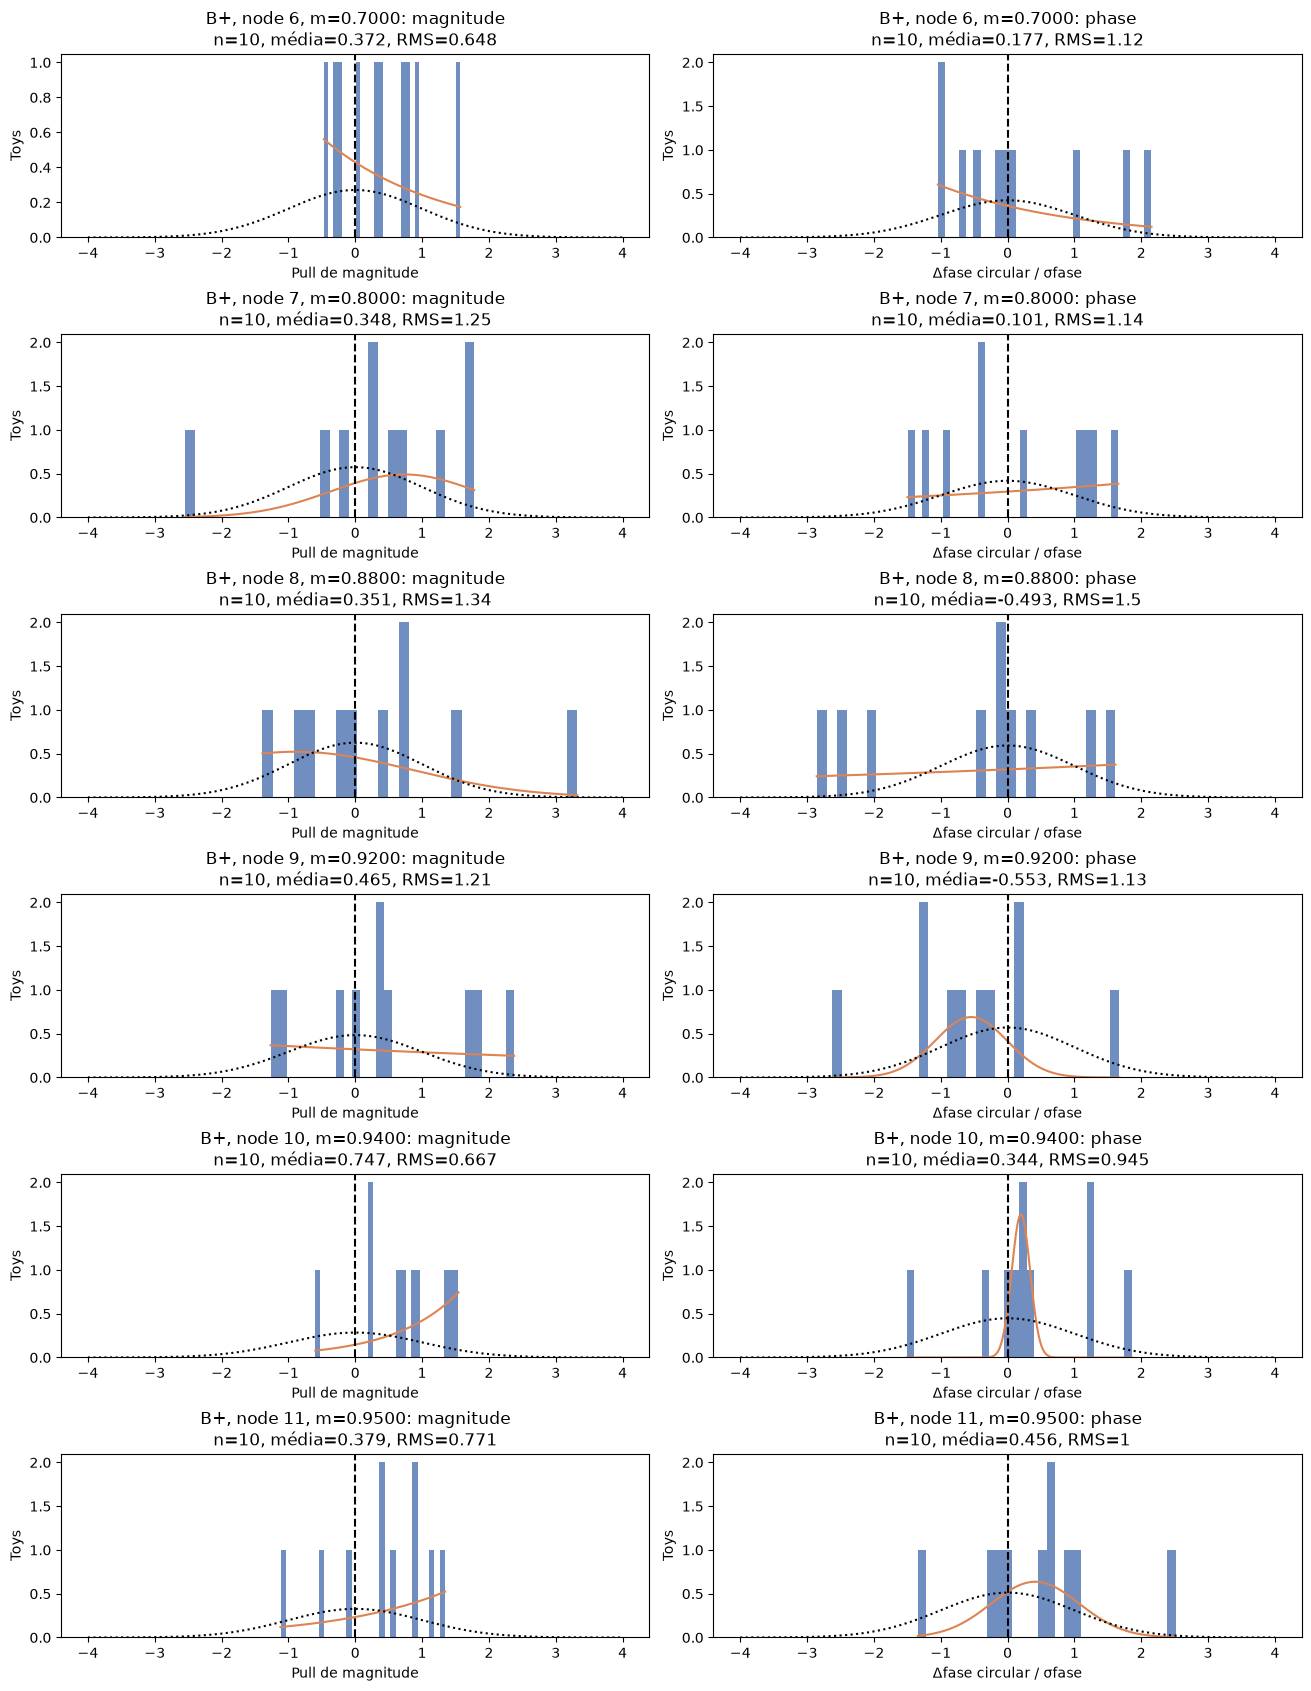

/home/juan-leite/Work/DalitzPlotFitter/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


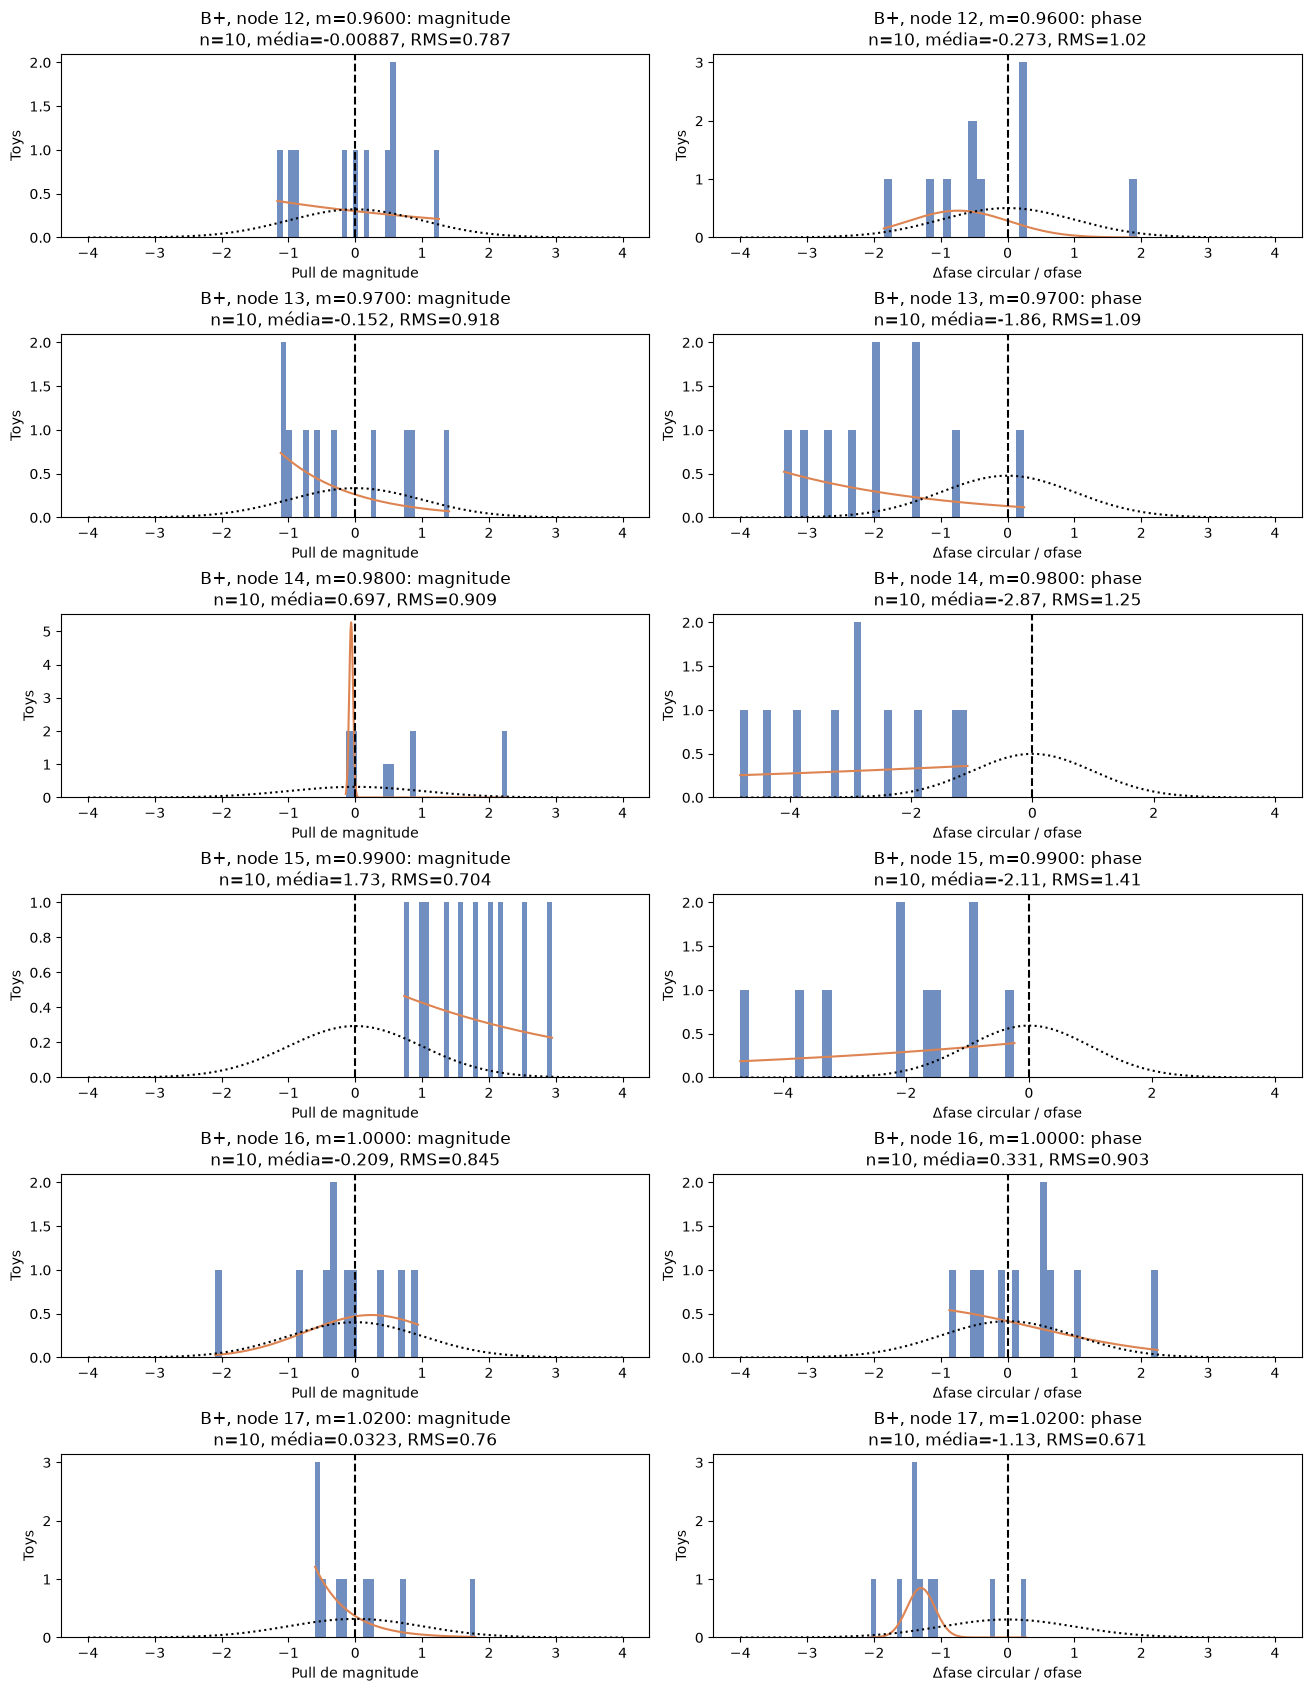

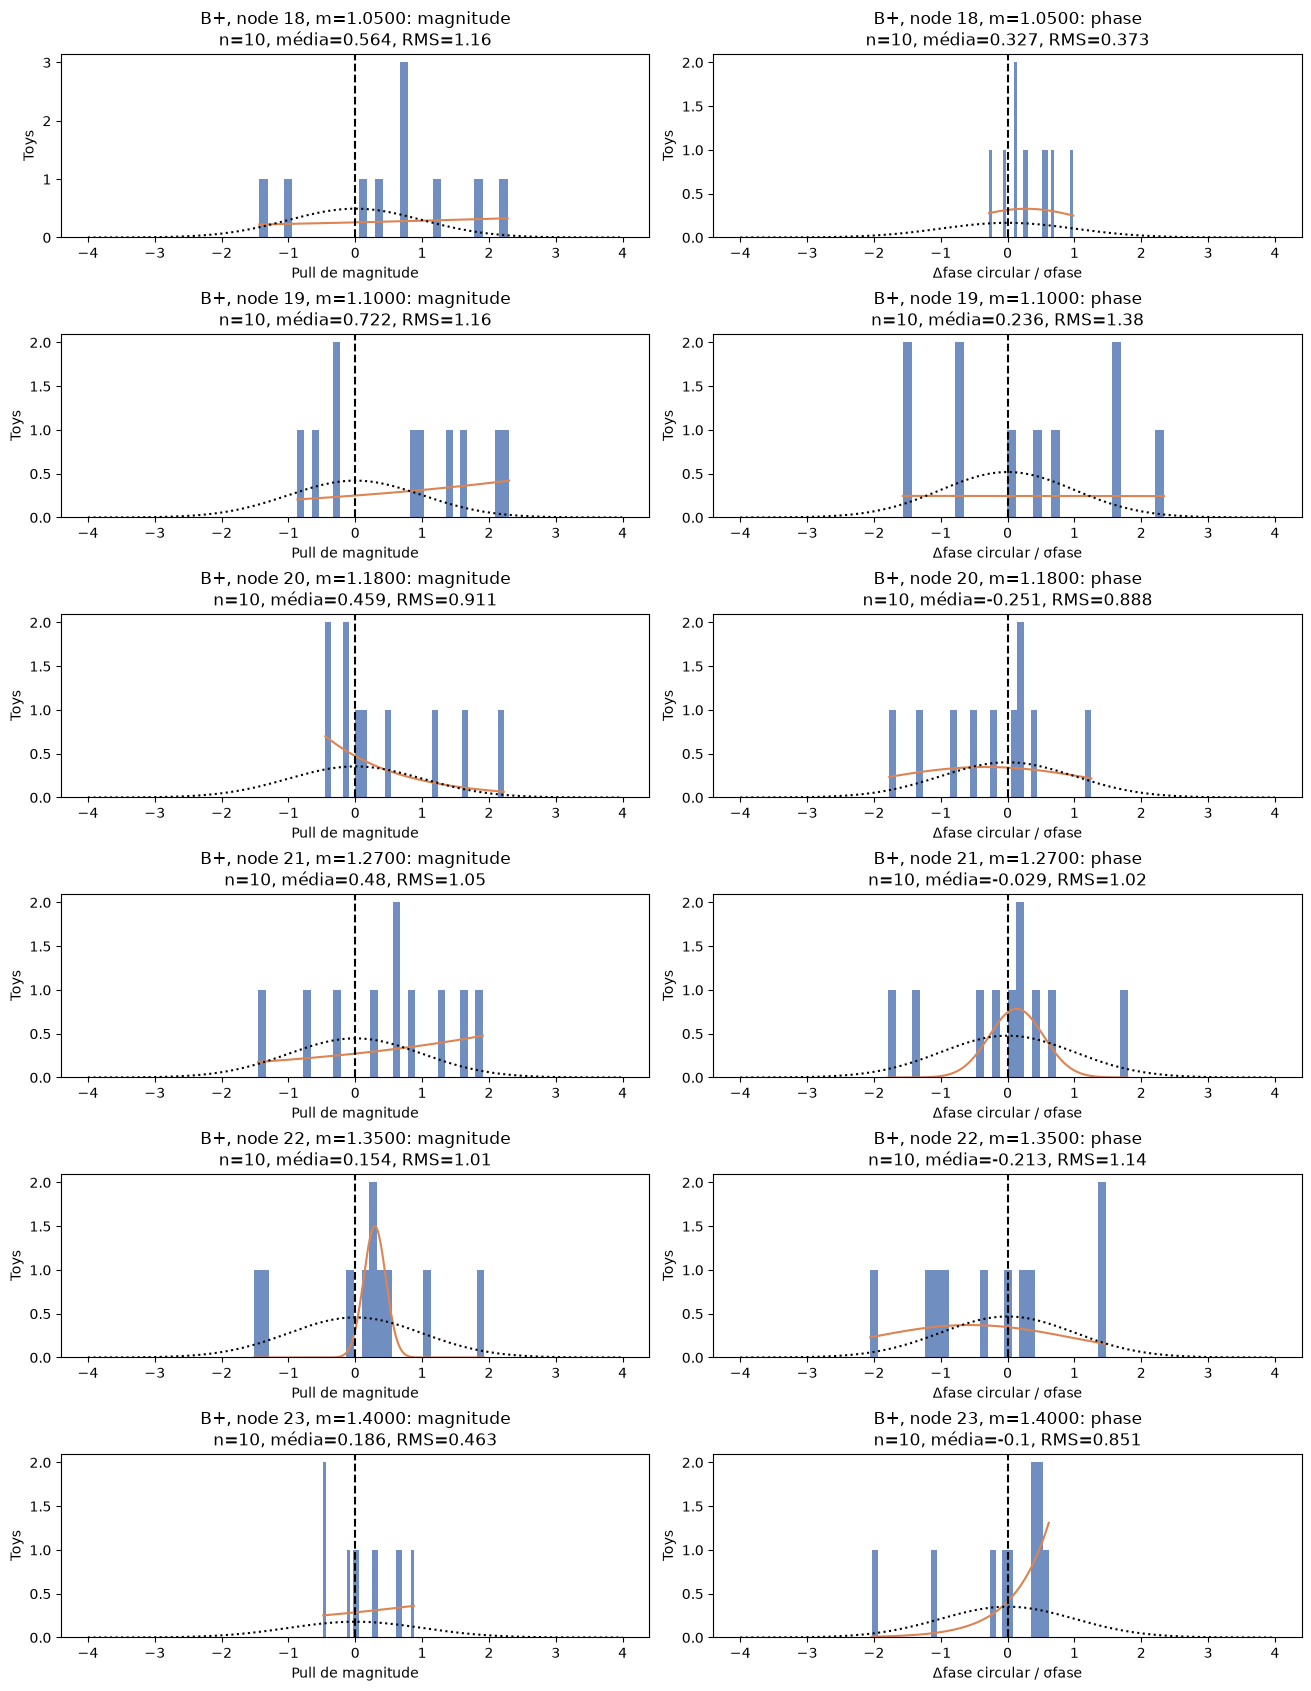

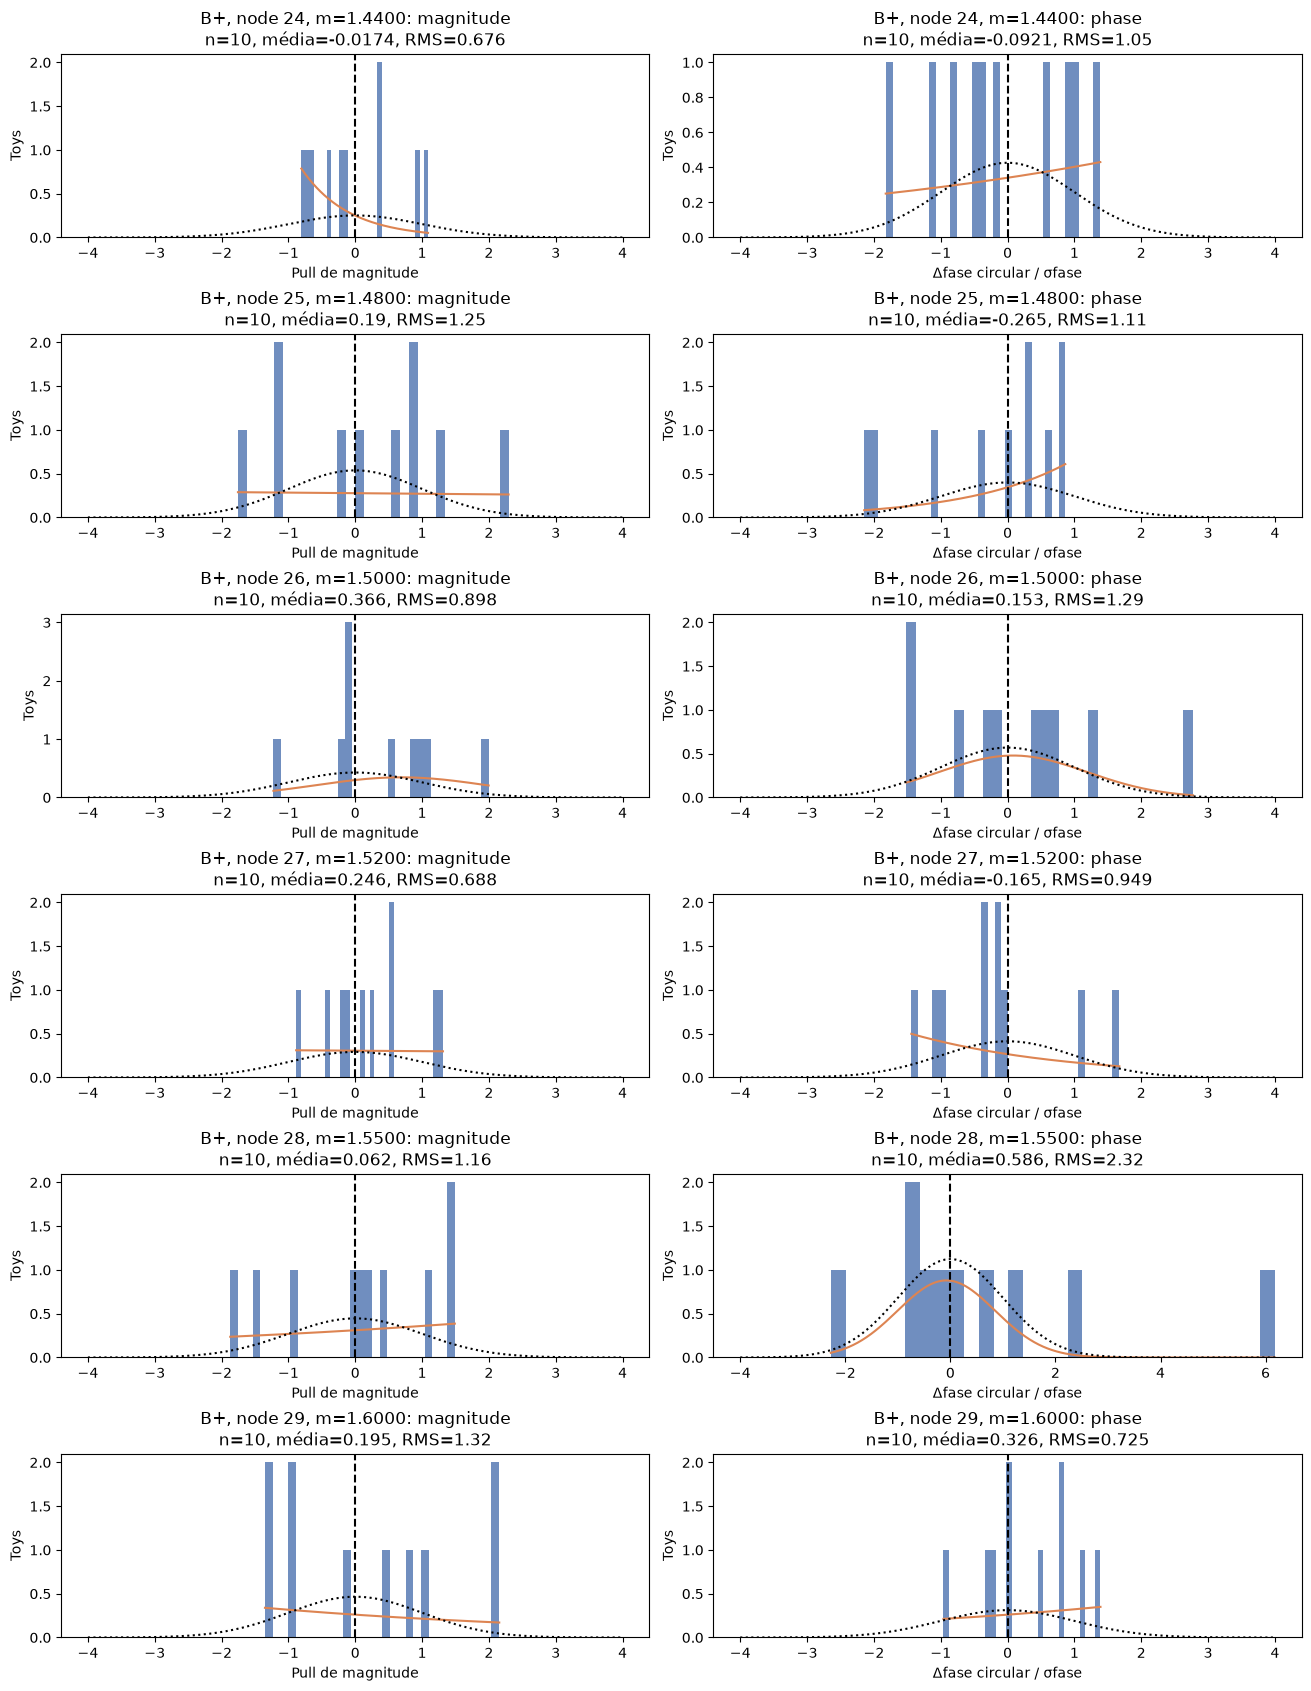

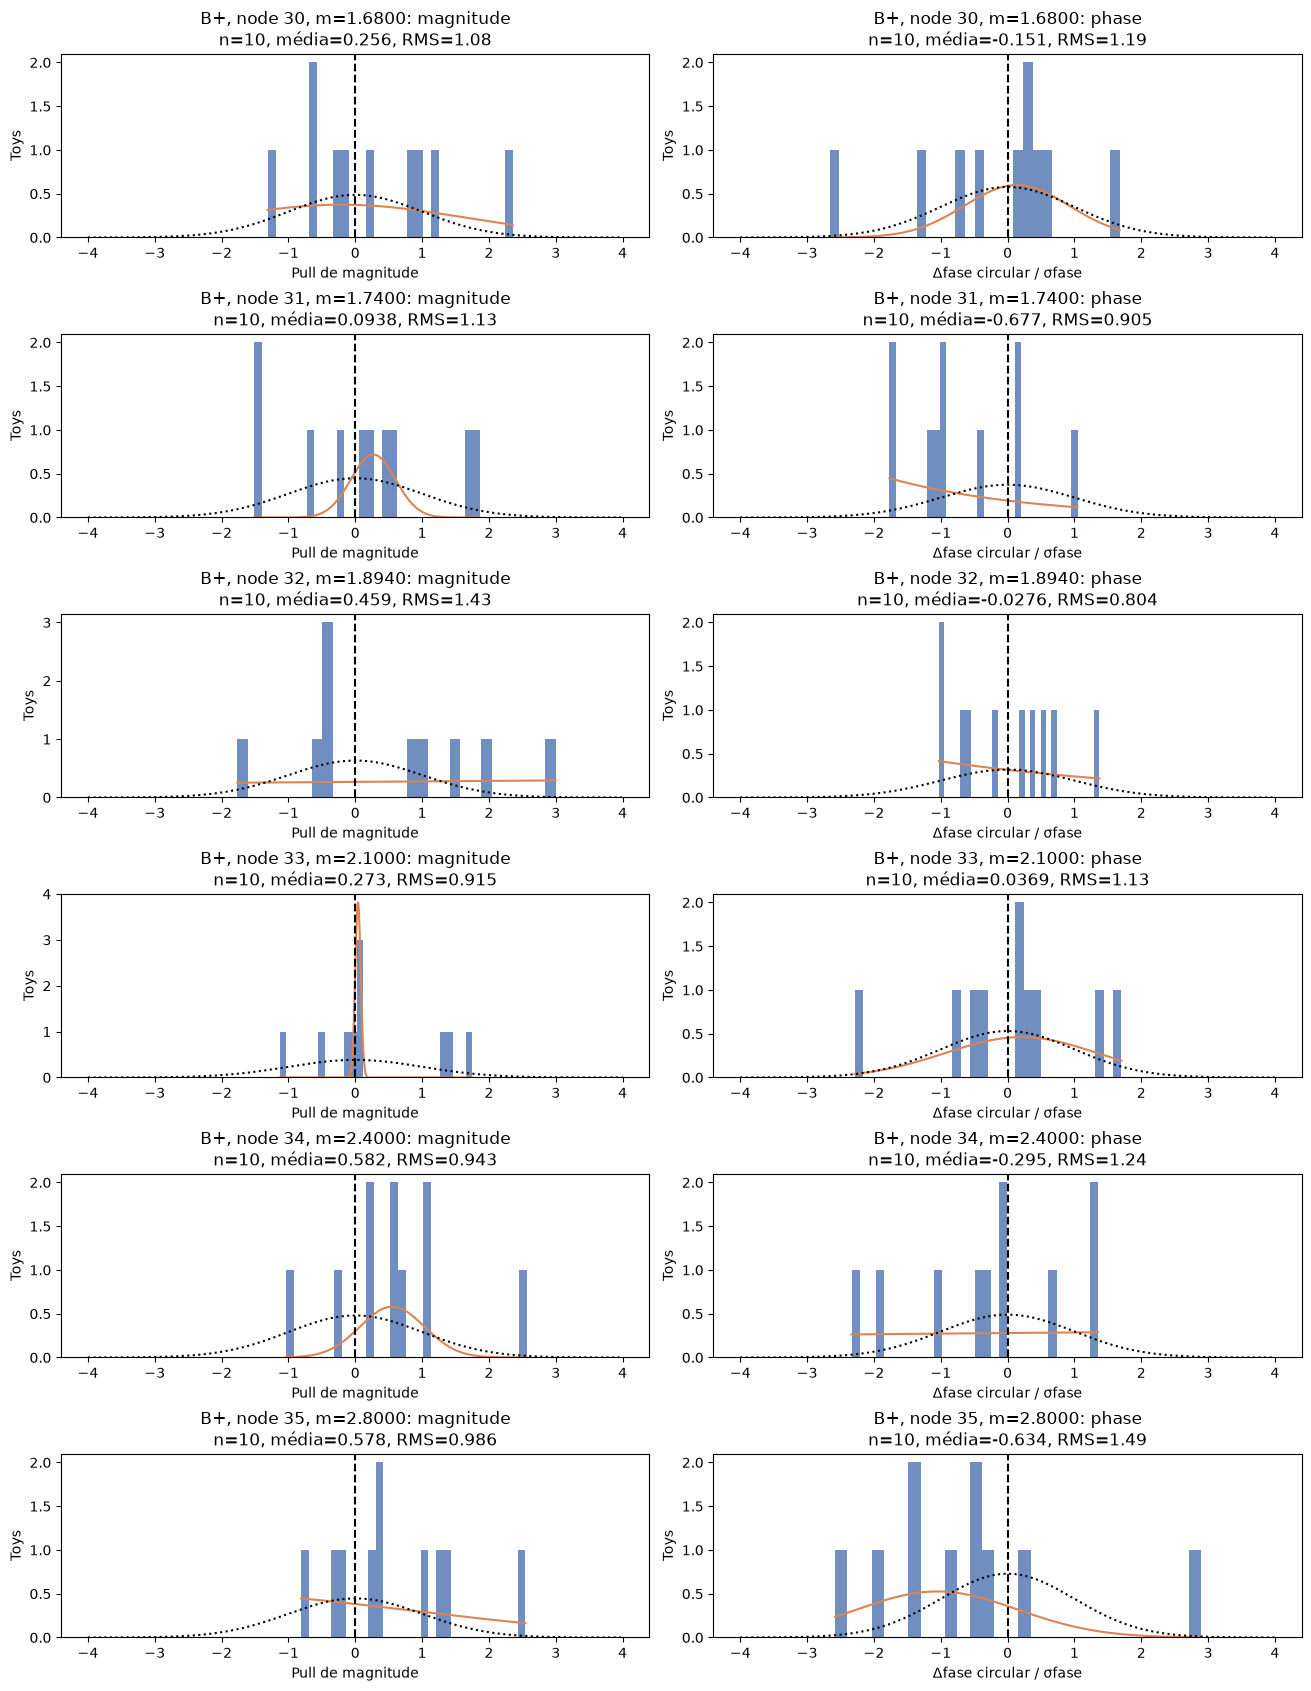

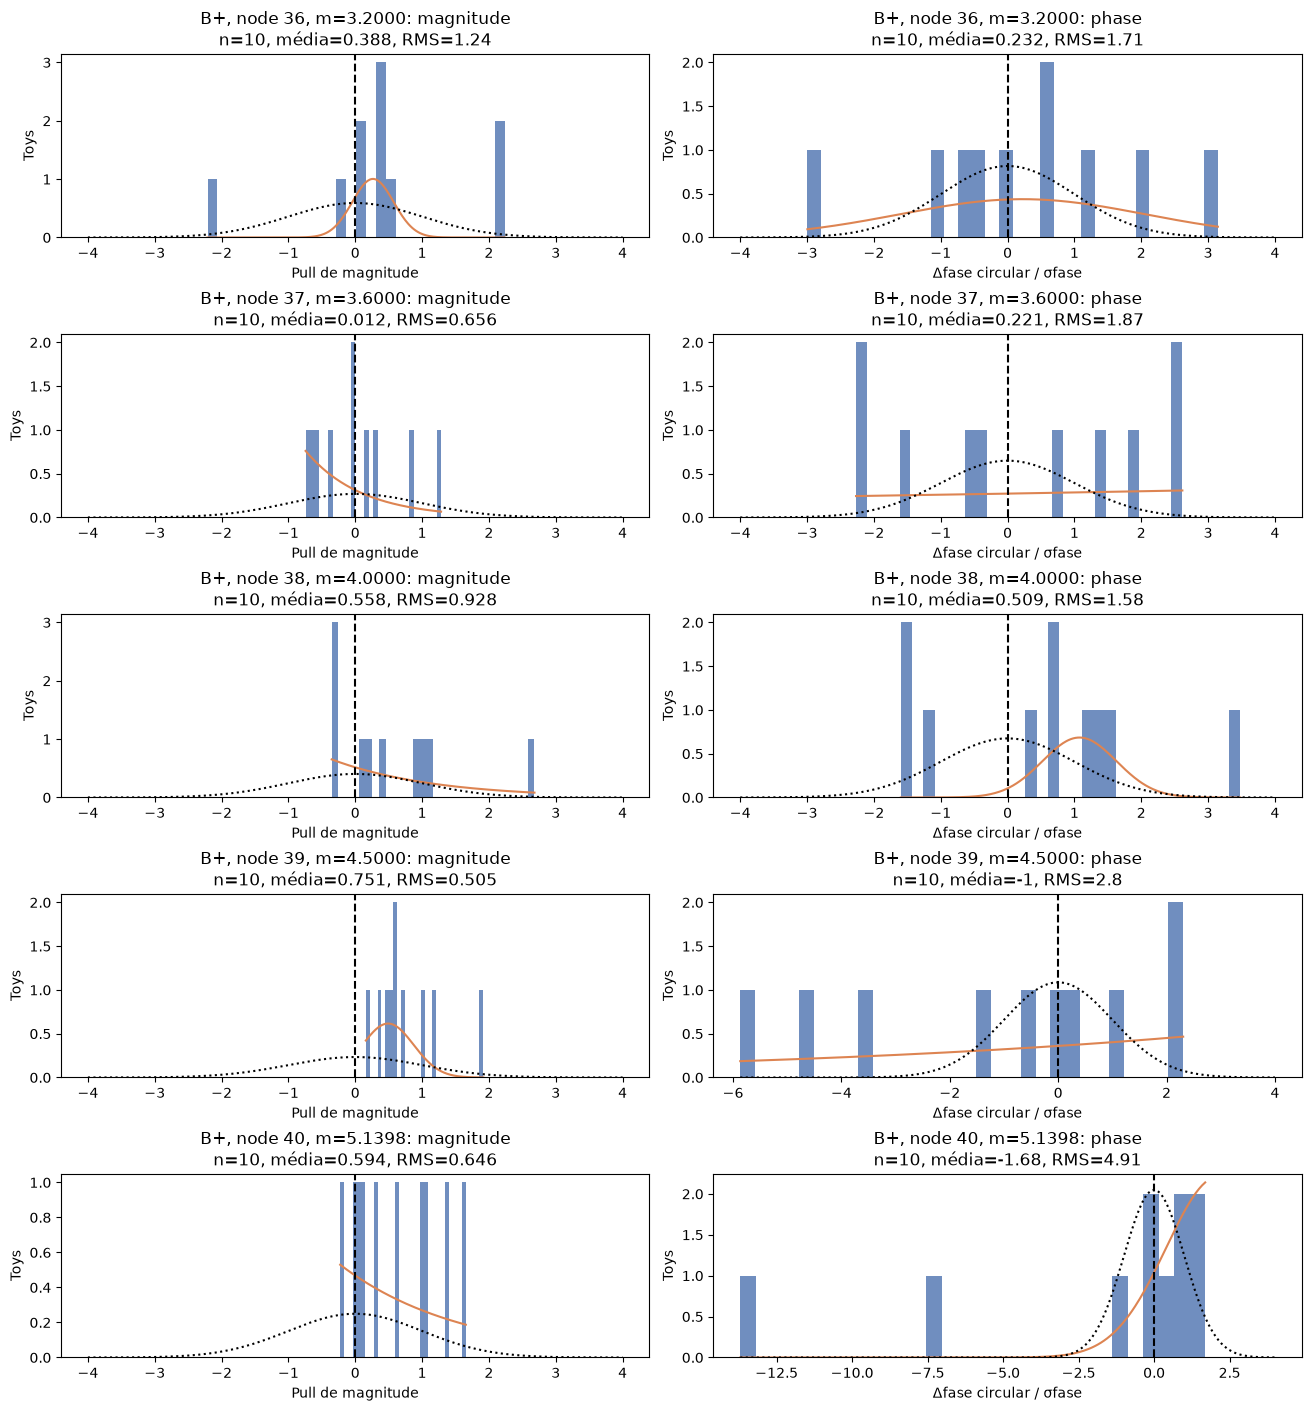

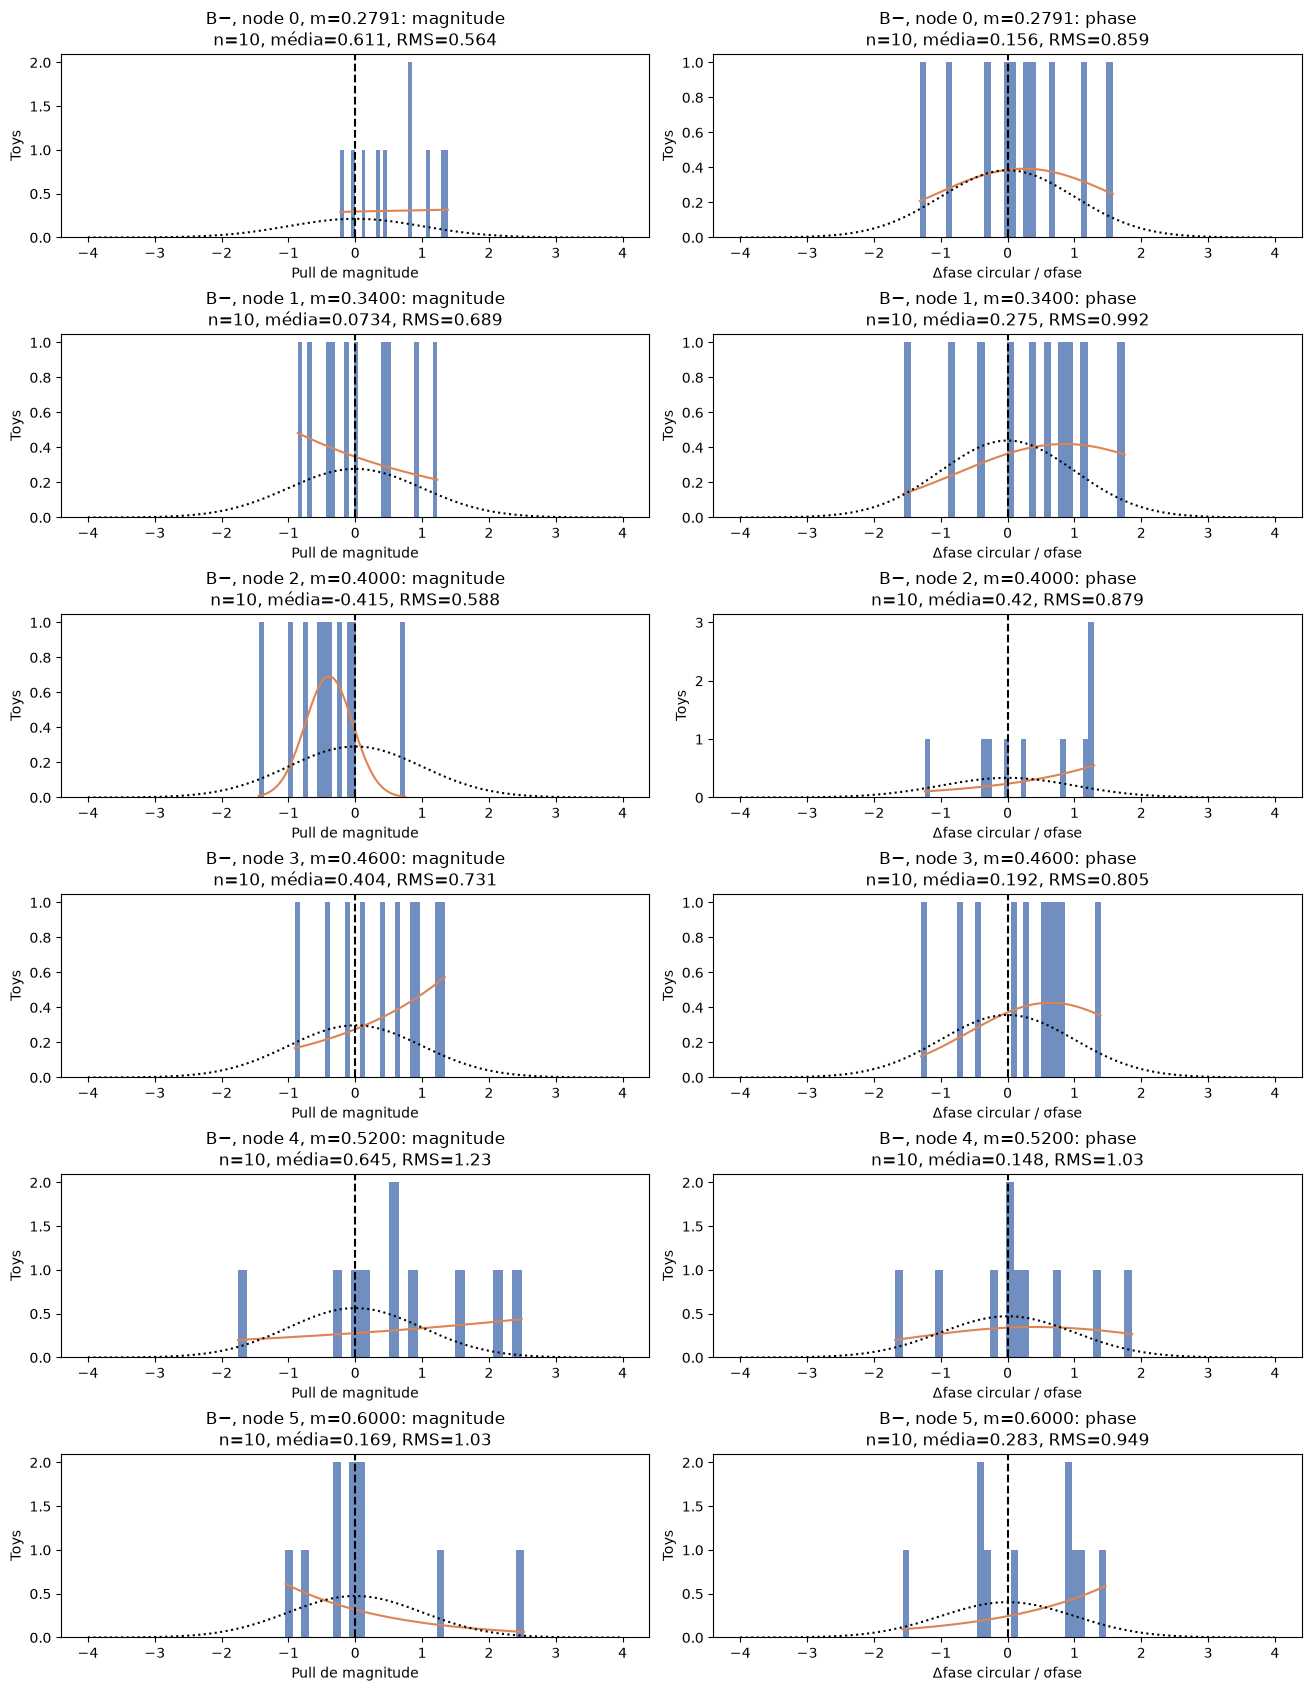

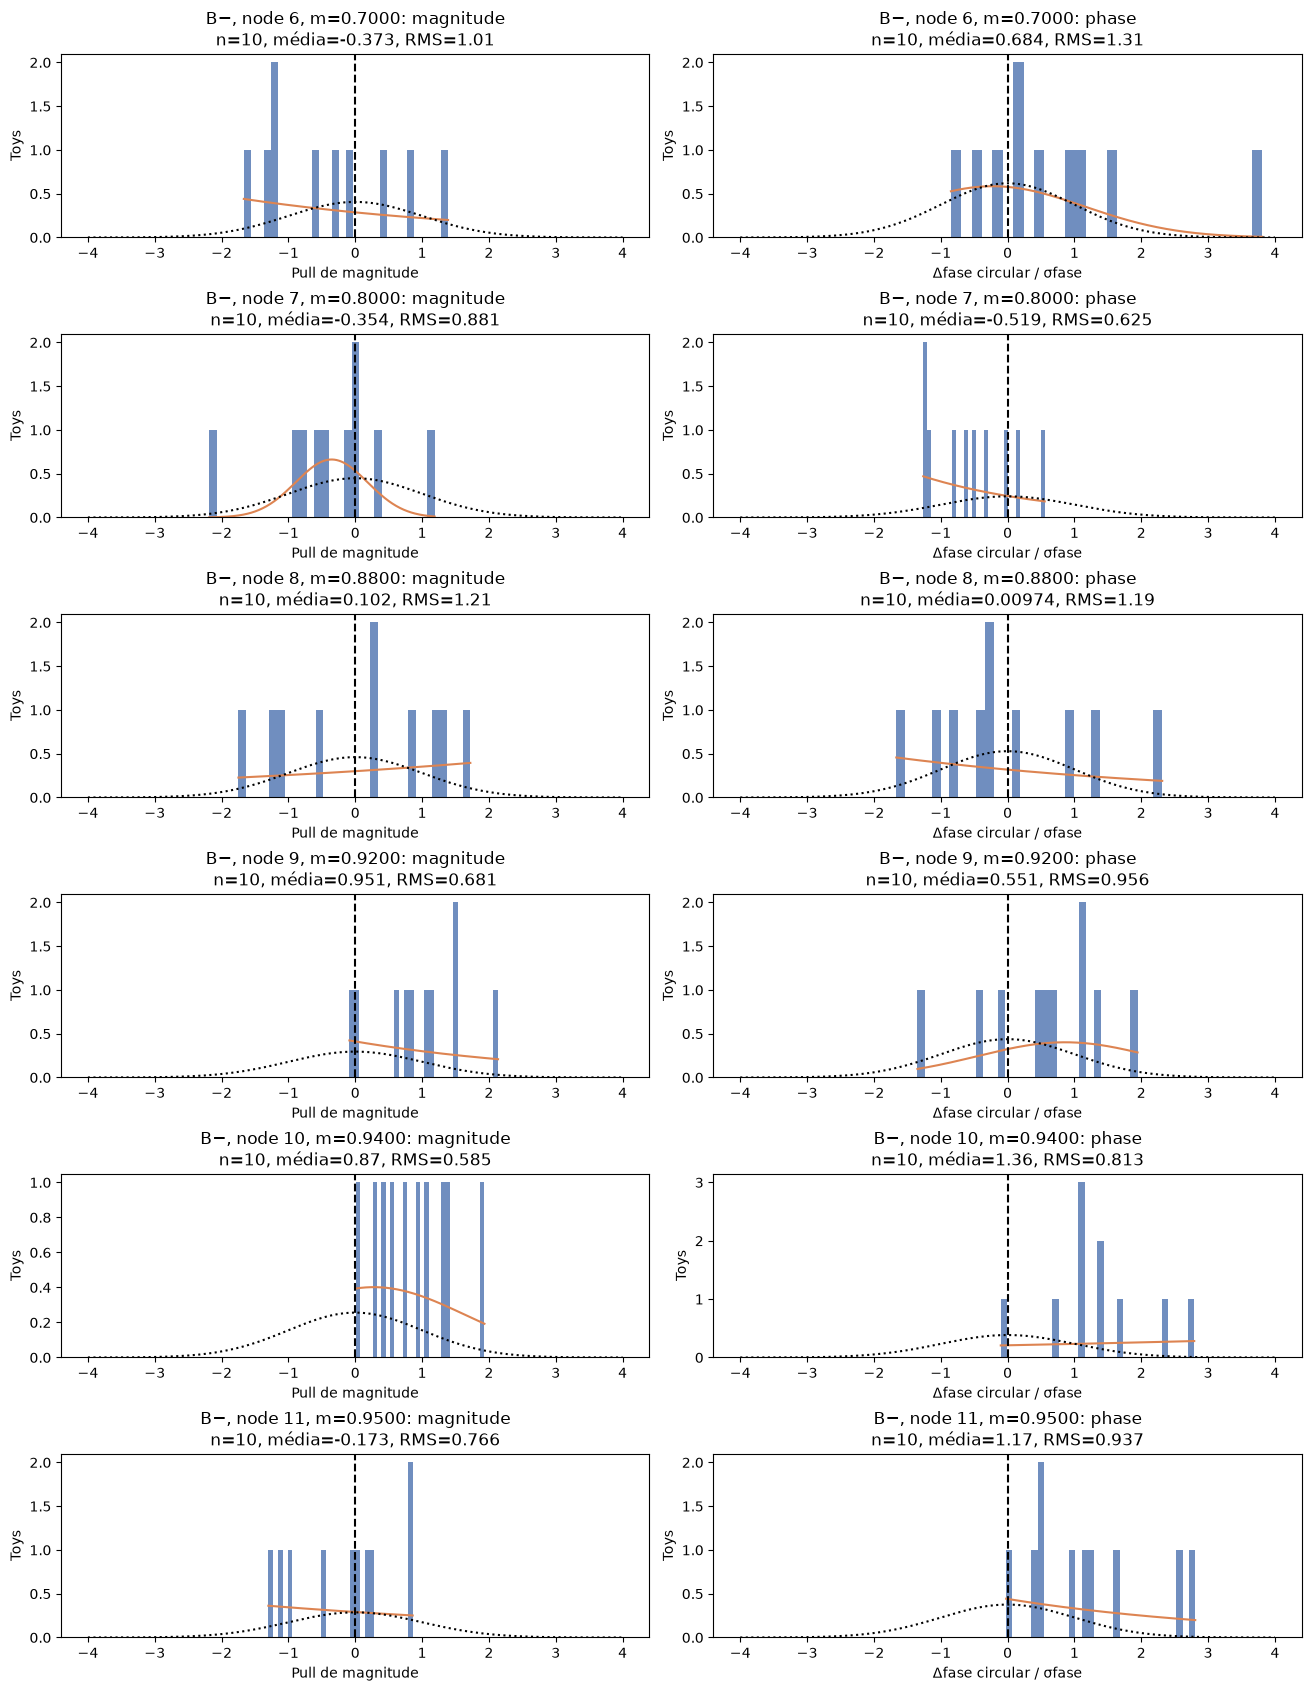

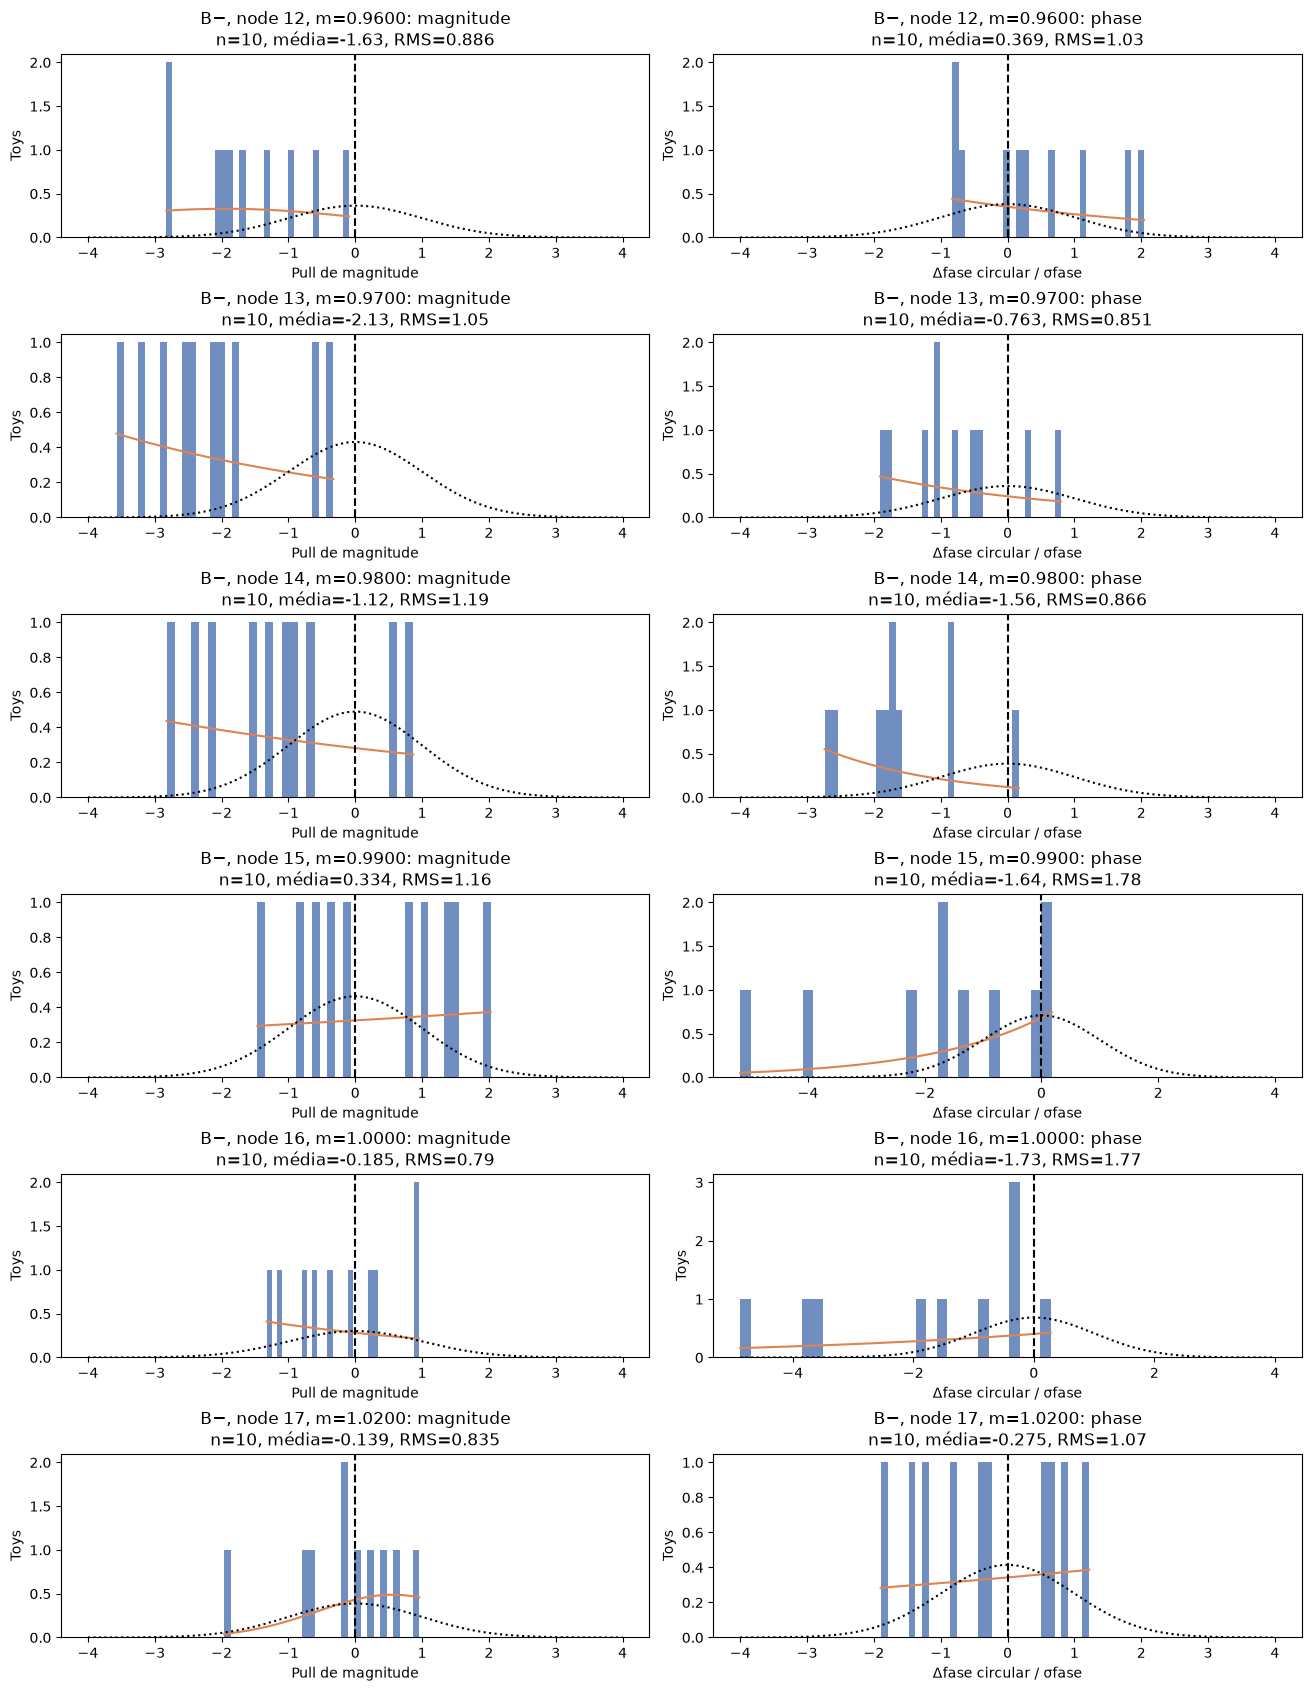

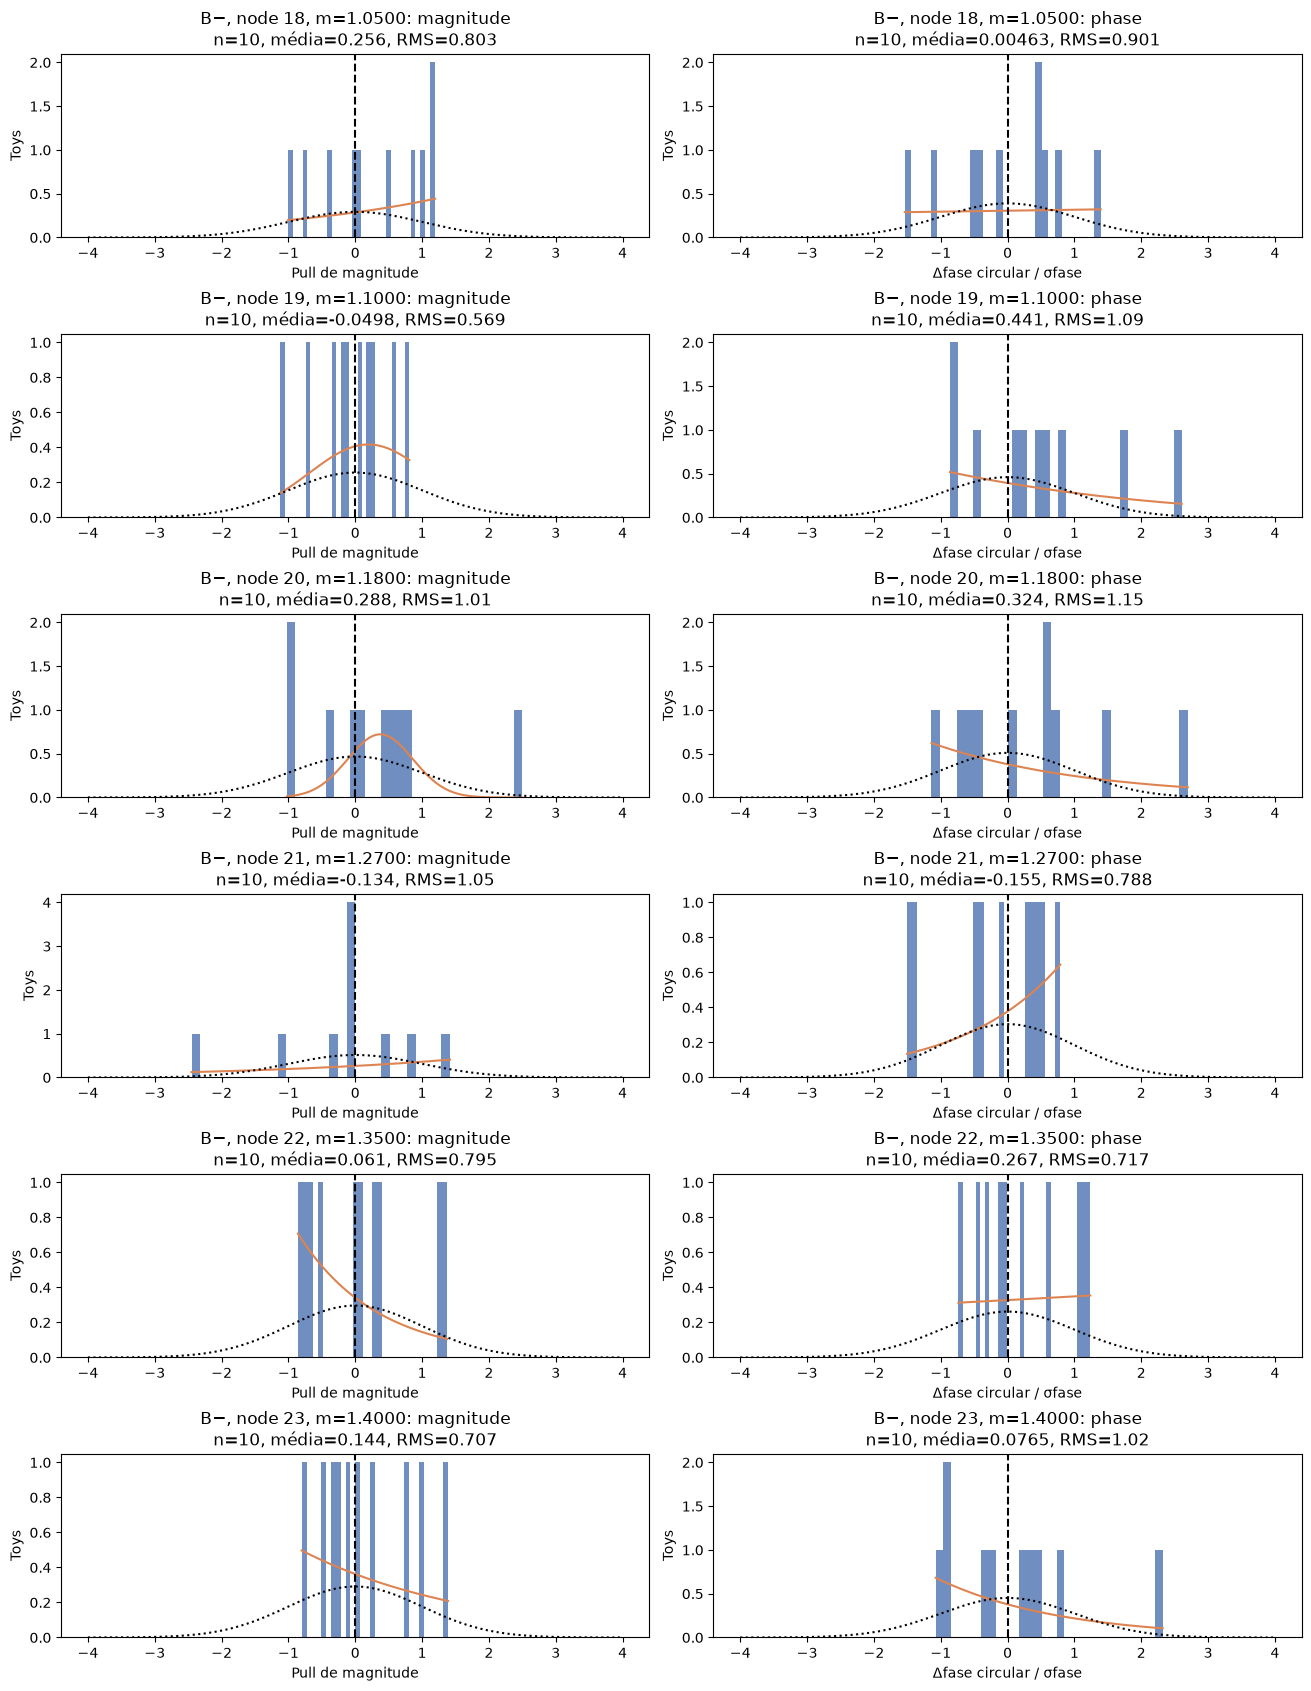

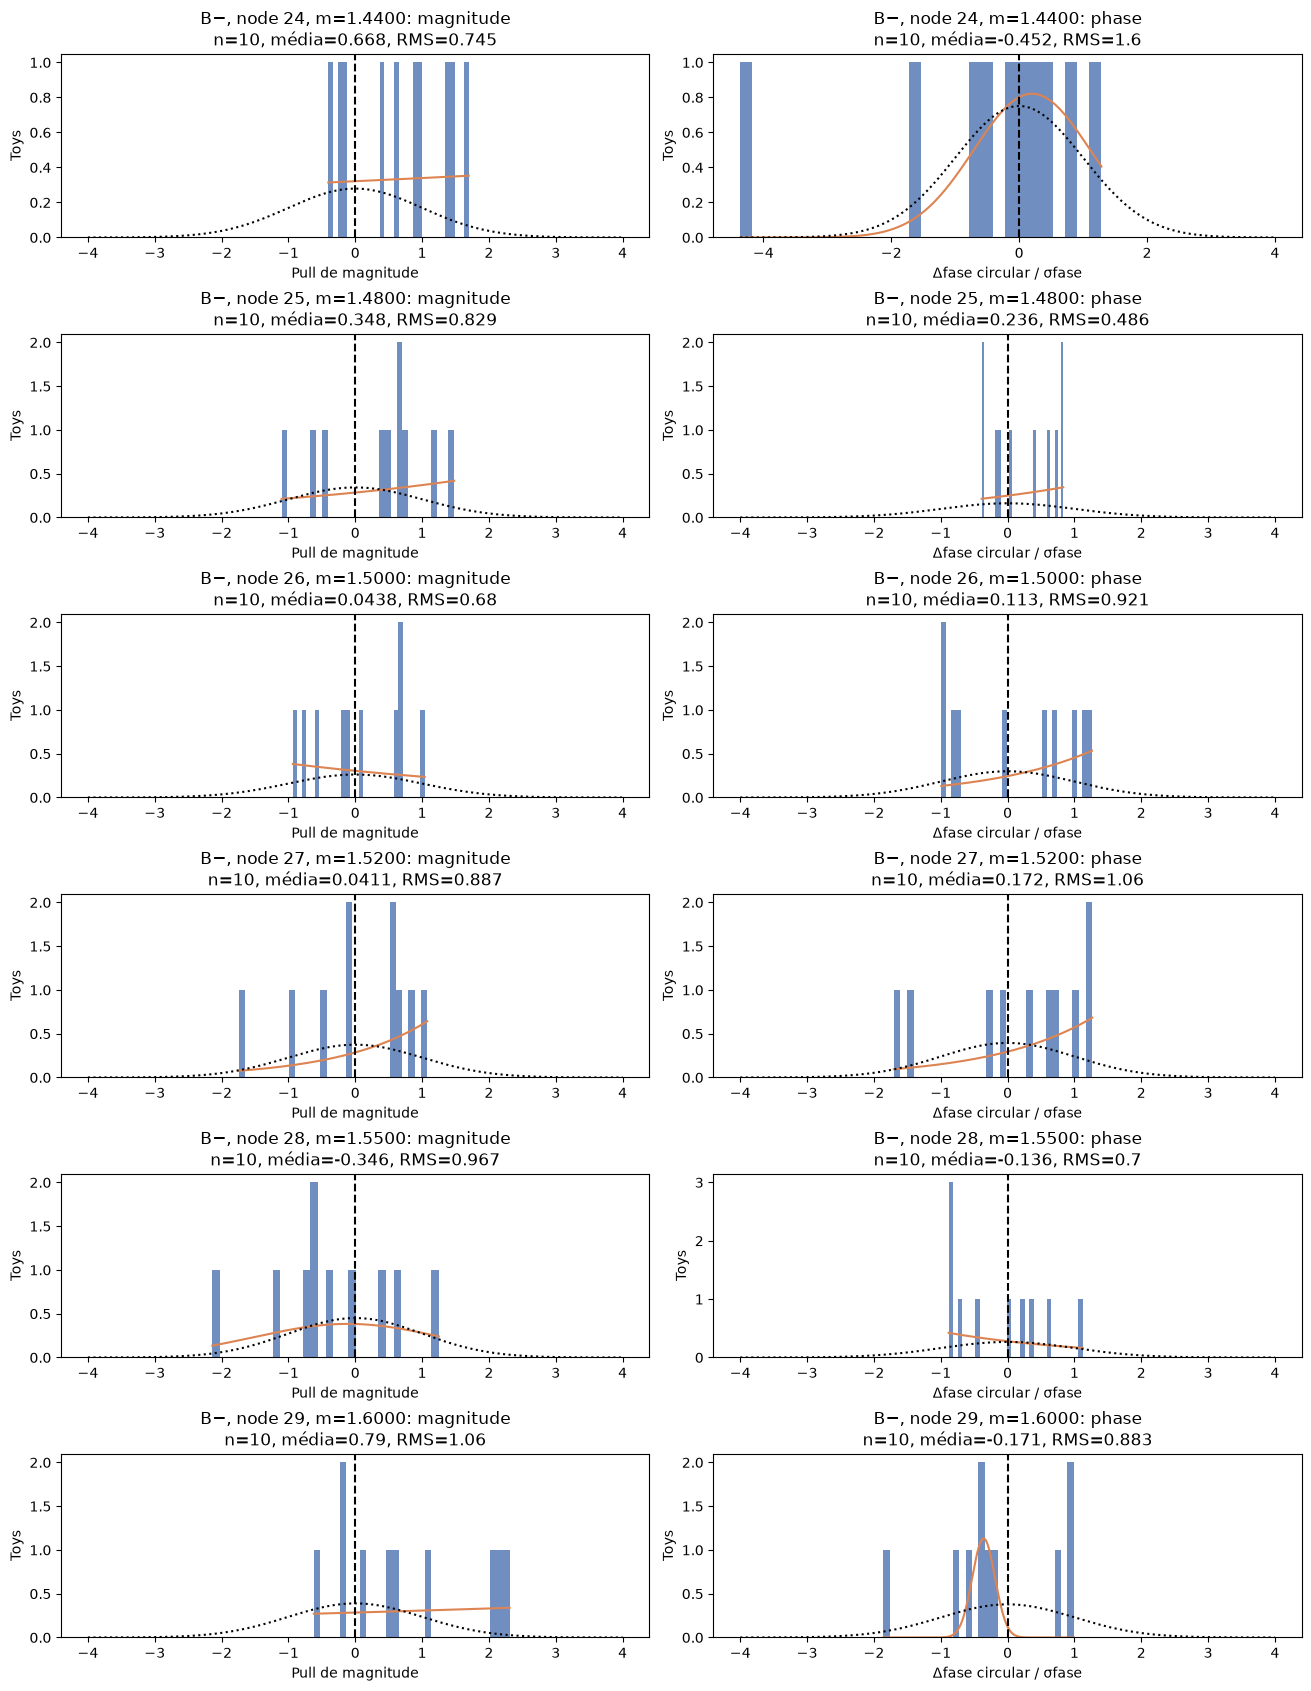

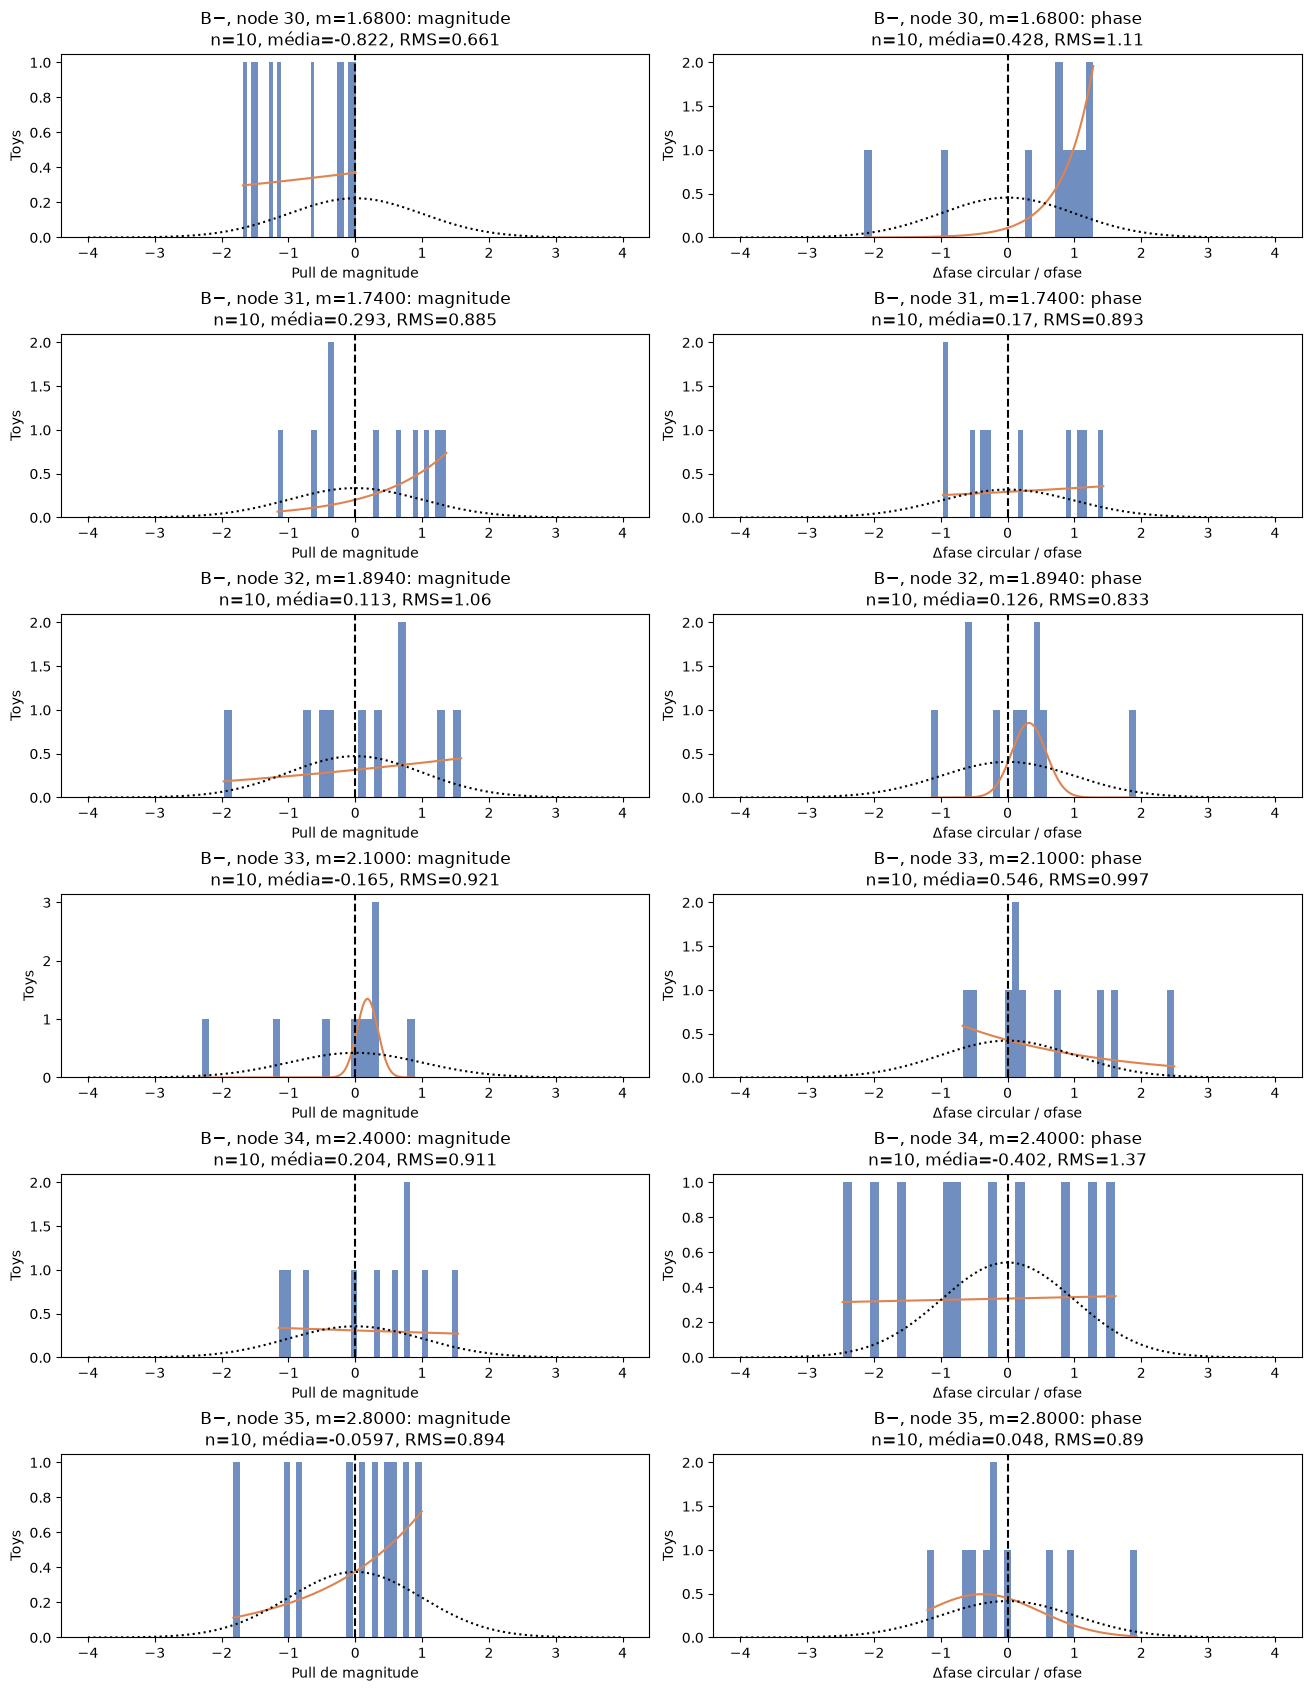

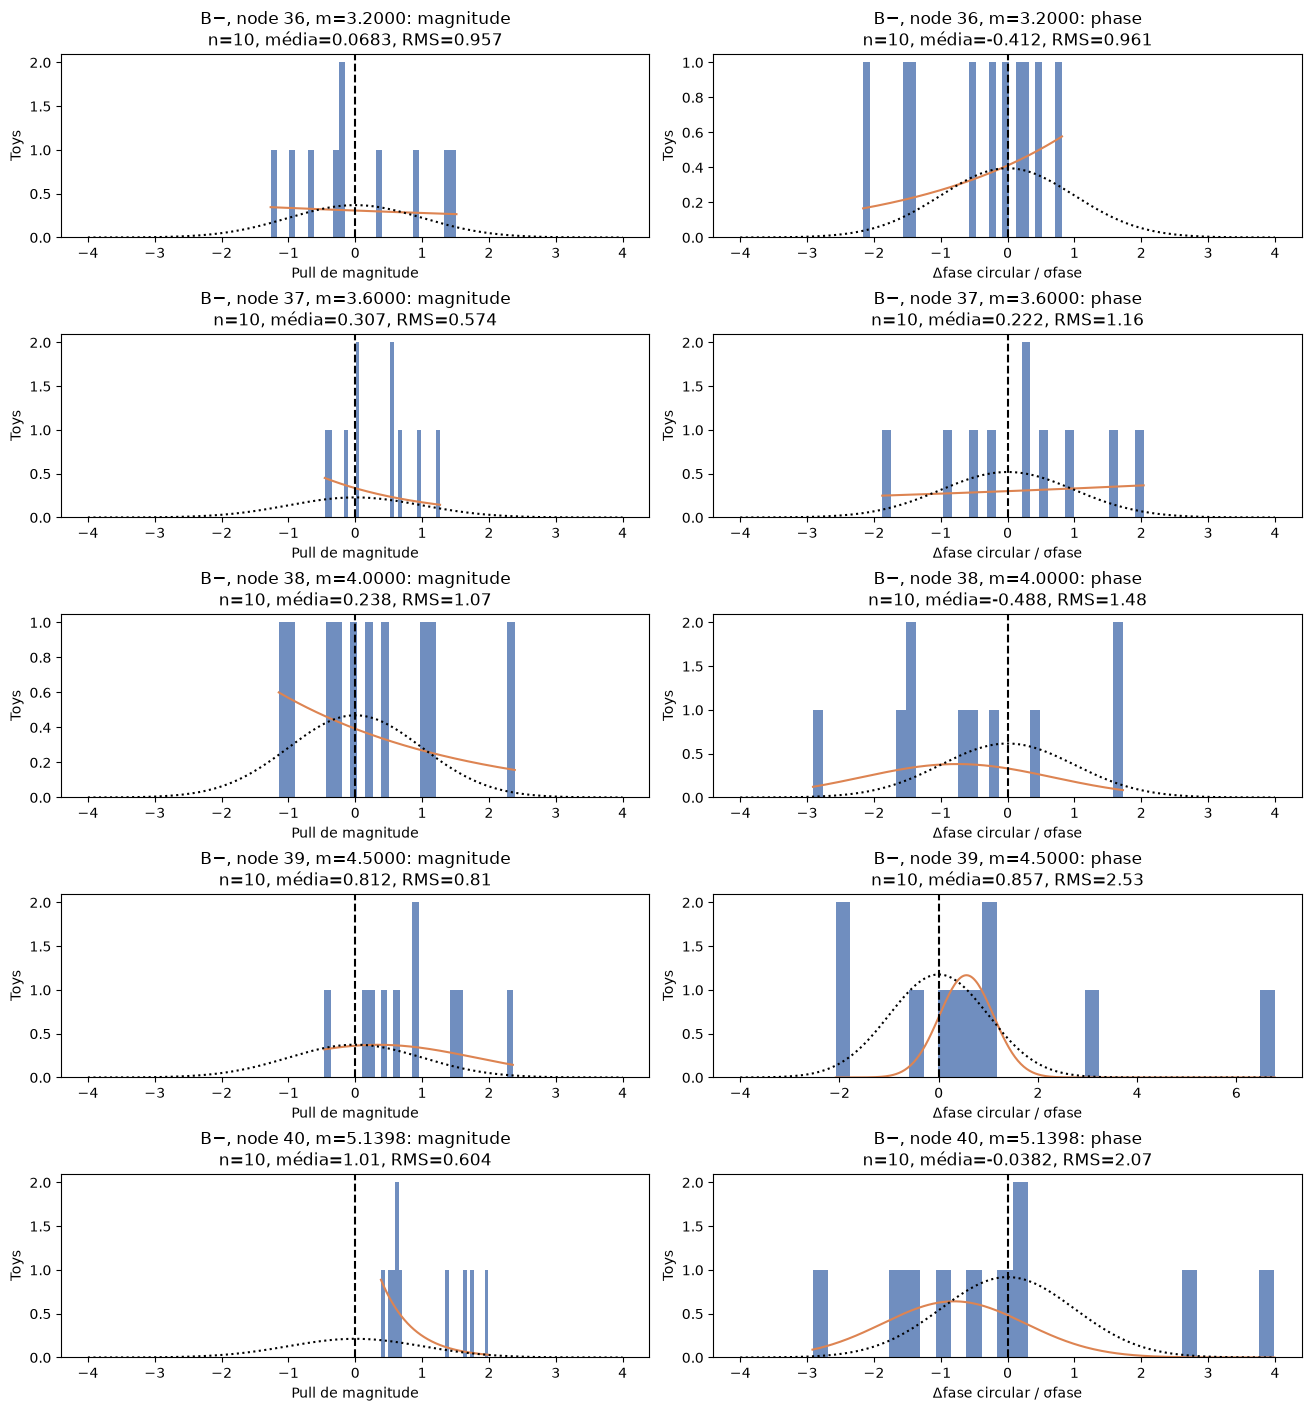

,charge,node,mass,observable,n,mean,std,gaussian_mu,gaussian_sigma,gaussian_mu_error,gaussian_sigma_error
0,1,0,0.279141,magnitude,10,0.400729,1.176937,-385.751956,47.282265,1.321944e+03,161.962726
1,1,0,0.279141,phase,10,-0.066730,0.494456,-173.241117,18.315834,4.756934e+02,50.343015
2,1,1,0.340000,magnitude,10,0.262325,0.700405,212.084837,40.266345,1.439108e+06,136818.063125
3,1,1,0.340000,phase,10,-0.036176,0.580122,-199.535593,18.075651,4.650901e+02,42.157795
4,1,2,0.400000,magnitude,10,0.015892,1.193292,-317.217435,69.529546,2.429975e+06,266420.668325
...,...,...,...,...,...,...,...,...,...,...,...
159,-1,38,4.000000,phase,10,-0.487971,1.477268,-0.755991,1.427958,1.446378e+00,1.791778
160,-1,39,4.500000,magnitude,10,0.811595,0.810252,0.343144,1.463571,2.903056e+00,3.651283
161,-1,39,4.500000,phase,10,0.857231,2.529178,0.559565,0.545180,3.879549e-01,0.366296
162,-1,40,5.139840,magnitude,10,1.012713,0.604461,-117.187165,7.547103,1.289865e+02,8.262822


In [41]:
node_pull_summary = []
for charge in (+1, -1):
    tag = "plus" if charge == 1 else "minus"
    for start in range(0, len(QMI_KNOTS), 6):
        indices = list(range(start, min(start+6, len(QMI_KNOTS))))
        fig, axes = plt.subplots(len(indices), 2, figsize=(13, 2.8*len(indices)),
                                  squeeze=False, constrained_layout=True)
        for row_index, node in enumerate(indices):
            selected = node_results[(node_results.charge == charge) & (node_results.node == node)]
            for column, field in enumerate(("magnitude", "phase")):
                title = f"B{'+' if charge == 1 else '−'}, node {node}, m={QMI_KNOTS[node]:.4f}: {field}"
                stats = plot_histogram(axes[row_index, column], selected[f"{field}_pull"], title, 0, True)
                axes[row_index, column].set_xlabel("Pull de magnitude" if field == "magnitude" else "Δfase circular / σfase")
                node_pull_summary.append(dict(charge=charge, node=node, mass=QMI_KNOTS[node], observable=field, **stats))
        finish_figure(fig, f"node_pulls_{tag}_{start//6:02d}")
node_pull_summary = pd.DataFrame(node_pull_summary)
node_pull_summary.to_csv(OUTPUT_DIR / "node_pull_summary.csv", index=False)
display(node_pull_summary)


## Argand: S-wave completa e QMI sem χc0
Mesma escala complexa dos gráficos anteriores; nenhuma rotação ou reescala posterior. O truth recebe marcadores nas massas dos nodes.


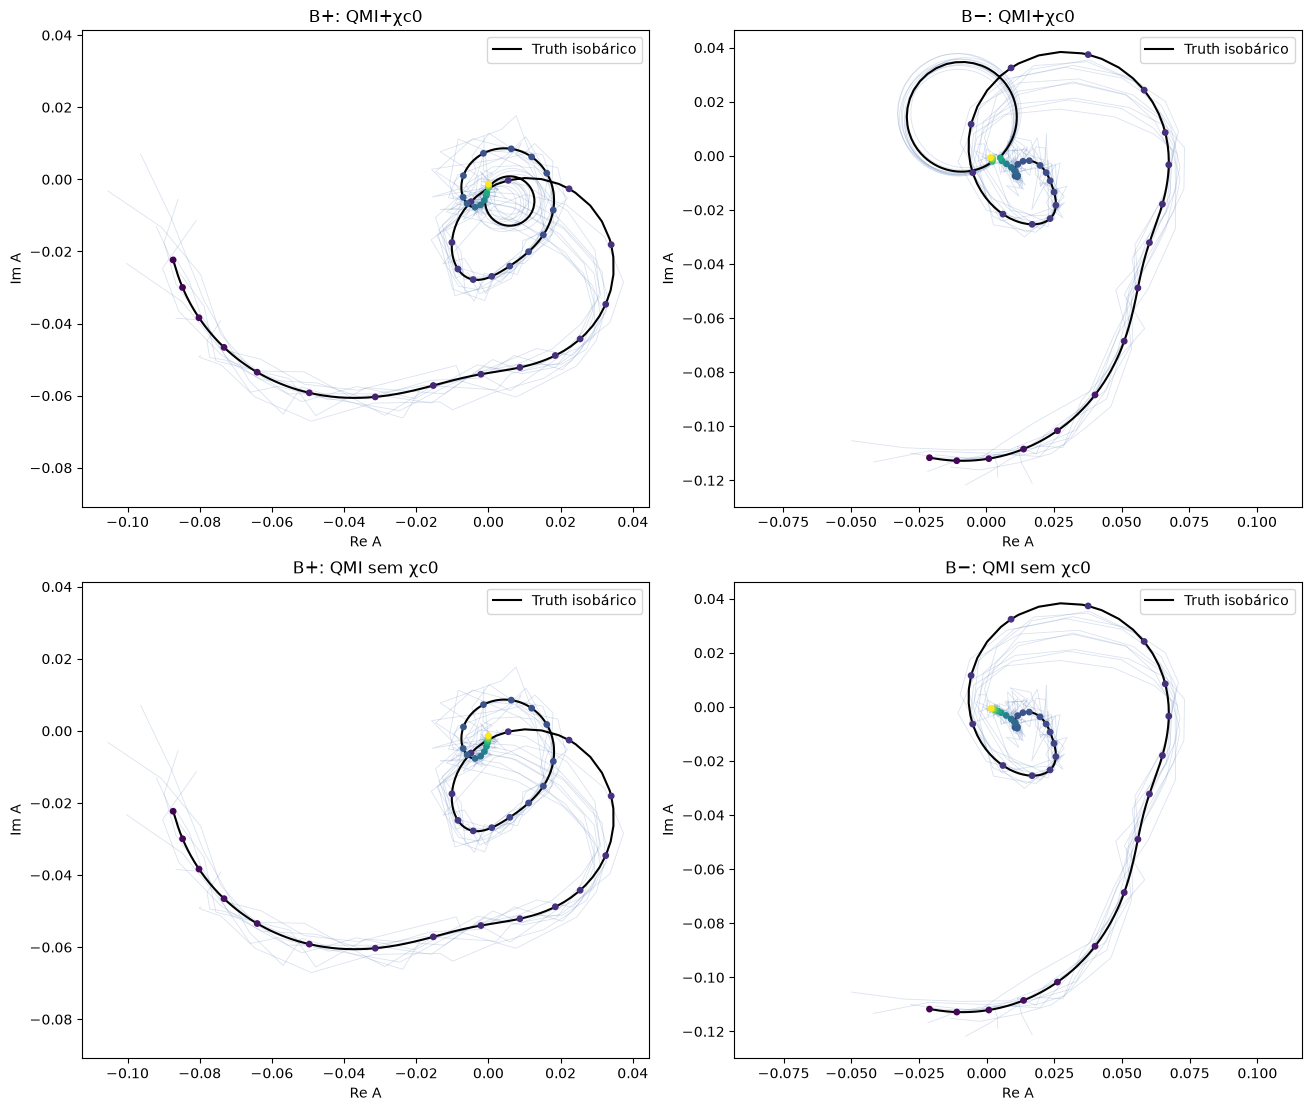

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)
for column, charge in enumerate((+1, -1)):
    for row_index, include_chi in enumerate((True, False)):
        ax = axes[row_index, column]
        names = ALL_S_NAMES if include_chi else REPLACED_S_NAMES
        truth = isobar_single_pair(charge, MASS_SCAN, names)
        curves = SWAVE_ENSEMBLES[charge].copy()
        if not include_chi:
            for i, (_, fit_row) in enumerate(toy_results_valid.iterrows()):
                curves[i] -= isobar_single_pair(charge, MASS_SCAN, ("chi_c0",), fit_row.to_dict())
        if len(curves):
            ax.plot(curves.real.T, curves.imag.T, color="#4C72B0", alpha=min(.2, 3/len(curves)), lw=.6)
        ax.plot(truth.real, truth.imag, "k-", lw=1.5, label="Truth isobárico")
        nodes = isobar_single_pair(charge, QMI_KNOTS, names)
        ax.scatter(nodes.real, nodes.imag, c=QMI_KNOTS, cmap="viridis", s=15, zorder=5)
        ax.set_title(f"B{'+' if charge == 1 else '−'}: {'QMI+χc0' if include_chi else 'QMI sem χc0'}")
        ax.set_xlabel("Re A")
        ax.set_ylabel("Im A")
        ax.set_aspect("equal", adjustable="datalim")
        ax.legend()
finish_figure(fig, "argand")


## Projeções do conjunto de toys: previsão, dispersão e resíduos

Esta seção usa os **fits já salvos**, sem ajustar novamente. Pode ser executada enquanto o estudo avança:
ela recarrega o CSV e seleciona os fits válidos de `TOY_INDICES`, independentemente da qualidade de HESSE.
As três projeções são $m_{\rm low}=\sqrt{\min(s_{13},s_{23})}$,
$m_{\rm high}=\sqrt{\max(s_{13},s_{23})}$ e $m_{\rm same}=\sqrt{s_{12}}$.
Cada evento contribui uma vez por projeção; B+ e B− permanecem separados.

**Como ler os gráficos:**

- Painel superior: dados médios dos toys e previsão média **total, sinal + backgrounds**, com faixas mínimo–máximo e 16–84% entre fits. A curva tracejada mostra o background médio. As barras dos dados são o erro da média empírico entre toys; com um único toy, usamos $\sqrt{D}$ e indicamos isso na legenda.
- Painel inferior: resíduos pareados $r_{tb}=(D_{tb}-E_{tb})/\sqrt{E_{tb}}$, calculados entre **cada toy e seu próprio fit** antes de resumir. Mostramos média e faixas entre toys. São resíduos de projeção, distintos dos pulls de parâmetros apresentados acima.
- Mapa de resíduos: uma linha por toy, preservando a identificação `iExpt`, para localizar fits ruins que a média pode esconder.
- Resumo por toy: RMS dos resíduos e maior $|r|$. São indicadores descritivos, **não** χ² reduzido nem p-valores; as três projeções compartilham eventos e não constituem testes independentes.

Os yields e a divisão de carga são os previstos pelo `CPFitSession`, incluindo eficiência e veto;
**não** normalizamos cada projeção ao número observado em cada carga.
As bandas são dispersões entre os fits selecionados, não intervalos de confiança da média nem bandas HESSE.
Com N=1, essas bandas naturalmente colapsam. Projeções 1D não substituem uma checagem do Dalitz 2D.

Para evitar artefatos de histogramar a quadratura, usamos o mesmo cálculo de pesos de `plot_projection`,
com amostras MC de espaço de fase. Duas réplicas independentes são reutilizadas em todos os toys:
isso evita confundir ruído MC diferente por toy com variação dos fits. A linha pontilhada no painel
inferior estima a escala do erro MC da previsão média, em unidades de $\sqrt{E}$, a partir das réplicas.
Esse erro comum **não** diminui como $1/\sqrt{N_{\rm toys}}$; aumente `PROJECTION_MC_SIZE`/réplicas para
verificar estabilidade antes de interpretar pequenos desvios médios. Duas réplicas dão apenas uma estimativa inicial.


In [43]:
# Configuração exclusiva de pós-processamento: não altera o manifesto dos fits.
RUN_PROJECTIONS = True
PROJECTION_BINS = 60
PROJECTION_MC_SIZE = 250_000  # por carga e réplica
PROJECTION_MC_REPLICAS = 2
PROJECTION_SEED = 20260920
PROJECTION_HEATMAP_LIMIT = 5.0  # apenas a escala de cores; métricas não são cortadas
PROJECTION_NAMES = ("m_low", "m_high", "m_same")
PROJECTION_LABELS = (r"$m_{low}(\pi^+\pi^-)$ [GeV]",
                     r"$m_{high}(\pi^+\pi^-)$ [GeV]",
                     r"$m(\pi^\pm\pi^\pm)$ [GeV]")
PROJECTION_EDGES = np.linspace(PAIR_MIN, PAIR_MAX, PROJECTION_BINS + 1)
if PROJECTION_MC_REPLICAS < 2 or PROJECTION_MC_SIZE < 1 or PROJECTION_BINS < 1:
    raise ValueError("Use ao menos duas réplicas MC, uma entrada e um bin")
PROJECTION_CONFIG = dict(schema=1, study_id=STUDY_ID, edges=PROJECTION_EDGES.tolist(),
                         names=PROJECTION_NAMES, mc_size=PROJECTION_MC_SIZE,
                         mc_replicas=PROJECTION_MC_REPLICAS, seed=PROJECTION_SEED,
                         weights="CPFitSession._projection_components_pair")
projection_config_text = json.dumps(PROJECTION_CONFIG, sort_keys=True, indent=2)
projection_id = hashlib.sha256(projection_config_text.encode()).hexdigest()[:16]
PROJECTION_DIR = OUTPUT_DIR / "projections" / projection_id


def projection_coordinates(sample):
    s13, s23 = np.asarray(sample.s13), np.asarray(sample.s23)
    return (np.sqrt(np.maximum(np.minimum(s13, s23), 0)),
            np.sqrt(np.maximum(np.maximum(s13, s23), 0)),
            np.sqrt(np.maximum(np.asarray(sample.s12), 0)))


def projection_histograms(sample, weights=None):
    result = np.array([np.histogram(x, bins=PROJECTION_EDGES, weights=weights)[0]
                       for x in projection_coordinates(sample)], dtype=float)
    total = sample.size if weights is None else np.asarray(weights).sum()
    np.testing.assert_allclose(result.sum(axis=1), total, rtol=1e-8, atol=1e-7,
                               err_msg="Há eventos/peso fora da faixa da projeção")
    return result


def projection_fit_signature(row):
    payload = dict(iExpt=int(row.iExpt), study_id=STUDY_ID,
                   values={n: float(row[n]) for n in FREE_PARAMETER_NAMES},
                   n_plus=int(row.n_plus), n_minus=int(row.n_minus))
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()


def projection_record(path, signature):
    if not path.exists():
        return None
    with np.load(path, allow_pickle=False) as saved:
        if str(saved["fit_signature"].item()) != signature:
            return None  # refit do mesmo toy: recalcular suas projeções
        record = {name: saved[name].copy() for name in ("observed", "expected_replicas", "background_replicas")}
    shape = (len(PROJECTION_NAMES), 2, PROJECTION_BINS)
    if record["observed"].shape != shape or any(
        record[name].shape != (PROJECTION_MC_REPLICAS, *shape)
        for name in ("expected_replicas", "background_replicas")
    ):
        raise ValueError(f"Cache de projeção incompatível: {path}")
    return record


def project_saved_fit(session, row, mc_pairs):
    # Reutiliza a mesma rotina interna usada por CPFitSession.plot_projection.
    # Um único cálculo de pesos por réplica serve às três massas.
    # A sessão tem yields fixos e é estendida; só seus modelos/aceitação/backgrounds
    # entram nesta previsão, portanto podemos reutilizá-la para todos os toys.
    if not session.extended:
        raise ValueError("A reutilização das projeções pressupõe o fit estendido deste notebook")
    samples = load_toy_samples(int(row.iExpt))
    cleaned = [drop_zero_efficiency_events(samples[q], eff)[0]
               for q, eff in ((+1, plus_efficiency), (-1, minus_efficiency))]
    if [s.size for s in cleaned] != [int(row.n_plus), int(row.n_minus)]:
        raise ValueError(f"Seleção de dados mudou para iExpt={int(row.iExpt)}")
    observed = np.stack([projection_histograms(sample) for sample in cleaned], axis=1)
    values = dict(TRUE_VALUES)
    values.update({name: float(row[name]) for name in FREE_PARAMETER_NAMES})
    expected_replicas, background_replicas = [], []
    for plus_mc, minus_mc in mc_pairs:
        components_by_charge = session._projection_components_pair(values, plus_mc, minus_mc)
        expected = np.zeros_like(observed)
        background = np.zeros_like(observed)
        for charge_index, components in enumerate(components_by_charge):
            for name, sample, weights in components:
                counts = projection_histograms(sample, np.asarray(weights))
                expected[:, charge_index] += counts
                if name != "signal":
                    background[:, charge_index] += counts
        if not np.isfinite(expected).all() or np.any(expected < 0):
            raise ValueError("Previsão não finita ou negativa")
        # Mesmos yields absolutos do likelihood, sem reescala aos dados por carga.
        expected_yield = N_SIGNAL + N_QQBAR + N_KPIPIBKG
        np.testing.assert_allclose(expected.sum(axis=(1, 2)), expected_yield, rtol=1e-8)
        expected_replicas.append(expected)
        background_replicas.append(background)
    return dict(observed=observed, expected_replicas=np.array(expected_replicas),
                background_replicas=np.array(background_replicas))


In [44]:
# Recarregar apenas resultados: não chamar a célula do laço de fits.
projection_records = []
projection_fit_rows = read_toy_results()
projection_fit_rows = projection_fit_rows.loc[projection_fit_rows.iExpt.isin(list(TOY_INDICES))]
projection_valid_rows = projection_fit_rows.loc[projection_fit_rows.valid.eq(True)].sort_values("iExpt")
print(f"Projeções: {len(projection_valid_rows)} fits válidos de {len(projection_fit_rows)} salvos "
      f"na seleção; {len(projection_fit_rows) - len(projection_valid_rows)} inválidos excluídos")
if RUN_PROJECTIONS and len(projection_valid_rows):
    PROJECTION_DIR.mkdir(parents=True, exist_ok=True)
    (PROJECTION_DIR / "projection_config.json").write_text(projection_config_text)
    projection_session, projection_mc_pairs = None, None
    for number, (_, row) in enumerate(projection_valid_rows.iterrows(), start=1):
        toy = int(row.iExpt)
        signature = projection_fit_signature(row)
        path = PROJECTION_DIR / f"toy_{toy:04d}.npz"
        record = projection_record(path, signature)
        if record is None:
            if projection_session is None:
                projection_session, _, _ = build_toy_fit_session(toy)
                projection_mc_pairs = [
                    (plus_model.generate_phase_space(PROJECTION_MC_SIZE, seed=PROJECTION_SEED+2*r),
                     minus_model.generate_phase_space(PROJECTION_MC_SIZE, seed=PROJECTION_SEED+2*r+1))
                    for r in range(PROJECTION_MC_REPLICAS)
                ]
            record = project_saved_fit(projection_session, row, projection_mc_pairs)
            temporary = path.with_suffix(".tmp")
            with temporary.open("wb") as handle:
                np.savez_compressed(handle, fit_signature=signature, **record)
            temporary.replace(path)
        projection_records.append(dict(iExpt=toy, **record))
        print(f"Projeções {number}/{len(projection_valid_rows)}: iExpt={toy}")
    del projection_session, projection_mc_pairs
elif not RUN_PROJECTIONS:
    print("RUN_PROJECTIONS=False: seção de projeções desativada")
else:
    print("Ainda não há fit válido para projetar")


Projeções: 10 fits válidos de 10 salvos na seleção; 0 inválidos excluídos
Projeções 1/10: iExpt=0
Projeções 2/10: iExpt=1
Projeções 3/10: iExpt=2
Projeções 4/10: iExpt=3
Projeções 5/10: iExpt=4
Projeções 6/10: iExpt=5
Projeções 7/10: iExpt=6
Projeções 8/10: iExpt=7
Projeções 9/10: iExpt=8
Projeções 10/10: iExpt=9


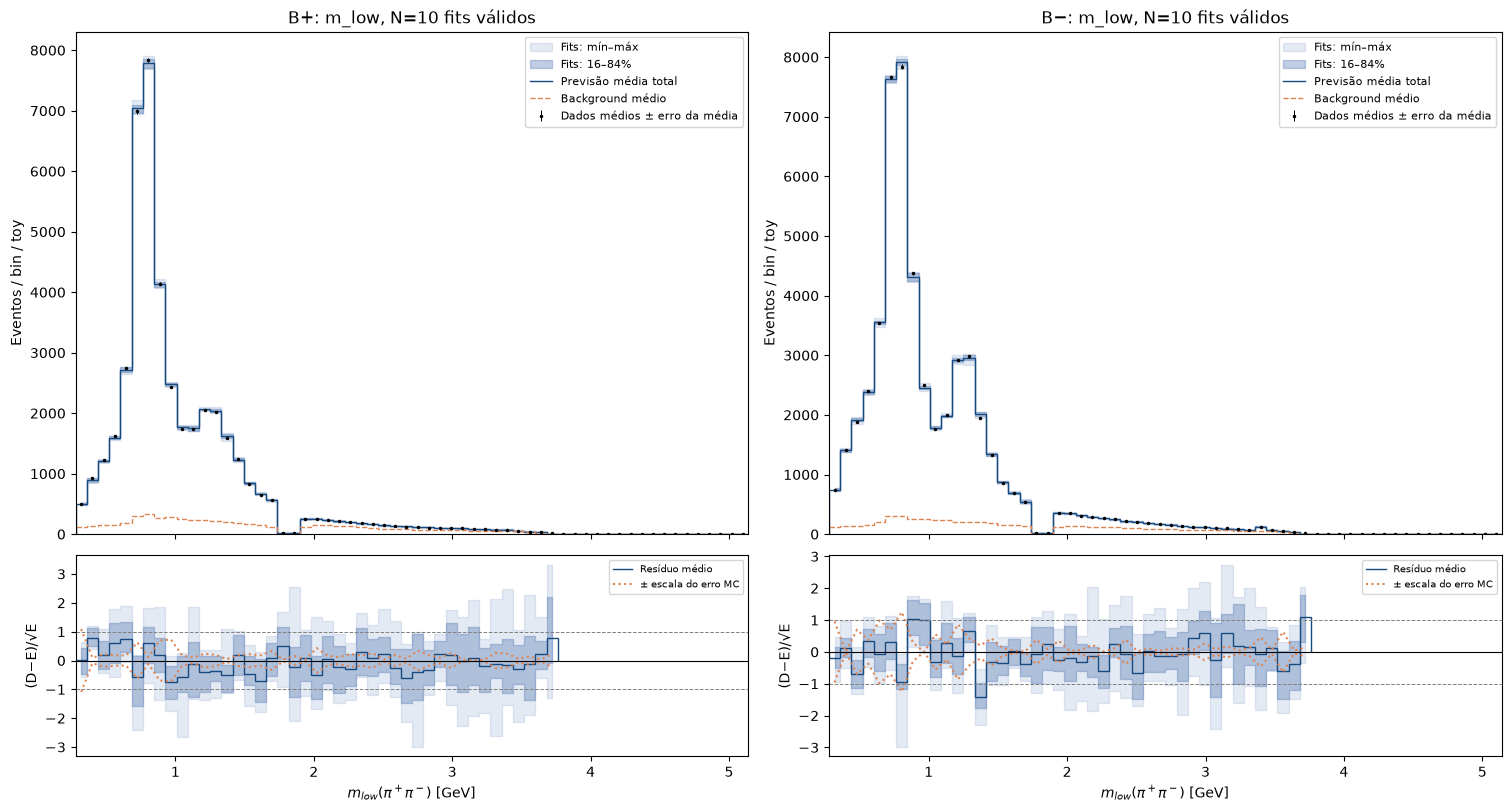

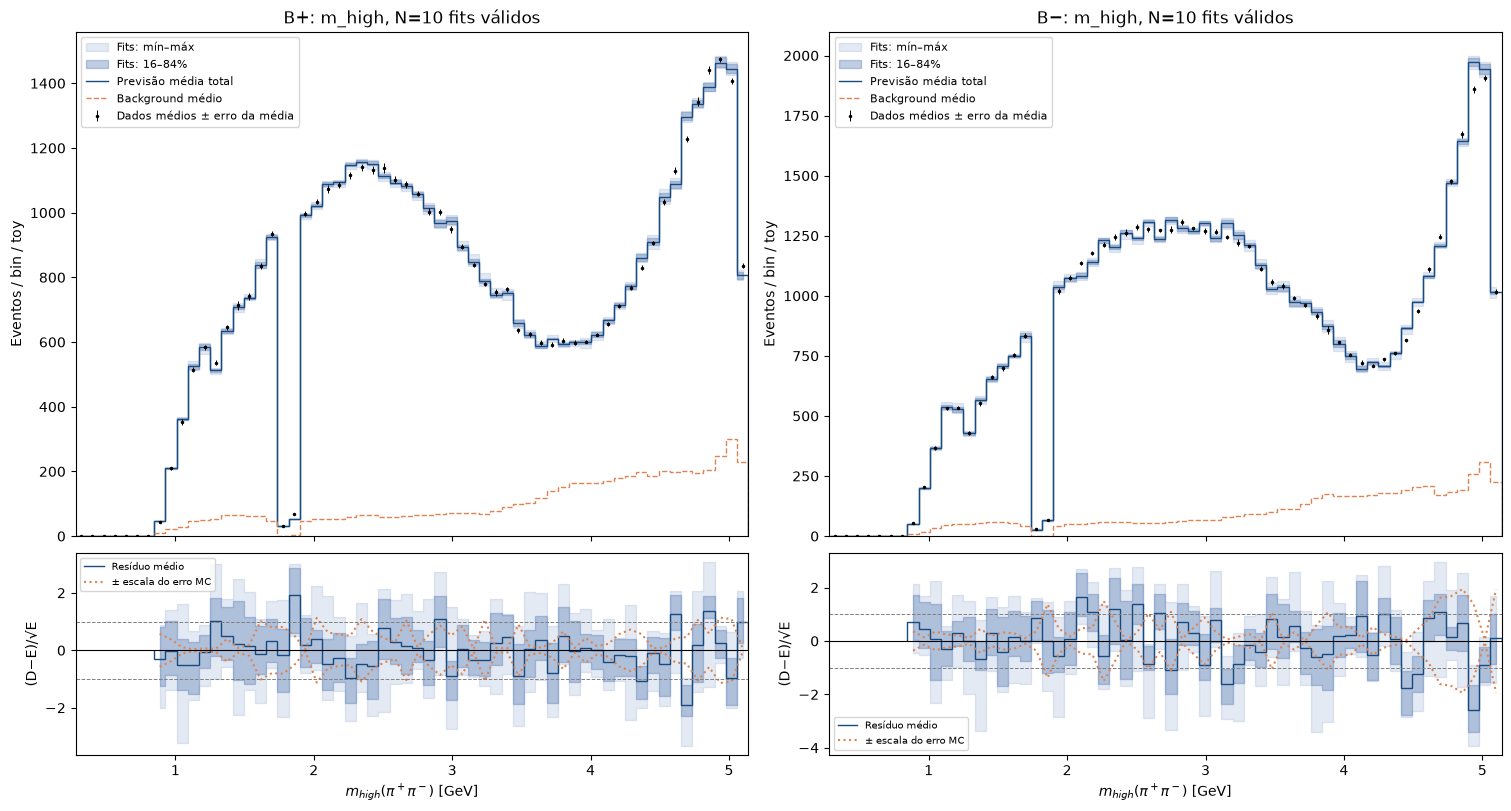

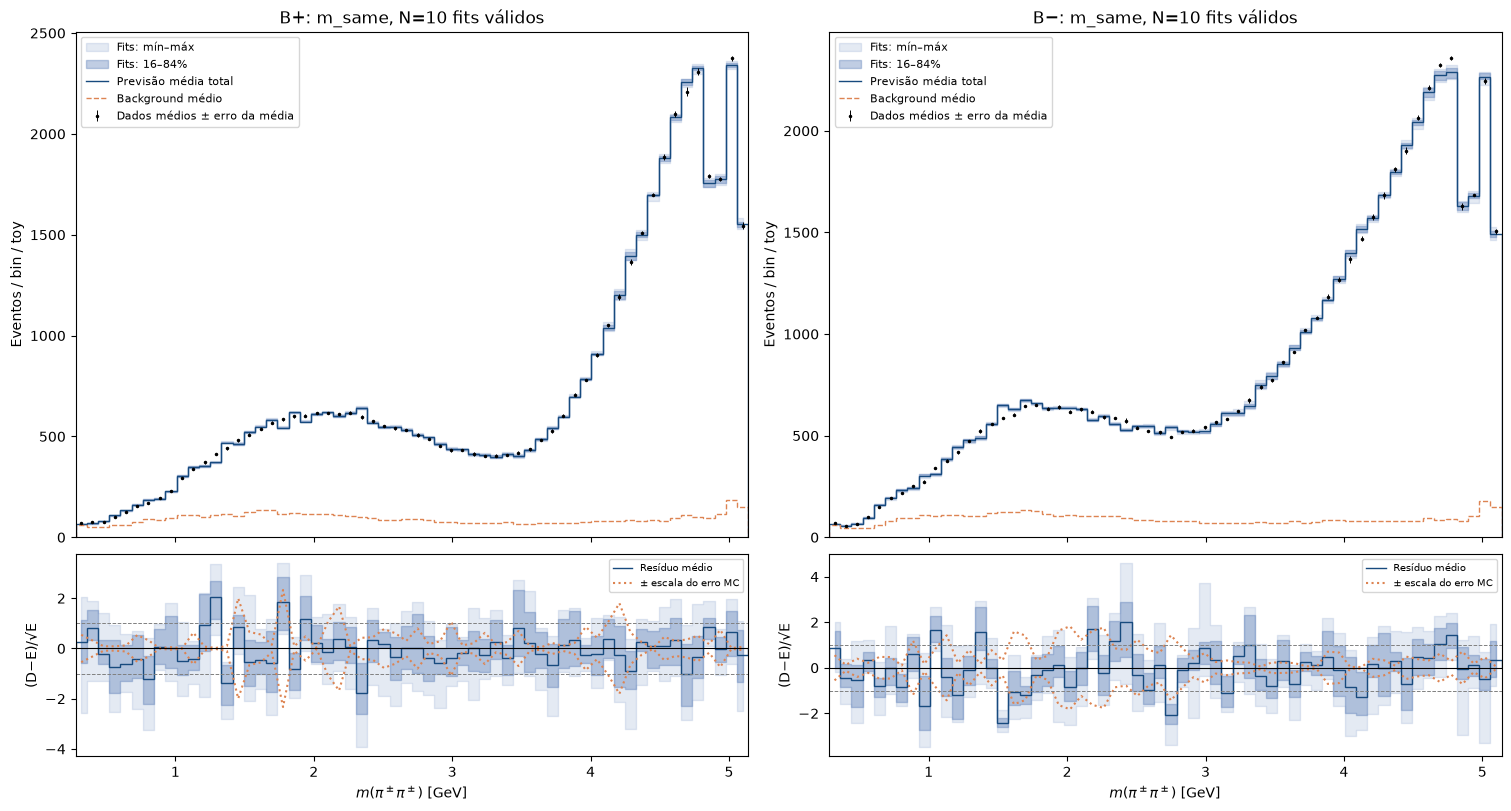

Bins com dados e previsão zero: 0 (não entram nos resíduos; investigar se > 0)


,iExpt,charge,projection,n_bins,residual_mean,residual_rms,max_abs_residual,bins_data_without_model,bins_expected_lt5,observed_total,expected_total
55,5,-1,m_same,60,-0.236992,1.375034,2.946833,0,0,51024.0,51419.735311
34,4,-1,m_high,53,-0.032636,1.374756,2.923779,0,0,51119.0,51307.818199
32,2,-1,m_high,53,0.079430,1.352015,3.920416,0,0,51130.0,51061.341573
54,4,-1,m_same,60,-0.154421,1.321456,3.742599,0,0,51119.0,51307.818199
57,7,-1,m_same,60,-0.010872,1.320860,3.393272,0,0,51339.0,51241.141334
36,6,-1,m_high,53,0.141490,1.307534,3.046122,0,0,51281.0,51169.591296
31,1,-1,m_high,53,0.112288,1.280459,3.551929,0,0,51387.0,51314.040930
38,8,-1,m_high,53,0.006744,1.278782,2.609651,0,0,51144.0,51196.895336
58,8,-1,m_same,60,-0.039653,1.273734,4.582485,0,0,51144.0,51196.895336
53,3,-1,m_same,60,-0.131679,1.251153,3.490476,0,0,51184.0,51399.662550


In [45]:
def projection_quantiles(array):
    # Evita avisos em bins sem previsão (fora do suporte ou totalmente vetados).
    result = np.full((5, array.shape[-1]), np.nan)
    finite = np.isfinite(array).any(axis=0)
    result[:, finite] = np.nanpercentile(array[:, finite], [0, 16, 50, 84, 100], axis=0)
    return result


def projection_mean(array):
    finite = np.isfinite(array)
    return np.divide(np.where(finite, array, 0).sum(axis=0), finite.sum(axis=0),
                      out=np.full(array.shape[1:], np.nan), where=finite.sum(axis=0) > 0)


def finish_projection_figure(fig, name):
    if SAVE_FIGURES:
        fig.savefig(PROJECTION_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


projection_summary_rows, projection_bin_rows = [], []
if projection_records:
    projection_toys = np.array([r["iExpt"] for r in projection_records])
    projection_observed = np.stack([r["observed"] for r in projection_records])
    # Axes: toy, réplica MC, projeção, carga, bin.
    projection_replicas = np.stack([r["expected_replicas"] for r in projection_records])
    projection_expected = projection_replicas.mean(axis=1)
    projection_background = np.stack([r["background_replicas"] for r in projection_records]).mean(axis=1)
    projection_residuals = np.divide(
        projection_observed - projection_expected, np.sqrt(projection_expected),
        out=np.full_like(projection_expected, np.nan), where=projection_expected > 0,
    )
    # A média entre toys é feita ANTES do erro entre réplicas: o MC é comum aos toys.
    projection_mean_mc_error = projection_replicas.mean(axis=0).std(axis=0, ddof=1) / np.sqrt(PROJECTION_MC_REPLICAS)
    projection_centers = (PROJECTION_EDGES[:-1] + PROJECTION_EDGES[1:]) / 2
    n_projection_toys = len(projection_toys)
    for p, (name, xlabel) in enumerate(zip(PROJECTION_NAMES, PROJECTION_LABELS)):
        fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex="col",
                                 gridspec_kw={"height_ratios": [2.5, 1]}, constrained_layout=True)
        for c, charge in enumerate((+1, -1)):
            observed = projection_observed[:, p, c]
            expected = projection_expected[:, p, c]
            residuals = projection_residuals[:, p, c]
            data_mean, fit_mean = observed.mean(axis=0), expected.mean(axis=0)
            data_error = (observed.std(axis=0, ddof=1) / np.sqrt(n_projection_toys)
                          if n_projection_toys > 1 else np.sqrt(data_mean))
            low, p16, _, p84, high = projection_quantiles(expected)
            ax, residual_ax = axes[:, c]
            ax.fill_between(projection_centers, low, high, step="mid", alpha=.15, color="#4C72B0", label="Fits: mín–máx")
            ax.fill_between(projection_centers, p16, p84, step="mid", alpha=.35, color="#4C72B0", label="Fits: 16–84%")
            ax.stairs(fit_mean, PROJECTION_EDGES, color="#174A7E", label="Previsão média total")
            ax.stairs(projection_background[:, p, c].mean(axis=0), PROJECTION_EDGES,
                       color="#DD8452", linestyle="--", label="Background médio")
            error_label = "Dados médios ± erro da média" if n_projection_toys > 1 else "Dados ± √D (N=1)"
            ax.errorbar(projection_centers, data_mean, yerr=data_error, fmt=".", color="black", ms=3, lw=.7, label=error_label)
            ax.set_ylabel("Eventos / bin / toy")
            ax.set_title(f"B{'+' if charge == 1 else '−'}: {name}, N={n_projection_toys} fits válidos")
            ax.legend(fontsize=8)
            rlow, r16, _, r84, rhigh = projection_quantiles(residuals)
            rmean = projection_mean(residuals)
            residual_ax.fill_between(projection_centers, rlow, rhigh, step="mid", color="#4C72B0", alpha=.15)
            residual_ax.fill_between(projection_centers, r16, r84, step="mid", color="#4C72B0", alpha=.35)
            residual_ax.stairs(rmean, PROJECTION_EDGES, color="#174A7E", label="Resíduo médio")
            mc_scale = np.divide(projection_mean_mc_error[p, c], np.sqrt(fit_mean),
                                  out=np.full_like(fit_mean, np.nan), where=fit_mean > 0)
            residual_ax.plot(projection_centers, mc_scale, ":", color="#DD8452", label="± escala do erro MC")
            residual_ax.plot(projection_centers, -mc_scale, ":", color="#DD8452")
            residual_ax.axhline(0, color="black", lw=.8)
            residual_ax.axhline(1, color="grey", linestyle="--", lw=.7)
            residual_ax.axhline(-1, color="grey", linestyle="--", lw=.7)
            residual_ax.set_ylabel("(D−E)/√E")
            residual_ax.set_xlabel(xlabel)
            residual_ax.legend(fontsize=7)
            residual_ax.set_xlim(PROJECTION_EDGES[0], PROJECTION_EDGES[-1])
            for b in range(PROJECTION_BINS):
                projection_bin_rows.append(dict(
                    projection=name, charge=charge, bin=b, mass=projection_centers[b], n_toys=n_projection_toys,
                    observed_mean=data_mean[b], observed_mean_error=data_error[b], expected_mean=fit_mean[b],
                    expected_min=low[b], expected_p16=p16[b], expected_p84=p84[b], expected_max=high[b],
                    expected_mean_mc_error=projection_mean_mc_error[p, c, b],
                    residual_mean=rmean[b], residual_min=rlow[b], residual_p16=r16[b], residual_p84=r84[b], residual_max=rhigh[b],
                ))
            for t, toy in enumerate(projection_toys):
                finite = np.isfinite(residuals[t])
                r = residuals[t, finite]
                missing_support = int(np.sum((expected[t] <= 0) & (observed[t] > 0)))
                projection_summary_rows.append(dict(
                    iExpt=int(toy), charge=charge, projection=name, n_bins=int(finite.sum()),
                    residual_mean=float(r.mean()) if len(r) else np.nan,
                    residual_rms=float(np.sqrt(np.mean(r**2))) if len(r) else np.nan,
                    max_abs_residual=float(np.max(abs(r))) if len(r) else np.nan,
                    bins_data_without_model=missing_support, bins_expected_lt5=int(np.sum((expected[t] > 0) & (expected[t] < 5))),
                    observed_total=float(observed[t].sum()), expected_total=float(expected[t].sum()),
                ))
        finish_projection_figure(fig, f"ensemble_{name}")
    projection_summary = pd.DataFrame(projection_summary_rows)
    projection_bins = pd.DataFrame(projection_bin_rows)
    projection_summary.to_csv(PROJECTION_DIR / "toy_quality.csv", index=False)
    projection_bins.to_csv(PROJECTION_DIR / "ensemble_bins.csv", index=False)
    missing_support = int(projection_summary.bins_data_without_model.sum())
    print(f"Bins com dados e previsão zero: {missing_support} (não entram nos resíduos; investigar se > 0)")
    display(projection_summary.sort_values("residual_rms", ascending=False).head(12))


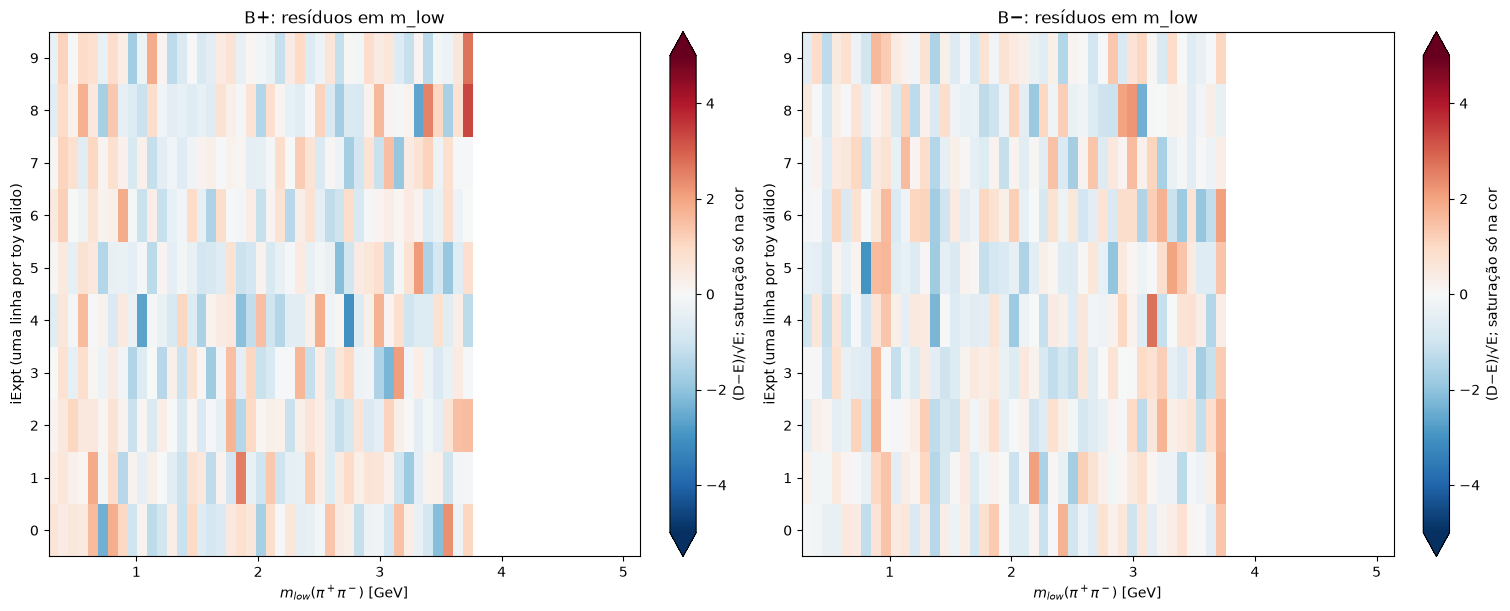

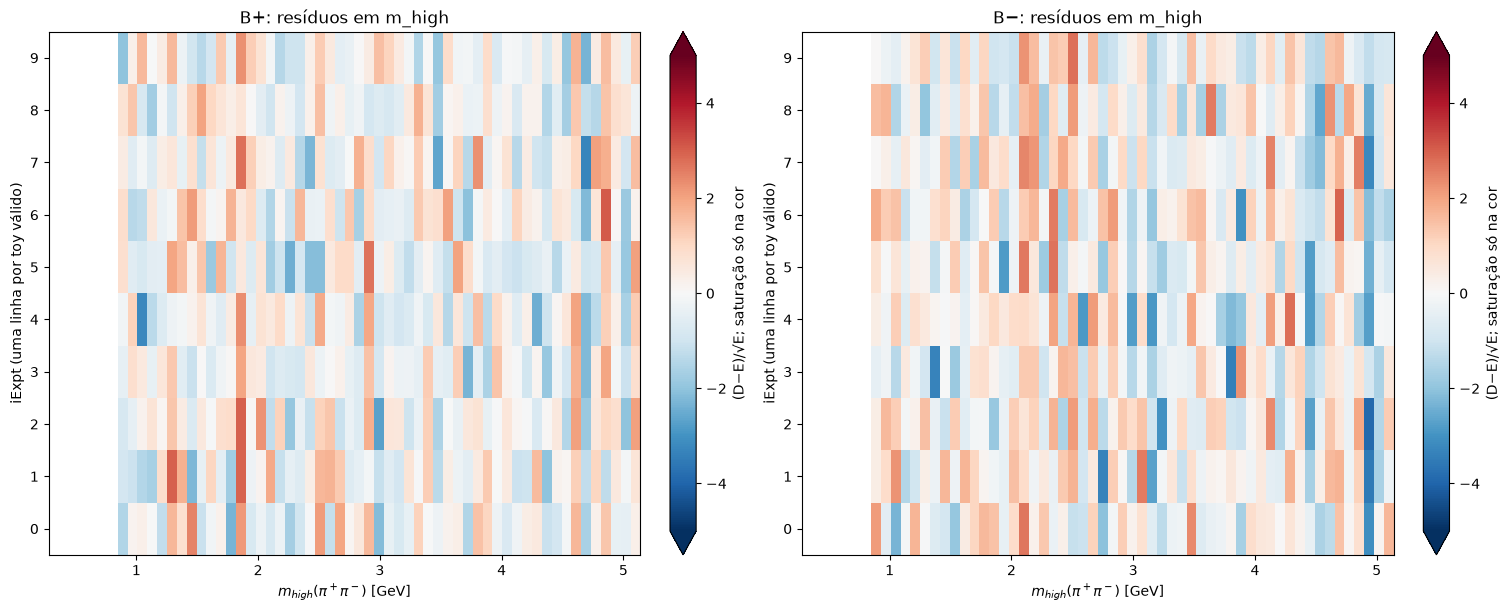

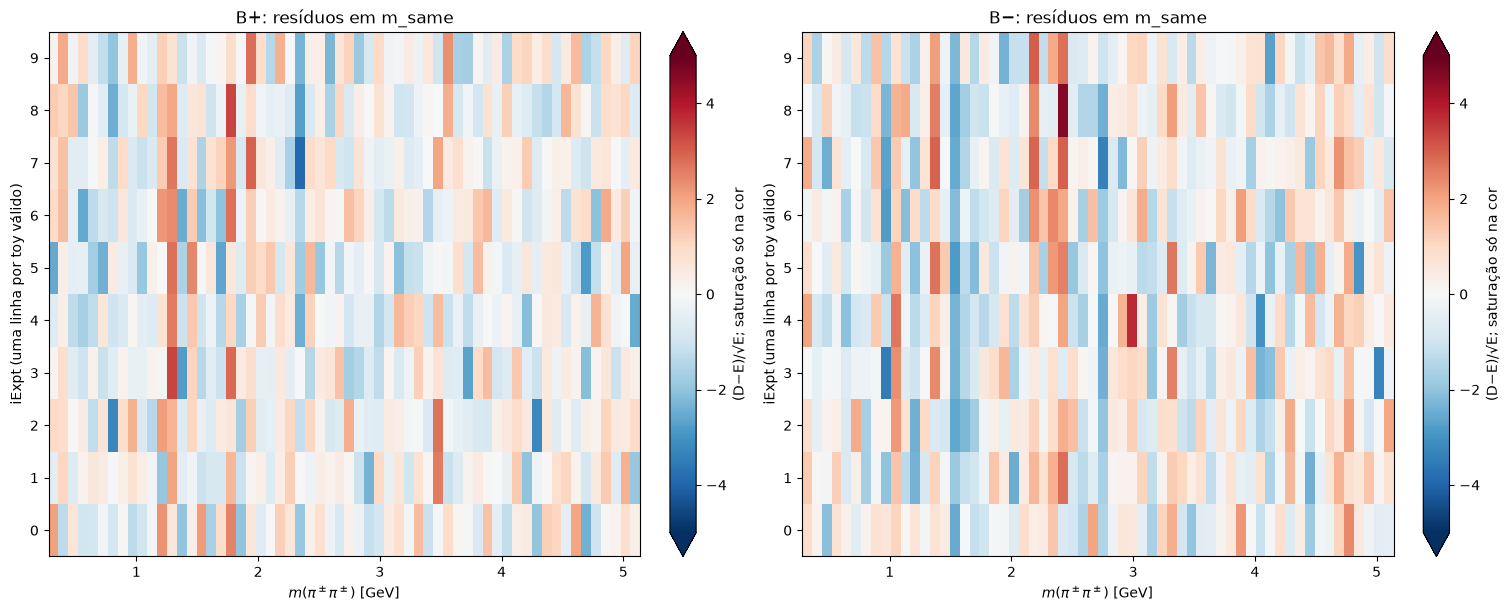

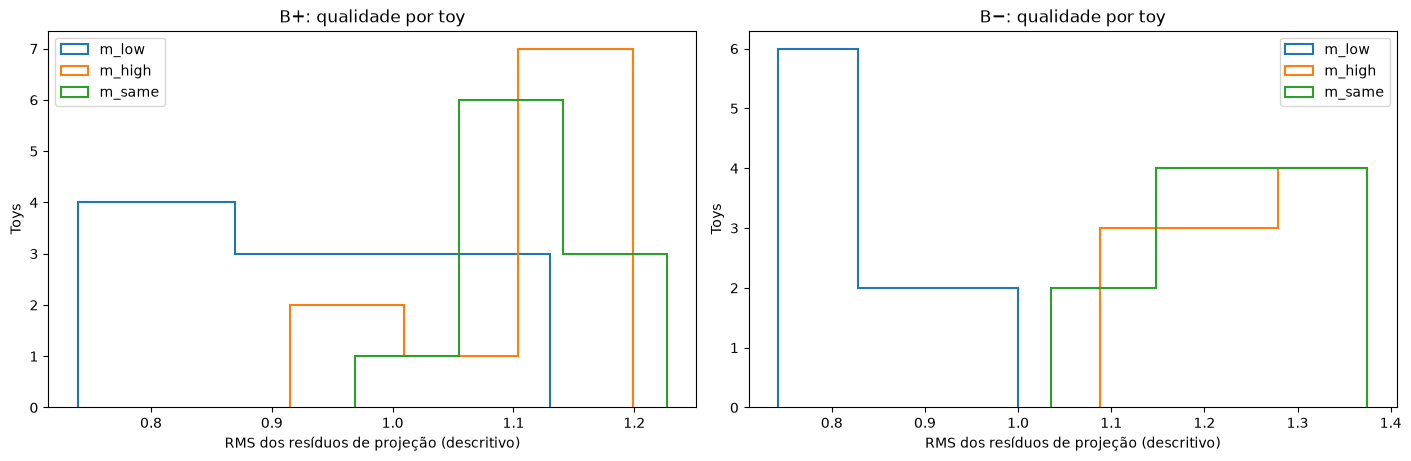

In [46]:
if projection_records:
    for p, (name, xlabel) in enumerate(zip(PROJECTION_NAMES, PROJECTION_LABELS)):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
        for c, (ax, charge) in enumerate(zip(axes, (+1, -1))):
            heatmap = ax.pcolormesh(PROJECTION_EDGES, np.arange(n_projection_toys + 1),
                                    np.ma.masked_invalid(projection_residuals[:, p, c]),
                                    cmap="RdBu_r", vmin=-PROJECTION_HEATMAP_LIMIT,
                                    vmax=PROJECTION_HEATMAP_LIMIT, shading="flat")
            indices = np.unique(np.linspace(0, n_projection_toys-1, min(12, n_projection_toys)).astype(int))
            ax.set_yticks(indices + .5, labels=projection_toys[indices])
            ax.set_ylabel("iExpt (uma linha por toy válido)")
            ax.set_xlabel(xlabel)
            ax.set_title(f"B{'+' if charge == 1 else '−'}: resíduos em {name}")
            fig.colorbar(heatmap, ax=ax, label="(D−E)/√E; saturação só na cor", extend="both")
        finish_projection_figure(fig, f"residual_map_{name}")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    for ax, charge in zip(axes, (+1, -1)):
        for name in PROJECTION_NAMES:
            selected = projection_summary[(projection_summary.charge == charge) & (projection_summary.projection == name)]
            data = selected.residual_rms.to_numpy(float)
            data = data[np.isfinite(data)]
            if len(data):
                ax.hist(data, bins=max(1, min(30, int(np.sqrt(len(data))))), histtype="step", lw=1.5, label=name)
        ax.set_title(f"B{'+' if charge == 1 else '−'}: qualidade por toy")
        ax.set_xlabel("RMS dos resíduos de projeção (descritivo)")
        ax.set_ylabel("Toys")
        ax.legend()
    finish_projection_figure(fig, "quality_distribution")


As figuras e tabelas desta seção ficam em `OUTPUT_DIR/projections/<identificador>/`.
O identificador depende do estudo e da configuração das projeções; a troca de bins, sementes ou tamanho MC
não mistura caches incompatíveis. A retomada reutiliza as projeções salvas e calcula apenas novos toys ou refits.
`ensemble_bins.csv` guarda as médias e faixas por bin; `toy_quality.csv` permite localizar os piores toys
para inspeção individual. Nenhum arquivo de resultado de fit é alterado por esta seção.

Validação desta seção: as contagens observadas e esperadas das três massas e ambas as cargas foram comparadas com `CPFitSession.goodness_of_fit_projection`, usando o fit salvo de iExpt=0 e bins equivalentes em massa². Também foram verificados N=1, ensemble sintético N=3, ausência de resultados, retomada do cache e preservação dos arquivos de fit. O teste usou 10.000 pontos MC por carga/réplica; a configuração padrão acima usa 250.000. Os arquivos de diagnóstico de teste ficaram fora do diretório do estudo.


## Uso e limites do estudo

- `fit_results.csv`: estado, EDM, qualidade de covariância, valores e erros dos parâmetros; `toy_XXXX.npz`: valores e covariância completa na ordem dos nomes salvos.
- `node_results.csv`, `node_ranges.csv`, `node_pull_summary.csv` e `isobar_summary.csv`: diagnósticos da seleção atual de toys. As figuras ficam em `figures/`.
- `study_config.json` registra a convenção, entradas e configurações para uma retomada coerente. Mudanças físicas/numericas exigem outro diretório; ampliar `TOY_INDICES` não muda o estudo.
- Fits inválidos ficam registrados no CSV e não são repetidos automaticamente. Para investigar/repetir um toy, use outro `OUTPUT_DIR` e selecione seu índice.
- A estatística de bandas é o espalhamento dos ajustes válidos, não uma incerteza de interpolação nem uma banda de HESSE. O notebook exibe quantos ajustes entram em cada diagnóstico.
- Este notebook mantém o truth implementado no original. A identificação desse truth com o gerador Laura++ depende das mesmas convenções e constantes daquele estudo; o teste de representação QMI não valida sozinho diferenças entre os dois programas.

Validação de implementação (20/09/2026): formato nbformat, compilação de todas as células e imports;
construção dos modelos na malha nominal 500×500; consistência da simetrização com a soma dos dois pares;
likelihood/gradientes em 120 eventos reais por carga com malha reduzida 30×30;
teste de preservação da escala QMI e atualização da normalização total;
propagação de covariância correlacionada, diferença circular de fase e todos os gráficos com
três resultados sintéticos de diagnóstico, mantidos fora do diretório de produção.
Na malha nominal, o RMS complexo de representação da QMI inicial foi 0,927% (B+) e 0,874% (B−).
Os 500 ajustes de produção **não foram executados** nesta validação; convergência e closure estatístico
precisam ser avaliados ao executar o estudo. Nenhum resultado sintético foi salvo neste notebook.

Esta variante acrescenta a opção de regularização aos testes do notebook base.
As validações históricas acima se referem ao fit sem penalização; não estabelecem
convergência ou cobertura para λ positivo. A força deve ser calibrada com toys independentes.
